# NVM Process Lévy-Measure Inference (§5.1)

Reproduces the **NVM process inference** experiments of Lin & Godsill (2025), *Bayesian Non-Parametric Inference for Lévy Measures in State-Space Models* ([arXiv:2505.22587](https://arxiv.org/abs/2505.22587)).

Here the NVM process is observed **directly** — the special case of the linear state-space model with a scalar state and `A = 0`, `h = 1`, `H = 1`, and no system noise. Using the Independent Gamma-Scaled Dirichlet Process (IGSDP) prior, we infer the subordinator and NVM Lévy measures jointly with the NVM parameters, and compare against frequentist projection estimators.

**Experiments in this notebook**
1. Tempered-stable-driven NVM (noise-free)
2. Tempered-stable-driven NVM with Gaussian observation noise
3. Bimodal subordinator-driven NVM

**Data / outputs.** Loads the simulated datasets `TS_driven_NVM.npz` and `bimodal_driven_NVM.npz`. The MCMC posterior samples are written to large `*.npz` archives (git-ignored) and reloaded for plotting; regenerate them by running the sampling cells. The runs are heavy — reduce `burn_in` / iteration counts for a quick pass.

## Tempered Stable Process Driven NVM Process Experiment

### Sampling and Inference of Our Approach

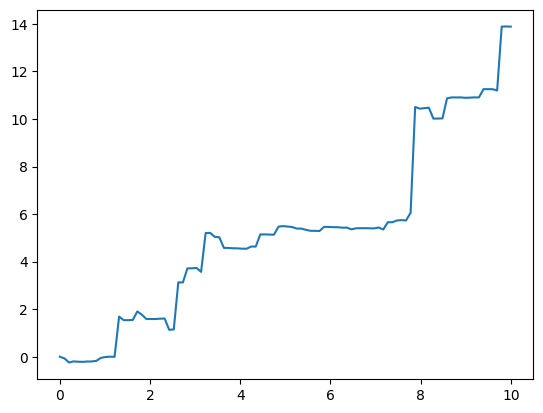

In [1]:
#Load the observations
# Load the saved data, including the initial jump sizes and times here
#The initialization is through random generation of a set of subordinator series
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
data = np.load("TS_driven_NVM.npz")
sim_rate = data["sim_rate"]
observation_noise_level = data["observation_noise_level"]
T = data["T"]
time_axis = data["time_axis"]
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
sigmaw = data["sigmaw"]
kv = data["kv"]
sub_jump_sizes = data["sub_jump_sizes"]
jump_times = data["jump_times"]
original_path = data["original_path"]
nvm_jump_sizes = data["nvm_jump_sizes"]



sigmaw2 = sigmaw ** 2
sigmav2 = kv * sigmaw ** 2

nvm_process_path = integrate_to_path(nvm_jump_sizes,jump_times,time_axis)


observation_noise_level = 1e-5
sigmav2 = observation_noise_level**2
observations = langevin_observations(nvm_process_path,(observation_noise_level**2)*np.identity(1),H=np.ones((1,1)),mu=np.zeros((1,1)))
plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()


In [ ]:
#Extended MCMC Algorithm with Hyper-parameter Sampling
#Inference Parameters
burn_in = 50000
num_iter = 150000  
block_width = 1
overlapping_width = 0
#Make a guess for sigmaw2
sigmaw2 = 1.0

#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition. Note that the Gamma base to DP here follows the shape-scale convention
initial_dir_alpha = 2
initial_base_gamma_a = 1
initial_base_gamma_b=2 #scale, not rate

#Shape-scale convention here.
dir_alpha_a = 1
dir_alpha_b = 3

base_gamma_a_mean = initial_base_gamma_a
base_gamma_a_std = 1000.0
base_gamma_b_mean = initial_base_gamma_b
base_gamma_b_std = 1000.0
base_gamma_a_step_size = 0.0
base_gamma_b_step_size = 0.0

#Define the muw prior
prior_muw_mean = 0.0
prior_muw_variance = 10.0
#Generate Initilisation of the jump sizes
wrong_beta = 1*beta
wrong_alpha = alpha
wrong_C = 1*C

initial_jump_sizes,initial_jump_times = tempered_stable_process_jumps((wrong_beta,wrong_alpha,wrong_C),T,sim_rate)
grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
sample_measures,sample_rates,sample_paths,sample_x_means,sample_x_covariances,dir_alphas,base_gamma_as,base_gamma_bs = nvm_lm_theta_inference_all_DP_alpha_inferred_Gamma_base_Gaussian_update_conditional_sigmaw2(num_iter,block_width,overlapping_width,observations,time_axis,initial_jump_sizes,initial_jump_times,sigmav2,rate_alpha_prior,rate_beta_prior,dir_K,dir_alpha_a,dir_alpha_b,base_gamma_a_mean,base_gamma_a_std,base_gamma_b_mean,base_gamma_b_std,sigmaw2,base_gamma_a_step_size,base_gamma_b_step_size,dir_alpha=initial_dir_alpha,base_gamma_a=initial_base_gamma_a,base_gamma_b=initial_base_gamma_b,muw_prior_mean=prior_muw_mean,muw_prior_variance=prior_muw_variance)
#Discard the burn-in
sample_measures = sample_measures[burn_in:]
sample_rates = sample_rates[burn_in:]
sample_paths = sample_paths[burn_in:]
sample_x_means = sample_x_means[burn_in:]
sample_x_covariances = sample_x_covariances[burn_in:]


np.savez(
    "nvm_direct_observations_sigmaw2_conditional.npz",
    sample_measures=sample_measures,
    sample_rates=sample_rates,
    sample_paths=sample_paths,
    sample_x_means=sample_x_means,
    sample_x_covariances=sample_x_covariances,
    dir_alphas = dir_alphas
    
)


Langevin System Inference Progress::   0%|          | 48/150000 [00:10<9:08:29,  4.56it/s]

Making Prior Visualization: 100%|██████████| 1000/1000 [00:02<00:00, 369.18it/s]


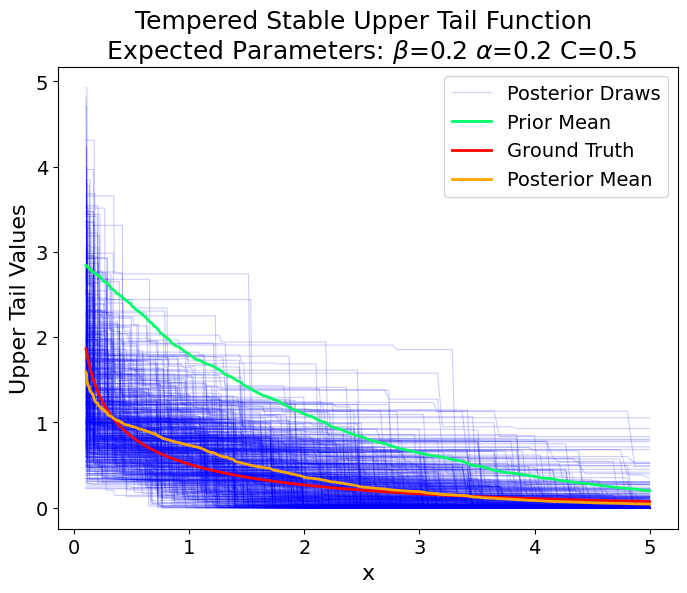

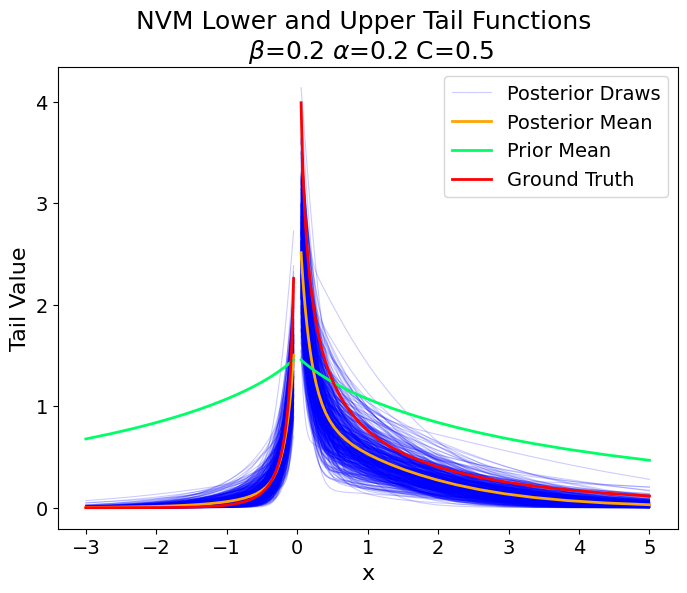

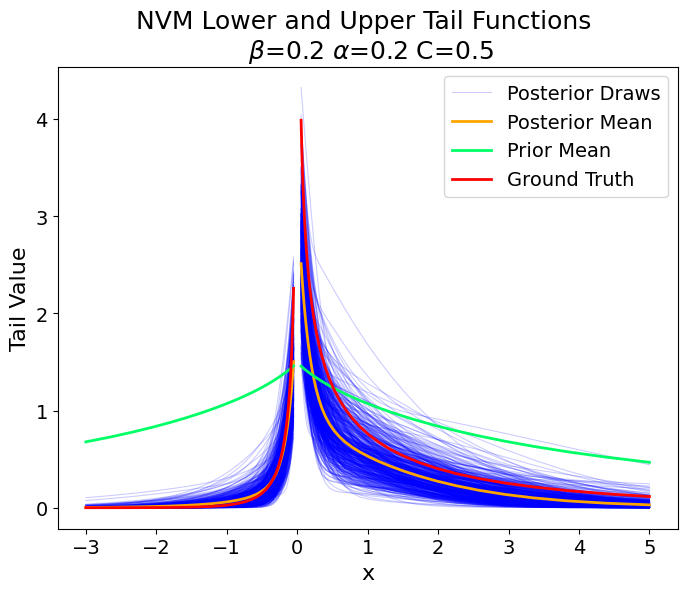

0.7497055207246428
(100001,)
(100001,)


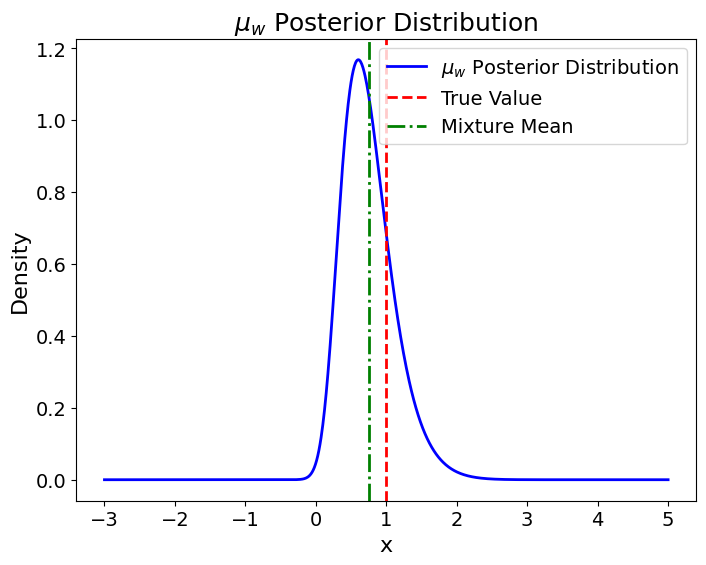

In [1]:
## Showing instead the realizations than the confidence intervals





factor = 1
# Comparison with the Priors
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *



num_samples_in_plot = 500
plt.rcParams.update({
    "figure.figsize": (14, 6),  # overall figure size
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
#Load the observation dataset to just get the sigmaw2 value
data = np.load("TS_driven_NVM.npz")
sigmaw = data["sigmaw"]
sigmaw2 = sigmaw ** 2
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
T = data["T"]
sim_rate = data["sim_rate"]


#Quantile selection for the visualization
lower_percentage = 0.15
upper_percentage = 99.85

additional_burn_in = 0


#Load the experimental results stored for the samples
data = np.load("nvm_direct_observations_sigmaw2_conditional.npz")
sample_measures = data["sample_measures"][additional_burn_in:]
sample_rates = data["sample_rates"][additional_burn_in:]
sample_x_means = data["sample_x_means"][additional_burn_in:]
sample_x_covariances = data["sample_x_covariances"][additional_burn_in:]


#Define the prior
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition
initial_dir_alpha = 10.0
initial_base_gamma_a = 1
initial_base_gamma_b= 2

dir_alpha_a = 1.0
dir_alpha_b = 3
#Normal(0,1) has been used for all the muw priors
muw_mean = 0
muw_variance = 10
#Subordinator Prior Measures for Visualization
prior_sample_measures,prior_sample_rates = draw_IGSDP_Prior_Measures(rate_alpha_prior,rate_beta_prior,initial_base_gamma_a,1/initial_base_gamma_b,dir_alpha_a,1/dir_alpha_b,dir_K,num_samples=1000)




#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
real_posterior_NVM_conditional_lower_tails = []
real_posterior_NVM_conditional_upper_tails = []

overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 1e-5 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.logspace(np.log10(epsilon),np.log10(5),1000) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.logspace(np.log10(epsilon),np.log10(5),100)
nvm_negative_axis =np.logspace(np.log10(epsilon),np.log10(3),100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#The mean estimates
    real_posterior_lower_tail_conditional,real_posterior_upper_tail_conditional,real_posterior_muw_sample = NVM_measure_tail_functions_sampled_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#Inference for the entire posterior distribution but not just the mean
    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    real_posterior_NVM_conditional_lower_tails.append(real_posterior_lower_tail_conditional)
    real_posterior_NVM_conditional_upper_tails.append(real_posterior_upper_tail_conditional)



prior_sample_upper_tail_measures = []
prior_overall_rates_list = []
prior_overall_positions_list = []
prior_NVM_conditional_lower_tails = []
prior_NVM_conditional_upper_tails = []
for i in tqdm(range(len(prior_sample_measures)),desc="Making Prior Visualization"):
    prior_sample_rate = prior_sample_rates[i]
    prior_sample_measure = prior_sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    prior_sample_measure[0, :] = prior_sample_measure[0, :] * prior_sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    prior_sample_measures[i] = prior_sample_measure
    #Then extract the information from the L\'evy density
    prior_rates = prior_sample_measure[0, :]
    prior_positions = prior_sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    prior_sample_upper_tail_measure = DP_upper_tail_projection(prior_positions,prior_rates,x_axis)
    prior_sample_upper_tail_measures.append(prior_sample_upper_tail_measure)
    # Collect arrays in lists
    prior_overall_rates_list.append(prior_rates)
    prior_overall_positions_list.append(prior_positions)
    
    prior_lower_tail_conditional,prior_upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(prior_rates, prior_positions, nvm_axis, muw_mean, muw_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    prior_NVM_conditional_lower_tails.append(prior_lower_tail_conditional)
    prior_NVM_conditional_upper_tails.append(prior_upper_tail_conditional)

#Subordinator Procesing
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/(len(sample_measures))

prior_rates = np.concatenate(prior_overall_rates_list)
prior_positions = np.concatenate(prior_overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
prior_mean_weights = prior_rates/(len(prior_sample_measures))

posterior_mean_upper_tail_values = DP_upper_tail_projection(positions,mean_weights,x_axis)
prior_mean_upper_tail_values = DP_upper_tail_projection(prior_positions,prior_mean_weights,x_axis)
ground_truth_upper_tail_values = upper_tail_ts_measure(alpha, beta*factor, C/(factor**alpha),x_axis)
# Stack the samples into a 2D array for easier quantile computation
ts_sample_array = np.vstack(sample_upper_tail_measures)

# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
ts_lower_quantile = np.percentile(ts_sample_array, lower_percentage, axis=0)
ts_upper_quantile = np.percentile(ts_sample_array, upper_percentage, axis=0)
prior_ts_sample_array = np.vstack(prior_sample_upper_tail_measures)
# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
prior_ts_lower_quantile = np.percentile(prior_ts_sample_array, lower_percentage, axis=0)
prior_ts_upper_quantile = np.percentile(prior_ts_sample_array, upper_percentage, axis=0)




#NVM Processing
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
real_posterior_NVM_upper_tail_array = np.vstack(real_posterior_NVM_conditional_upper_tails)
real_posterior_NVM_lower_tail_array = np.vstack(real_posterior_NVM_conditional_lower_tails)
prior_NVM_upper_tail_array = np.vstack(prior_NVM_conditional_upper_tails)
prior_NVM_lower_tail_array = np.vstack(prior_NVM_conditional_lower_tails)

    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

real_posterior_nvm_upper_tail_lower_quantile = np.percentile(real_posterior_NVM_upper_tail_array, lower_percentage, axis=0)
real_posterior_nvm_upper_tail_upper_quantile = np.percentile(real_posterior_NVM_upper_tail_array, upper_percentage, axis=0)
real_posterior_nvm_lower_tail_lower_quantile = np.percentile(real_posterior_NVM_lower_tail_array, lower_percentage, axis=0)
real_posterior_nvm_lower_tail_upper_quantile = np.percentile(real_posterior_NVM_lower_tail_array, upper_percentage, axis=0)


prior_nvm_upper_tail_lower_quantile = np.percentile(prior_NVM_upper_tail_array, lower_percentage, axis=0)
prior_nvm_upper_tail_upper_quantile = np.percentile(prior_NVM_upper_tail_array, upper_percentage, axis=0)
prior_nvm_lower_tail_lower_quantile = np.percentile(prior_NVM_lower_tail_array, lower_percentage, axis=0)
prior_nvm_lower_tail_upper_quantile = np.percentile(prior_NVM_lower_tail_array, upper_percentage, axis=0)


NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)
real_posterior_NVM_upper_tail_inferred = np.mean(real_posterior_NVM_upper_tail_array,axis=0)
real_posterior_NVM_lower_tail_inferred = np.mean(real_posterior_NVM_lower_tail_array,axis=0)
prior_NVM_upper_tail_inferred = np.mean(prior_NVM_upper_tail_array,axis=0)
prior_NVM_lower_tail_inferred = np.mean(prior_NVM_lower_tail_array,axis=0)


#NVM ground truth tails generation
gt_sub_jump_sizes,gt_jump_times = tempered_stable_process_jumps((beta*factor,alpha,C/(factor**alpha)),T*5000,sim_rate)#Generate a bunch of jump sizes and times for computing the ground truth
NVM_lower_tail_ground_truth,NVM_upper_tail_ground_truth = NVM_ground_truth_tail_functions(nvm_axis,gt_sub_jump_sizes[0,:],muw*factor,sigmaw*np.sqrt(factor),alpha,beta*factor,C/(factor**alpha),epsilon*1e-2/factor)#The truncated threshold for the approximation needs also be adjusted for jump size scaling.
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]



original_x_axis = x_axis
original_ground_truth_upper_tail_values = ground_truth_upper_tail_values
original_posterior_mean_upper_tail_values = posterior_mean_upper_tail_values
original_ts_lower_quantile = ts_lower_quantile
original_ts_upper_quantile = ts_upper_quantile


#Generating the thinned sample measures for visualization

thinned_prior_ts_array = thin_uniform(prior_ts_sample_array,num_samples_in_plot)
thinned_posterior_ts_array = thin_uniform(ts_sample_array,num_samples_in_plot)
thinned_prior_nvm_upper_tail_array = thin_uniform(prior_NVM_upper_tail_array,num_samples_in_plot)
thinned_posterior_nvm_upper_tail_array = thin_uniform(NVM_upper_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_upper_tail_array = thin_uniform(real_posterior_NVM_upper_tail_array,num_samples_in_plot)
thinned_prior_nvm_lower_tail_array = thin_uniform(prior_NVM_lower_tail_array,num_samples_in_plot)
thinned_posterior_nvm_lower_tail_array = thin_uniform(NVM_lower_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_lower_tail_array = thin_uniform(real_posterior_NVM_lower_tail_array,num_samples_in_plot)





#Plotting Sessions
#Plotting the subordinator upper tail functions
#Compute the upper tail measure for the DP posterior mean measure and also the ground truth
#Compute the quantiles given the x_axis

truncation_threshold = 0.1
mask = x_axis >= truncation_threshold
x_axis = original_x_axis[mask]
ground_truth_upper_tail_values = original_ground_truth_upper_tail_values[mask]
posterior_mean_upper_tail_values = original_posterior_mean_upper_tail_values[mask]
prior_mean_upper_tail_values = prior_mean_upper_tail_values[mask]
ts_lower_quantile = original_ts_lower_quantile[mask]
ts_upper_quantile = original_ts_upper_quantile[mask]
prior_ts_lower_quantile = prior_ts_lower_quantile[mask]
prior_ts_upper_quantile = prior_ts_upper_quantile[mask]

thinned_prior_ts_array = thinned_prior_ts_array[:,mask]
thinned_posterior_ts_array = thinned_posterior_ts_array[:,mask]


original_negative_axis = negative_axis
original_nvm_lower_tail_lower_quantile = nvm_lower_tail_lower_quantile
original_nvm_lower_tail_upper_quantile = nvm_lower_tail_upper_quantile
original_NVM_lower_tail_inferred = NVM_lower_tail_inferred
original_NVM_lower_tail_ground_truth = NVM_lower_tail_ground_truth

original_positive_axis = positive_axis
original_nvm_upper_tail_lower_quantile = nvm_upper_tail_lower_quantile
original_nvm_upper_tail_upper_quantile = nvm_upper_tail_upper_quantile
original_NVM_upper_tail_inferred = NVM_upper_tail_inferred
original_NVM_upper_tail_ground_truth = NVM_upper_tail_ground_truth

original_real_posterior_nvm_lower_tail_lower_quantile = real_posterior_nvm_lower_tail_lower_quantile
original_real_posterior_nvm_lower_tail_upper_quantile = real_posterior_nvm_lower_tail_upper_quantile
original_real_posterior_NVM_lower_tail_inferred = real_posterior_NVM_lower_tail_inferred

original_real_posterior_nvm_upper_tail_lower_quantile = real_posterior_nvm_upper_tail_lower_quantile
original_real_posterior_nvm_upper_tail_upper_quantile = real_posterior_nvm_upper_tail_upper_quantile
original_real_posterior_NVM_upper_tail_inferred = real_posterior_NVM_upper_tail_inferred


#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
truncation_threshold = 0.05
negative_axis = nvm_axis[nvm_axis < -0]
positive_axis = nvm_axis[nvm_axis > 0]
negative_axis_mask = negative_axis<-truncation_threshold
positive_axis_mask = positive_axis>truncation_threshold

negative_axis = original_negative_axis[negative_axis_mask]
nvm_lower_tail_lower_quantile = original_nvm_lower_tail_lower_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_lower_quantile = original_real_posterior_nvm_lower_tail_lower_quantile[negative_axis_mask]
prior_nvm_lower_tail_lower_quantile = prior_nvm_lower_tail_lower_quantile[negative_axis_mask]
nvm_lower_tail_upper_quantile = original_nvm_lower_tail_upper_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_upper_quantile = original_real_posterior_nvm_lower_tail_upper_quantile[negative_axis_mask]
prior_nvm_lower_tail_upper_quantile = prior_nvm_lower_tail_upper_quantile[negative_axis_mask]
NVM_lower_tail_inferred =  original_NVM_lower_tail_inferred[negative_axis_mask]
real_posterior_NVM_lower_tail_inferred = original_real_posterior_NVM_lower_tail_inferred[negative_axis_mask]
prior_NVM_lower_tail_inferred = prior_NVM_lower_tail_inferred[negative_axis_mask]
NVM_lower_tail_ground_truth = original_NVM_lower_tail_ground_truth[negative_axis_mask]


positive_axis = original_positive_axis[positive_axis_mask]
nvm_upper_tail_lower_quantile = original_nvm_upper_tail_lower_quantile[positive_axis_mask]
nvm_upper_tail_upper_quantile = original_nvm_upper_tail_upper_quantile[positive_axis_mask]
NVM_upper_tail_inferred = original_NVM_upper_tail_inferred[positive_axis_mask]
real_posterior_nvm_upper_tail_lower_quantile = original_real_posterior_nvm_upper_tail_lower_quantile[positive_axis_mask]
real_posterior_nvm_upper_tail_upper_quantile = original_real_posterior_nvm_upper_tail_upper_quantile[positive_axis_mask]
real_posterior_NVM_upper_tail_inferred = original_real_posterior_NVM_upper_tail_inferred[positive_axis_mask]
prior_nvm_upper_tail_lower_quantile = prior_nvm_upper_tail_lower_quantile[positive_axis_mask]
prior_nvm_upper_tail_upper_quantile = prior_nvm_upper_tail_upper_quantile[positive_axis_mask]
prior_NVM_upper_tail_inferred = prior_NVM_upper_tail_inferred[positive_axis_mask]
NVM_upper_tail_ground_truth = original_NVM_upper_tail_ground_truth[positive_axis_mask]


thinned_prior_nvm_upper_tail_array = thinned_prior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_posterior_nvm_upper_tail_array = thinned_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_real_posterior_nvm_upper_tail_array = thinned_real_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_prior_nvm_lower_tail_array = thinned_prior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_posterior_nvm_lower_tail_array = thinned_posterior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_real_posterior_nvm_lower_tail_array = thinned_real_posterior_nvm_lower_tail_array[:,negative_axis_mask]











#Visualization Session
#Subordinator PLot
plt.figure(figsize=(8, 6))
# Plot the posterior samples
for i in range(num_samples_in_plot):
    if i == 0:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws")
    else:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8)
# Plot the prior mean
plt.plot(x_axis, prior_mean_upper_tail_values, label="Prior Mean", color="#00FF66", linewidth=2)


# Plot the ground truth
plt.plot(x_axis, ground_truth_upper_tail_values, label="Ground Truth", color="red", linewidth=2)

# Plot the posterior mean
plt.plot(x_axis, posterior_mean_upper_tail_values, label="Posterior Mean", color="orange", linewidth=2)


# #plot the prior samples
# for i in range(num_samples_in_plot):
#     plt.plot(x_axis, thinned_prior_ts_array[i], color="green", alpha=0.2, linewidth=0.8)

# Add labels, legend, and title
plt.xlabel("x")
plt.ylabel("Upper Tail Values")
plt.title(f"Tempered Stable Upper Tail Function \n Expected Parameters: $\\beta$={np.round(beta*factor,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C/(factor**alpha),2)}")
# plt.xscale("log")
# plt.yscale("log")
plt.legend()
plt.show()


#NVM Posterior Mean Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#NVM Real Posterior Inference Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    real_posterior_NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_real_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    real_posterior_NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#Plotting muw again with the adjusted ground truth

sample_muw_means = sample_x_means[:,-1,-1,-1]
sample_muw_covariances = sample_x_covariances[:,-1,-1,-1]
print(np.mean(sample_muw_means))
print(np.shape(sample_muw_means))
print(np.shape(sample_muw_covariances))


# Define the range for plotting
x = np.linspace(-3, 5, 1000)
weights = np.ones(len(sample_muw_covariances)) / len(sample_muw_covariances)
plot_mixture_of_gaussians(sample_muw_means,sample_muw_covariances,weights,x,muw,f"$\\mu_w$ Posterior Distribution",show_mixture_mean=True)





### Comparison

========== True parameters ==========
beta: 0.2
alpha: 0.2
C: 0.5
muw: 1.0
sigmaw: 1.0
sigmaw2: 1.0
T: 10.0
sim_rate: 50.0

========== Posterior sample diagnostics ==========
Number of posterior samples: 100001
sample_measures shape: (100001, 2, 1000)
sample_rates shape: (100001, 1)
sample_x_means shape: (100001, 100, 2, 1)
sample_x_covariances shape: (100001, 100, 2, 2)

========== Prior sample diagnostics ==========
Number of prior samples: 1000


Posterior density analysis: 100%|██████████| 100001/100001 [11:22<00:00, 146.44it/s]



========== Posterior density diagnostics ==========
NVM_density_array shape: (100001, 600)
nvm_density_lower_quantile shape: (600,)
nvm_density_upper_quantile shape: (600,)


Prior density analysis: 100%|██████████| 1000/1000 [00:06<00:00, 158.32it/s]



========== Prior density diagnostics ==========
prior_NVM_density_array shape: (1000, 600)
prior_nvm_density_lower_quantile shape: (600,)
prior_nvm_density_upper_quantile shape: (600,)


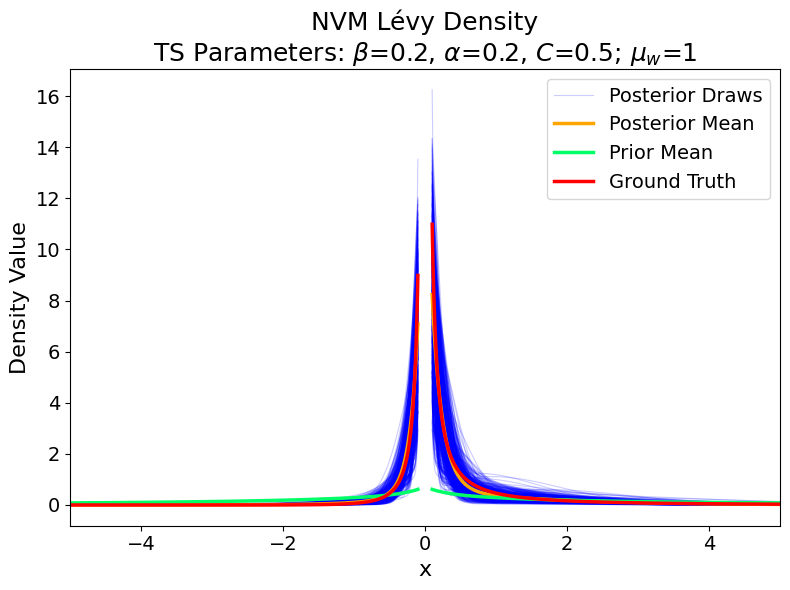


========== Projection input diagnostics ==========
observation_noise_level: 1e-05
sigmav2: 1.0000000000000002e-10
T: 10.0
increments shape: (99,)

Positive increments:
count: 50
min/max: 0.00027538471741372916 4.4522194524472765

Negative absolute increments:
count: 49
min/max: 3.3985589726004406e-05 0.47366726870795306

Projection support: (1e-05, 5.0)
Common density/TVD lower threshold: 0.1
divide_counts_by_T: True

========== Comparison range ==========
posterior range: (1e-05, 5.000000000000001)
projection support: (1e-05, 5.0)
comparison range: (0.1, 5.0)


Shared-resolution TVD search, p=2: 100%|██████████| 80/80 [00:00<00:00, 3960.21it/s]


========== Shared-resolution TVD-selected projection resolutions ==========
p=0 Lebesgue:
  shared bins: 58
  positive TVD: 0.946406680005331
  negative TVD: 0.380690528383609
  combined TVD: 1.32709720838894

p=2 Regularized:
  shared bins: 11
  positive TVD: 0.4741348836878926
  negative TVD: 0.0939954998769387
  combined TVD: 0.5681303835648313


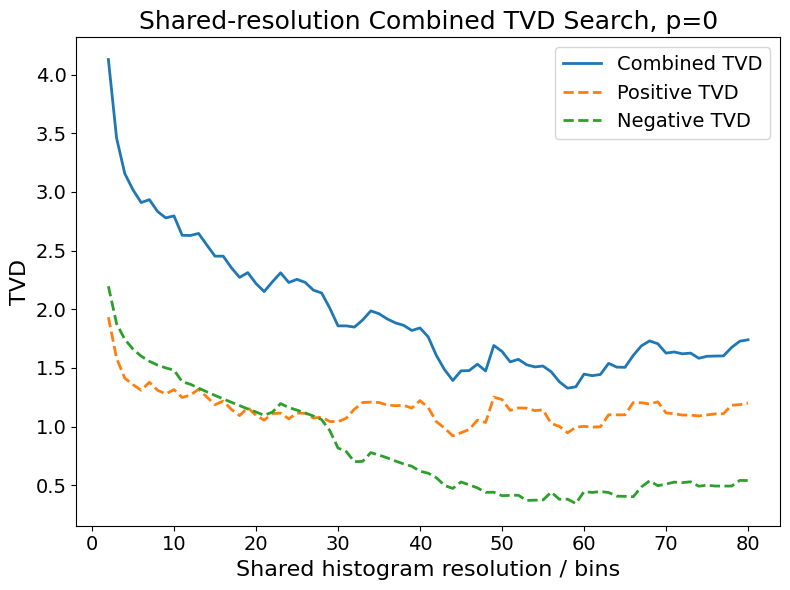

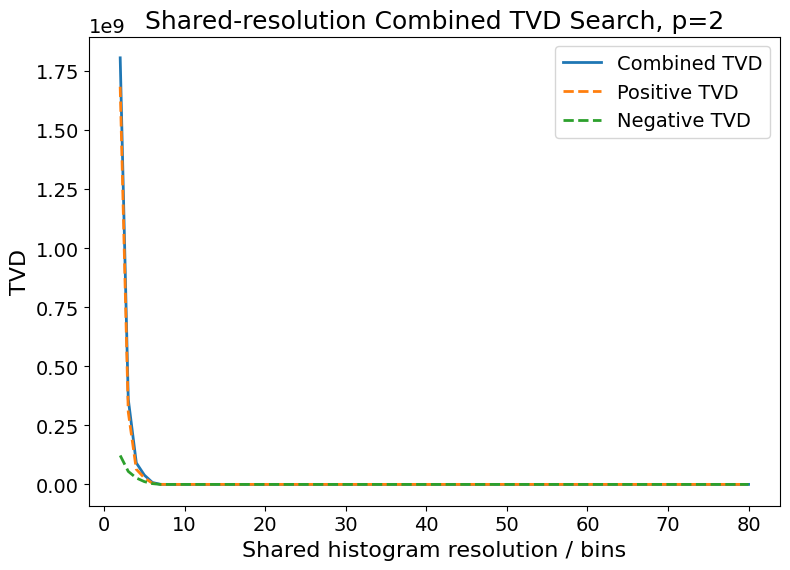

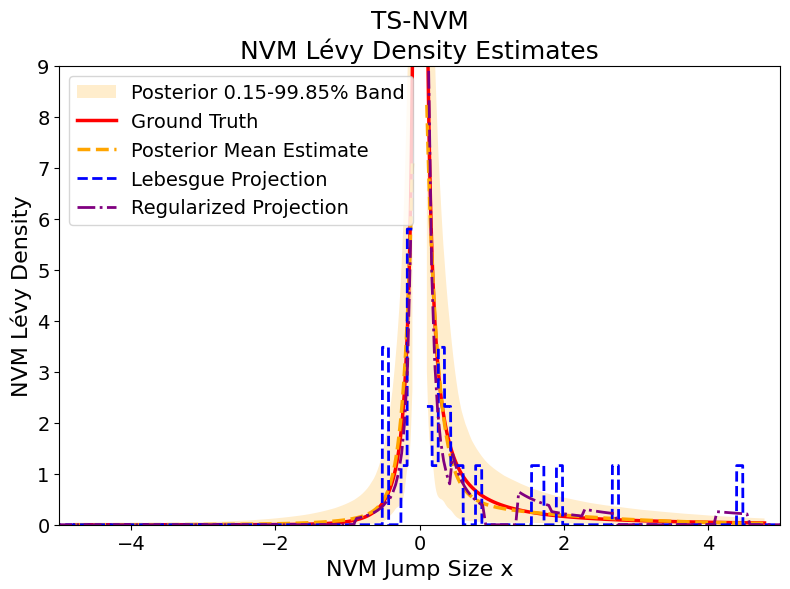

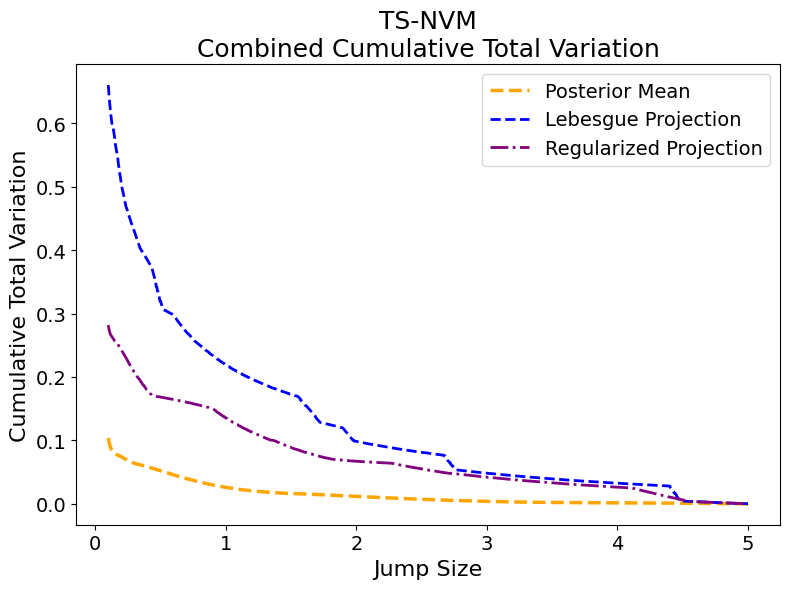

In [2]:
# ============================================================
# Density estimate performance comparison
# Posterior / Prior / Ground Truth / Projection density estimates
#
# Direct-observation / almost-noiseless TS-NVM case.
#
# Plotting convention matched to noisy TS-NVM config:
#   - NVM density axis covers [-5, 5].
#   - Projection estimates are also constructed on |x| in [1e-5, 5].
#   - Posterior credible band is 0.15 to 99.85 percentile.
#   - Density overlay plots truncate all curves and bands at same |x| threshold.
#   - Density overlay plots use xlim [-5, 5] and capped ylim [0, 9].
#   - Projection hyperparameters are selected by combined TVD.
# ============================================================

# ============================================================
# Imports
# ============================================================

factor = 1

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm

from posteriors import *
from Common_Tools import *
from Levy_Generators import *
from Levy_State_Space import *
from mcmc_sampler import *
from ground_truths import *
from mcmc_sampler_sigmaw2_conditional import *


# ============================================================
# Top-level settings
# ============================================================

# ----------------------------
# Files
# ----------------------------
simulation_file = "TS_driven_NVM.npz"
posterior_file = "nvm_direct_observations_sigmaw2_conditional.npz"

# ----------------------------
# Posterior sample processing
# ----------------------------
additional_burn_in = 0
num_samples_in_plot = 500

# ----------------------------
# Posterior / prior credible bands
# ----------------------------
lower_percentage = 0.15
upper_percentage = 99.85

# ----------------------------
# NVM density axis / plotting config
# ----------------------------
density_axis_epsilon = 1e-5
nvm_density_x_max = 5.0
nvm_axis_num_per_side = 300

density_realization_truncation_threshold = 0.1
density_plot_common_threshold = 0.1
density_plot_y_cap = 9.0

# ----------------------------
# Ground truth quadrature
# ----------------------------
ground_truth_z_min = density_axis_epsilon * 1e-2 / factor
ground_truth_z_max = 100.0 / factor
ground_truth_num_z = 5000

# ----------------------------
# Projection comparison
# ----------------------------
observation_noise_level = 1e-5

projection_epsilon = 1e-5
projection_x_min = projection_epsilon
projection_x_max = 5.0

resolution_list_p0 = np.arange(1, 81)
resolution_list_p2 = np.arange(1, 81)

divide_counts_by_T = True

search_n_common = 1000
cumulative_n_common = 1000

show_resolution_search_plots = True

rng = np.random.default_rng(123)

# ----------------------------
# Plot style
# ----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


# ============================================================
# Helper functions: NVM density
# ============================================================

def NVM_measure_density_conditional_on_sigmaw2(
    rates,
    positions,
    x_axis,
    muw_mu,
    muw_sigma2,
    sigmaw2,
):
    """
    NVM Levy density induced by a discrete subordinator Levy measure,
    marginalizing over mu_w ~ N(muw_mu, muw_sigma2), with fixed sigma_w^2.

        rho_J(x)
        = sum_i rates_i * N(
            x ; muw_mu * z_i,
                muw_sigma2 * z_i^2 + sigmaw2 * z_i
          )
    """
    rates = np.asarray(rates, dtype=float)
    positions = np.asarray(positions, dtype=float)
    x_axis = np.asarray(x_axis, dtype=float)

    valid = (
        np.isfinite(rates)
        & np.isfinite(positions)
        & (rates > 0)
        & (positions > 0)
    )

    rates = rates[valid]
    positions = positions[valid]

    if len(rates) == 0:
        return np.zeros_like(x_axis, dtype=float)

    if muw_sigma2 < 0:
        raise ValueError("muw_sigma2 must be non-negative.")
    if sigmaw2 <= 0:
        raise ValueError("sigmaw2 must be positive.")

    means = muw_mu * positions
    variances = muw_sigma2 * positions**2 + sigmaw2 * positions
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    pdf_components = norm.pdf(
        x_axis[None, :],
        loc=means[:, None],
        scale=stds[:, None],
    )

    return np.sum(rates[:, None] * pdf_components, axis=0)


def NVM_measure_density_sampled_on_sigmaw2(
    rates,
    positions,
    x_axis,
    muw_mu,
    muw_sigma2,
    sigmaw2,
    random_state=None,
):
    """
    One full posterior draw of the NVM Levy density:
      1. sample mu_w ~ N(muw_mu, muw_sigma2)
      2. compute sum_i rates_i * N(x; mu_w * z_i, sigmaw2 * z_i)
    """
    if isinstance(random_state, np.random.Generator):
        rng_local = random_state
    else:
        rng_local = np.random.default_rng(random_state)

    rates = np.asarray(rates, dtype=float)
    positions = np.asarray(positions, dtype=float)
    x_axis = np.asarray(x_axis, dtype=float)

    valid = (
        np.isfinite(rates)
        & np.isfinite(positions)
        & (rates > 0)
        & (positions > 0)
    )

    rates = rates[valid]
    positions = positions[valid]

    if len(rates) == 0:
        return np.zeros_like(x_axis, dtype=float), np.nan

    if muw_sigma2 < 0:
        raise ValueError("muw_sigma2 must be non-negative.")
    if sigmaw2 <= 0:
        raise ValueError("sigmaw2 must be positive.")

    muw_sample = rng_local.normal(loc=muw_mu, scale=np.sqrt(muw_sigma2))

    means = muw_sample * positions
    variances = sigmaw2 * positions
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    pdf_components = norm.pdf(
        x_axis[None, :],
        loc=means[:, None],
        scale=stds[:, None],
    )

    density = np.sum(rates[:, None] * pdf_components, axis=0)
    return density, muw_sample


def tempered_stable_levy_density(z, alpha, beta, C):
    """
    Tempered stable subordinator Levy density:

        rho_Z(z) = C z^{-1-alpha} exp(-beta z).
    """
    z = np.asarray(z, dtype=float)
    return C * z ** (-1.0 - alpha) * np.exp(-beta * z)


def NVM_ground_truth_density_by_quadrature(
    x_axis,
    muw,
    sigmaw,
    alpha,
    beta,
    C,
    z_min=1e-8,
    z_max=100.0,
    num_z=5000,
):
    """
    Numerical quadrature for the NVM Levy density:

        rho_J(x)
        = int_0^infty N(x; muw*z, sigmaw^2*z)
                      * C z^{-1-alpha} exp(-beta z) dz.
    """
    x_axis = np.asarray(x_axis, dtype=float)

    z_grid = np.logspace(np.log10(z_min), np.log10(z_max), num_z)
    rho_z = tempered_stable_levy_density(z_grid, alpha, beta, C)

    means = muw * z_grid
    variances = sigmaw**2 * z_grid
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    pdf_components = norm.pdf(
        x_axis[None, :],
        loc=means[:, None],
        scale=stds[:, None],
    )

    integrand = pdf_components * rho_z[:, None]
    return np.trapezoid(integrand, z_grid, axis=0)


# ============================================================
# Helper functions: projection estimates and TVD
# ============================================================

def regularized_projection_estimate_fixed_support(
    data,
    counts,
    resolution,
    regularized_power=0,
    x_min=1e-5,
    x_max=5.0,
):
    """
    Fixed-support projection estimator.

    data:
        positive absolute increments.

    counts:
        same shape as data. Should already include 1/T if estimating
        Levy density per unit time.

    p=0:
        estimates rho(x).

    p=2:
        estimates x^2 rho(x), then restores by multiplying x^{-2}.
    """
    data = np.asarray(data, dtype=float).reshape(-1)
    counts = np.asarray(counts, dtype=float).reshape(-1)

    valid = (
        np.isfinite(data)
        & np.isfinite(counts)
        & (data > 0)
        & (counts > 0)
        & (data >= x_min)
        & (data <= x_max)
    )

    data = data[valid]
    counts = counts[valid]

    resolution = int(resolution)

    hist_axis = np.linspace(x_min, x_max, resolution + 1)
    bin_width = hist_axis[1] - hist_axis[0]
    bin_centers = 0.5 * (hist_axis[:-1] + hist_axis[1:])

    hist_counts = np.zeros(len(hist_axis) - 1, dtype=float)

    if len(data) > 0:
        data_sorted_indices = np.argsort(data)
        data = data[data_sorted_indices]
        counts = counts[data_sorted_indices]

        data_pointer = 0
        axis_pointer = 0

        while data_pointer < len(data) and axis_pointer < len(hist_axis) - 1:
            if data[data_pointer] <= hist_axis[axis_pointer + 1]:
                hist_counts[axis_pointer] += (
                    counts[data_pointer]
                    * (data[data_pointer] ** regularized_power)
                    / bin_width
                )
                data_pointer += 1
            else:
                axis_pointer += 1

    results = np.zeros(resolution * len(bin_centers))
    x_axis = np.linspace(x_min, x_max, len(results))

    for i in range(len(bin_centers)):
        start = i * resolution
        end = min((i + 1) * resolution, len(results))
        results[start:end] = hist_counts[i]

    if regularized_power != 0:
        results = results * np.maximum(x_axis, 1e-300) ** (-regularized_power)

    return x_axis, results


def interp_positive_axis_linear_y(x_src, y_src, x_tgt):
    """
    Positive-axis interpolation on |x| using linear x and linear y.
    """
    x_src = np.asarray(x_src, dtype=float).reshape(-1)
    y_src = np.asarray(y_src, dtype=float).reshape(-1)
    x_tgt = np.asarray(x_tgt, dtype=float).reshape(-1)

    valid = np.isfinite(x_src) & np.isfinite(y_src) & (x_src >= 0)

    x_src = x_src[valid]
    y_src = y_src[valid]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    x_unique, idx = np.unique(x_src, return_index=True)
    x_src = x_unique
    y_src = y_src[idx]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    return np.interp(x_tgt, x_src, y_src, left=np.nan, right=np.nan)


def tvd_one_side(est_axis, est_density, gt_axis, gt_density, x_min, x_max, n_common=1000):
    """
    One-sided total-variation style error:

        0.5 * int |rho_hat - rho| dx.
    """
    grid = np.linspace(x_min, x_max, n_common)

    est_on_grid = interp_positive_axis_linear_y(est_axis, est_density, grid)
    gt_on_grid = interp_positive_axis_linear_y(gt_axis, gt_density, grid)

    mask = np.isfinite(est_on_grid) & np.isfinite(gt_on_grid)

    if np.sum(mask) < 5:
        return np.inf

    x = grid[mask]
    local_error = 0.5 * np.abs(est_on_grid[mask] - gt_on_grid[mask])

    return np.trapezoid(local_error, x)


def build_shared_resolution_records(
    positive_increments,
    positive_counts,
    negative_increments,
    negative_counts,
    resolution_list,
    regularized_power,
    x_min,
    x_max,
    gt_positive_axis_abs,
    gt_positive_density,
    gt_negative_axis_abs,
    gt_negative_density,
    tvd_x_min,
    n_common=1000,
):
    """
    Search over one shared resolution for positive and negative sides.
    """
    records = []
    best = None

    for resolution in tqdm(
        resolution_list,
        desc=f"Shared-resolution TVD search, p={regularized_power}",
    ):
        resolution = int(resolution)

        pos_axis, pos_density = regularized_projection_estimate_fixed_support(
            data=positive_increments,
            counts=positive_counts,
            resolution=resolution,
            regularized_power=regularized_power,
            x_min=x_min,
            x_max=x_max,
        )

        neg_axis, neg_density = regularized_projection_estimate_fixed_support(
            data=negative_increments,
            counts=negative_counts,
            resolution=resolution,
            regularized_power=regularized_power,
            x_min=x_min,
            x_max=x_max,
        )

        pos_tvd = tvd_one_side(
            est_axis=pos_axis,
            est_density=pos_density,
            gt_axis=gt_positive_axis_abs,
            gt_density=gt_positive_density,
            x_min=tvd_x_min,
            x_max=x_max,
            n_common=n_common,
        )

        neg_tvd = tvd_one_side(
            est_axis=neg_axis,
            est_density=neg_density,
            gt_axis=gt_negative_axis_abs,
            gt_density=gt_negative_density,
            x_min=tvd_x_min,
            x_max=x_max,
            n_common=n_common,
        )

        combined_tvd = pos_tvd + neg_tvd

        record = {
            "resolution": resolution,
            "regularized_power": int(regularized_power),
            "positive_tvd": float(pos_tvd),
            "negative_tvd": float(neg_tvd),
            "combined_tvd": float(combined_tvd),
            "positive_axis": np.asarray(pos_axis, dtype=float),
            "positive_density": np.asarray(pos_density, dtype=float),
            "negative_axis": np.asarray(neg_axis, dtype=float),
            "negative_density": np.asarray(neg_density, dtype=float),
            "tvd_x_min": float(tvd_x_min),
            "x_max": float(x_max),
        }

        records.append(record)

        if best is None or combined_tvd < best["combined_tvd"]:
            best = record

    return best, records


def plot_shared_resolution_search(records, title):
    resolutions = np.array([r["resolution"] for r in records], dtype=float)
    combined = np.array([r["combined_tvd"] for r in records], dtype=float)
    positive = np.array([r["positive_tvd"] for r in records], dtype=float)
    negative = np.array([r["negative_tvd"] for r in records], dtype=float)

    plt.figure(figsize=(8, 6))
    plt.plot(resolutions, combined, linewidth=2, label="Combined TVD")
    plt.plot(resolutions, positive, linewidth=2, linestyle="--", label="Positive TVD")
    plt.plot(resolutions, negative, linewidth=2, linestyle="--", label="Negative TVD")
    plt.xlabel("Shared histogram resolution / bins")
    plt.ylabel("TVD")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def cumulative_tv_small_to_large(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[1:] = np.cumsum(increments)

    return out


def cumulative_tv_large_to_small(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[:-1] = np.cumsum(increments[::-1])[::-1]

    return out


def evaluate_side_for_cumulative_tv(
    posterior_axis_signed,
    posterior_density,
    gt_density_on_posterior_axis,
    projection_axis_leb,
    projection_density_leb,
    projection_axis_reg,
    projection_density_reg,
    x_min,
    x_max,
    n_common=1000,
):
    x_post = np.abs(np.asarray(posterior_axis_signed, dtype=float).reshape(-1))
    y_post = np.asarray(posterior_density, dtype=float).reshape(-1)
    y_gt = np.asarray(gt_density_on_posterior_axis, dtype=float).reshape(-1)

    x_leb = np.asarray(projection_axis_leb, dtype=float).reshape(-1)
    y_leb = np.asarray(projection_density_leb, dtype=float).reshape(-1)

    x_reg = np.asarray(projection_axis_reg, dtype=float).reshape(-1)
    y_reg = np.asarray(projection_density_reg, dtype=float).reshape(-1)

    grid = np.linspace(x_min, x_max, n_common)

    gt_on_grid = interp_positive_axis_linear_y(x_post, y_gt, grid)
    post_on_grid = interp_positive_axis_linear_y(x_post, y_post, grid)
    leb_on_grid = interp_positive_axis_linear_y(x_leb, y_leb, grid)
    reg_on_grid = interp_positive_axis_linear_y(x_reg, y_reg, grid)

    mask = (
        np.isfinite(gt_on_grid)
        & np.isfinite(post_on_grid)
        & np.isfinite(leb_on_grid)
        & np.isfinite(reg_on_grid)
    )

    return {
        "x": grid[mask],
        "gt": gt_on_grid[mask],
        "post": post_on_grid[mask],
        "leb": leb_on_grid[mask],
        "reg": reg_on_grid[mask],
    }


def combine_pos_neg_cumulative_tv(pos_eval, neg_eval, direction="small_to_large"):
    x_all = np.concatenate([pos_eval["x"], neg_eval["x"]])

    gt_all = np.concatenate([pos_eval["gt"], neg_eval["gt"]])
    post_all = np.concatenate([pos_eval["post"], neg_eval["post"]])
    leb_all = np.concatenate([pos_eval["leb"], neg_eval["leb"]])
    reg_all = np.concatenate([pos_eval["reg"], neg_eval["reg"]])

    order = np.argsort(x_all)

    x_sorted = x_all[order]
    gt_sorted = gt_all[order]
    post_sorted = post_all[order]
    leb_sorted = leb_all[order]
    reg_sorted = reg_all[order]

    if direction == "small_to_large":
        return {
            "x": x_sorted,
            "post": cumulative_tv_small_to_large(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_small_to_large(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_small_to_large(x_sorted, reg_sorted, gt_sorted),
        }

    if direction == "large_to_small":
        return {
            "x": x_sorted,
            "post": cumulative_tv_large_to_small(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_large_to_small(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_large_to_small(x_sorted, reg_sorted, gt_sorted),
        }

    raise ValueError("direction must be 'small_to_large' or 'large_to_small'.")


# ============================================================
# Load simulation data / true parameters
# ============================================================

sim_data = np.load(simulation_file)

sigmaw = float(sim_data["sigmaw"])
sigmaw2 = sigmaw ** 2
beta = float(sim_data["beta"])
alpha = float(sim_data["alpha"])
C = float(sim_data["C"])
muw = float(sim_data["muw"])
T = float(sim_data["T"])
sim_rate = float(sim_data["sim_rate"])

time_axis = sim_data["time_axis"]
jump_times = sim_data["jump_times"]
nvm_jump_sizes = sim_data["nvm_jump_sizes"]

print("========== True parameters ==========")
print("beta:", beta)
print("alpha:", alpha)
print("C:", C)
print("muw:", muw)
print("sigmaw:", sigmaw)
print("sigmaw2:", sigmaw2)
print("T:", T)
print("sim_rate:", sim_rate)


# ============================================================
# Construct common NVM density axis [-5, 5]
# ============================================================

nvm_positive_axis = np.logspace(
    np.log10(density_axis_epsilon),
    np.log10(nvm_density_x_max),
    nvm_axis_num_per_side,
)

nvm_negative_axis = np.logspace(
    np.log10(density_axis_epsilon),
    np.log10(nvm_density_x_max),
    nvm_axis_num_per_side,
)

nvm_axis = np.concatenate(
    [
        -nvm_negative_axis[::-1],
        nvm_positive_axis,
    ]
)


# ============================================================
# Load posterior samples
# ============================================================

post_data = np.load(posterior_file)

sample_measures = post_data["sample_measures"][additional_burn_in:].copy()
sample_rates = post_data["sample_rates"][additional_burn_in:].copy()
sample_x_means = post_data["sample_x_means"][additional_burn_in:].copy()
sample_x_covariances = post_data["sample_x_covariances"][additional_burn_in:].copy()

S = len(sample_measures)

print("\n========== Posterior sample diagnostics ==========")
print("Number of posterior samples:", S)
print("sample_measures shape:", sample_measures.shape)
print("sample_rates shape:", sample_rates.shape)
print("sample_x_means shape:", sample_x_means.shape)
print("sample_x_covariances shape:", sample_x_covariances.shape)


# ============================================================
# Define prior
# ============================================================

rate_alpha_prior = 3
rate_beta_prior = 1

dir_K = 1000

initial_dir_alpha = 2.0
initial_base_gamma_a = 1.0
initial_base_gamma_b = 2.0

dir_alpha_a = 1.0
dir_alpha_b = 3.0

muw_mean = 0.0
muw_variance = 10.0

prior_num_samples = 1000

prior_sample_measures, prior_sample_rates = draw_IGSDP_Prior_Measures(
    rate_alpha_prior,
    rate_beta_prior,
    initial_base_gamma_a,
    1 / initial_base_gamma_b,
    dir_alpha_a,
    1 / dir_alpha_b,
    dir_K,
    num_samples=prior_num_samples,
)

prior_sample_measures = prior_sample_measures.copy()
prior_sample_rates = np.asarray(prior_sample_rates).copy()

P = len(prior_sample_measures)

print("\n========== Prior sample diagnostics ==========")
print("Number of prior samples:", P)


# ============================================================
# Posterior density analysis
# ============================================================

NVM_conditional_densities = []

for i in tqdm(range(S), desc="Posterior density analysis"):
    sample_measure = sample_measures[i].copy()
    sample_rate = sample_rates[i]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate

    rates_i = sample_measure[0, :]
    positions_i = sample_measure[1, :]

    x_mean_sample_series = sample_x_means[i]
    x_covariance_sample_series = sample_x_covariances[i]

    muw_posterior_mean = x_mean_sample_series[-1, -1, 0]
    muw_posterior_variance = x_covariance_sample_series[-1, -1, -1]

    density_i = NVM_measure_density_conditional_on_sigmaw2(
        rates_i,
        positions_i,
        nvm_axis,
        muw_posterior_mean,
        muw_posterior_variance,
        sigmaw2,
    )

    NVM_conditional_densities.append(density_i)

NVM_density_array = np.vstack(NVM_conditional_densities)

NVM_density_inferred = np.mean(NVM_density_array, axis=0)
nvm_density_lower_quantile = np.percentile(
    NVM_density_array,
    lower_percentage,
    axis=0,
)
nvm_density_upper_quantile = np.percentile(
    NVM_density_array,
    upper_percentage,
    axis=0,
)

print("\n========== Posterior density diagnostics ==========")
print("NVM_density_array shape:", NVM_density_array.shape)
print("nvm_density_lower_quantile shape:", nvm_density_lower_quantile.shape)
print("nvm_density_upper_quantile shape:", nvm_density_upper_quantile.shape)


# ============================================================
# Prior density analysis
# ============================================================

prior_NVM_conditional_densities = []

for i in tqdm(range(P), desc="Prior density analysis"):
    prior_measure = prior_sample_measures[i].copy()
    prior_rate = prior_sample_rates[i]

    prior_measure[0, :] = prior_measure[0, :] * prior_rate

    prior_rates_i = prior_measure[0, :]
    prior_positions_i = prior_measure[1, :]

    prior_density_i = NVM_measure_density_conditional_on_sigmaw2(
        prior_rates_i,
        prior_positions_i,
        nvm_axis,
        muw_mean,
        muw_variance,
        sigmaw2,
    )

    prior_NVM_conditional_densities.append(prior_density_i)

prior_NVM_density_array = np.vstack(prior_NVM_conditional_densities)

prior_NVM_density_inferred = np.mean(prior_NVM_density_array, axis=0)
prior_nvm_density_lower_quantile = np.percentile(
    prior_NVM_density_array,
    lower_percentage,
    axis=0,
)
prior_nvm_density_upper_quantile = np.percentile(
    prior_NVM_density_array,
    upper_percentage,
    axis=0,
)

print("\n========== Prior density diagnostics ==========")
print("prior_NVM_density_array shape:", prior_NVM_density_array.shape)
print("prior_nvm_density_lower_quantile shape:", prior_nvm_density_lower_quantile.shape)
print("prior_nvm_density_upper_quantile shape:", prior_nvm_density_upper_quantile.shape)


# ============================================================
# Ground truth NVM density by quadrature on common axis [-5, 5]
# ============================================================

NVM_density_ground_truth = NVM_ground_truth_density_by_quadrature(
    nvm_axis,
    muw=muw * factor,
    sigmaw=sigmaw * np.sqrt(factor),
    alpha=alpha,
    beta=beta * factor,
    C=C / (factor**alpha),
    z_min=ground_truth_z_min,
    z_max=ground_truth_z_max,
    num_z=ground_truth_num_z,
)


# ============================================================
# Save original density arrays
# ============================================================

original_nvm_axis = nvm_axis
original_NVM_density_inferred = NVM_density_inferred
original_prior_NVM_density_inferred = prior_NVM_density_inferred
original_NVM_density_ground_truth = NVM_density_ground_truth

original_nvm_density_lower_quantile = nvm_density_lower_quantile
original_nvm_density_upper_quantile = nvm_density_upper_quantile
original_prior_nvm_density_lower_quantile = prior_nvm_density_lower_quantile
original_prior_nvm_density_upper_quantile = prior_nvm_density_upper_quantile


# ============================================================
# Realization-based density plots
# ============================================================

density_title = (
    f"NVM Lévy Density\n"
    f"TS Parameters: "
    f"$\\beta$={beta * factor:.2g}, "
    f"$\\alpha$={alpha:.2g}, "
    f"$C$={C / (factor**alpha):.2g}; "
    f"$\\mu_w$={muw * factor:.2g}"
)

eps = density_realization_truncation_threshold

density_negative_mask = original_nvm_axis <= -eps
density_positive_mask = original_nvm_axis >= eps

density_negative_axis = original_nvm_axis[density_negative_mask]
density_positive_axis = original_nvm_axis[density_positive_mask]

posterior_density_negative_array = NVM_density_array[:, density_negative_mask]
posterior_density_positive_array = NVM_density_array[:, density_positive_mask]

prior_density_negative_array = prior_NVM_density_array[:, density_negative_mask]
prior_density_positive_array = prior_NVM_density_array[:, density_positive_mask]

posterior_density_mean_negative = original_NVM_density_inferred[density_negative_mask]
posterior_density_mean_positive = original_NVM_density_inferred[density_positive_mask]

prior_density_mean_negative = original_prior_NVM_density_inferred[density_negative_mask]
prior_density_mean_positive = original_prior_NVM_density_inferred[density_positive_mask]

posterior_density_lower_negative = original_nvm_density_lower_quantile[density_negative_mask]
posterior_density_upper_negative = original_nvm_density_upper_quantile[density_negative_mask]

posterior_density_lower_positive = original_nvm_density_lower_quantile[density_positive_mask]
posterior_density_upper_positive = original_nvm_density_upper_quantile[density_positive_mask]

ground_truth_density_negative = original_NVM_density_ground_truth[density_negative_mask]
ground_truth_density_positive = original_NVM_density_ground_truth[density_positive_mask]


# Select posterior/prior draws for visualization only.
num_posterior_density_draws = min(num_samples_in_plot, NVM_density_array.shape[0])
num_prior_density_draws = min(num_samples_in_plot, prior_NVM_density_array.shape[0])

posterior_density_indices = rng.choice(
    NVM_density_array.shape[0],
    size=num_posterior_density_draws,
    replace=False,
)

prior_density_indices = rng.choice(
    prior_NVM_density_array.shape[0],
    size=num_prior_density_draws,
    replace=False,
)


# Plot 1: posterior draws + posterior mean + prior mean + ground truth
plt.figure(figsize=(8, 6))

for j, idx in enumerate(posterior_density_indices):
    plt.plot(
        density_negative_axis,
        posterior_density_negative_array[idx],
        color="blue",
        alpha=0.2,
        linewidth=0.8,
        label="Posterior Draws" if j == 0 else None,
    )
    plt.plot(
        density_positive_axis,
        posterior_density_positive_array[idx],
        color="blue",
        alpha=0.2,
        linewidth=0.8,
    )

plt.plot(
    density_negative_axis,
    posterior_density_mean_negative,
    color="orange",
    linewidth=2.5,
    label="Posterior Mean",
)
plt.plot(
    density_positive_axis,
    posterior_density_mean_positive,
    color="orange",
    linewidth=2.5,
)

plt.plot(
    density_negative_axis,
    prior_density_mean_negative,
    color="#00FF66",
    linewidth=2.5,
    label="Prior Mean",
)
plt.plot(
    density_positive_axis,
    prior_density_mean_positive,
    color="#00FF66",
    linewidth=2.5,
)

plt.plot(
    density_negative_axis,
    ground_truth_density_negative,
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)
plt.plot(
    density_positive_axis,
    ground_truth_density_positive,
    color="red",
    linewidth=2.5,
)

plt.xlim(-nvm_density_x_max, nvm_density_x_max)
plt.title(density_title)
plt.xlabel("x")
plt.ylabel("Density Value")
plt.legend()
plt.tight_layout()
plt.show()



# ============================================================
# Projection estimates from observations
# ============================================================

nvm_process_path = integrate_to_path(
    nvm_jump_sizes,
    jump_times,
    time_axis,
)

sigmav2 = observation_noise_level ** 2

observations = langevin_observations(
    nvm_process_path,
    sigmav2 * np.identity(1),
    H=np.ones((1, 1)),
    mu=np.zeros((1, 1)),
)

observations = np.asarray(observations)

if observations.ndim == 1:
    increments = np.diff(observations).reshape(-1)
else:
    increments = np.diff(observations[0, :]).reshape(-1)

positive_increments_all = increments[increments >= projection_epsilon]
negative_increments_all = -increments[increments <= -projection_epsilon]

if divide_counts_by_T:
    positive_counts = np.ones_like(positive_increments_all, dtype=float) / float(T)
    negative_counts = np.ones_like(negative_increments_all, dtype=float) / float(T)
else:
    positive_counts = np.ones_like(positive_increments_all, dtype=float)
    negative_counts = np.ones_like(negative_increments_all, dtype=float)

print("\n========== Projection input diagnostics ==========")
print("observation_noise_level:", observation_noise_level)
print("sigmav2:", sigmav2)
print("T:", float(T))
print("increments shape:", increments.shape)

print("\nPositive increments:")
print("count:", len(positive_increments_all))
if len(positive_increments_all) > 0:
    print("min/max:", positive_increments_all.min(), positive_increments_all.max())

print("\nNegative absolute increments:")
print("count:", len(negative_increments_all))
if len(negative_increments_all) > 0:
    print("min/max:", negative_increments_all.min(), negative_increments_all.max())

print("\nProjection support:", (projection_x_min, projection_x_max))
print("Common density/TVD lower threshold:", density_plot_common_threshold)
print("divide_counts_by_T:", divide_counts_by_T)


# ============================================================
# Prepare posterior / ground truth density sides for comparison
# ============================================================

post_neg_mask_full = original_nvm_axis < 0
post_pos_mask_full = original_nvm_axis > 0

posterior_negative_axis_full = original_nvm_axis[post_neg_mask_full]
posterior_positive_axis_full = original_nvm_axis[post_pos_mask_full]

posterior_density_negative_full = original_NVM_density_inferred[post_neg_mask_full]
posterior_density_positive_full = original_NVM_density_inferred[post_pos_mask_full]

ground_truth_density_negative_full = original_NVM_density_ground_truth[post_neg_mask_full]
ground_truth_density_positive_full = original_NVM_density_ground_truth[post_pos_mask_full]

posterior_density_band_lower_negative_full = original_nvm_density_lower_quantile[post_neg_mask_full]
posterior_density_band_upper_negative_full = original_nvm_density_upper_quantile[post_neg_mask_full]

posterior_density_band_lower_positive_full = original_nvm_density_lower_quantile[post_pos_mask_full]
posterior_density_band_upper_positive_full = original_nvm_density_upper_quantile[post_pos_mask_full]

posterior_abs_axis = np.abs(np.asarray(original_nvm_axis, dtype=float))
posterior_abs_axis = posterior_abs_axis[
    np.isfinite(posterior_abs_axis) & (posterior_abs_axis > 0)
]

posterior_min_abs_x = float(np.min(posterior_abs_axis))
posterior_max_abs_x = float(np.max(posterior_abs_axis))

comparison_x_min = max(
    density_plot_common_threshold,
    posterior_min_abs_x,
    projection_x_min,
)
comparison_x_max = min(
    projection_x_max,
    posterior_max_abs_x,
)

if comparison_x_max <= comparison_x_min:
    raise ValueError(
        f"No overlap between posterior inference range and projection support: "
        f"posterior=[{posterior_min_abs_x}, {posterior_max_abs_x}], "
        f"projection=[{projection_x_min}, {projection_x_max}], "
        f"threshold={density_plot_common_threshold}."
    )

print("\n========== Comparison range ==========")
print("posterior range:", (posterior_min_abs_x, posterior_max_abs_x))
print("projection support:", (projection_x_min, projection_x_max))
print("comparison range:", (comparison_x_min, comparison_x_max))


# ============================================================
# Ground-truth positive |x| axes for TVD search
# ============================================================

gt_positive_axis_abs = np.abs(posterior_positive_axis_full)
gt_negative_axis_abs = np.abs(posterior_negative_axis_full)

pos_order = np.argsort(gt_positive_axis_abs)
neg_order = np.argsort(gt_negative_axis_abs)

gt_positive_axis_abs_sorted = gt_positive_axis_abs[pos_order]
gt_positive_density_sorted = ground_truth_density_positive_full[pos_order]

gt_negative_axis_abs_sorted = gt_negative_axis_abs[neg_order]
gt_negative_density_sorted = ground_truth_density_negative_full[neg_order]


# ============================================================
# Shared-resolution TVD search
# ============================================================

best_p0, records_p0 = build_shared_resolution_records(
    positive_increments=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p0,
    regularized_power=0,
    x_min=projection_x_min,
    x_max=projection_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_x_min=comparison_x_min,
    n_common=search_n_common,
)

best_p2, records_p2 = build_shared_resolution_records(
    positive_increments=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p2,
    regularized_power=2,
    x_min=projection_x_min,
    x_max=projection_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_x_min=comparison_x_min,
    n_common=search_n_common,
)

print("\n========== Shared-resolution TVD-selected projection resolutions ==========")
print("p=0 Lebesgue:")
print("  shared bins:", best_p0["resolution"])
print("  positive TVD:", best_p0["positive_tvd"])
print("  negative TVD:", best_p0["negative_tvd"])
print("  combined TVD:", best_p0["combined_tvd"])

print("\np=2 Regularized:")
print("  shared bins:", best_p2["resolution"])
print("  positive TVD:", best_p2["positive_tvd"])
print("  negative TVD:", best_p2["negative_tvd"])
print("  combined TVD:", best_p2["combined_tvd"])

if show_resolution_search_plots:
    plot_shared_resolution_search(
        records_p0,
        "Shared-resolution Combined TVD Search, p=0",
    )

    plot_shared_resolution_search(
        records_p2,
        "Shared-resolution Combined TVD Search, p=2",
    )


# ============================================================
# Extract selected projection estimates
# ============================================================

positive_best_p0 = {
    "resolution": best_p0["resolution"],
    "axis": best_p0["positive_axis"],
    "density": best_p0["positive_density"],
    "tvd": best_p0["positive_tvd"],
}
negative_best_p0 = {
    "resolution": best_p0["resolution"],
    "axis": best_p0["negative_axis"],
    "density": best_p0["negative_density"],
    "tvd": best_p0["negative_tvd"],
}

positive_best_p2 = {
    "resolution": best_p2["resolution"],
    "axis": best_p2["positive_axis"],
    "density": best_p2["positive_density"],
    "tvd": best_p2["positive_tvd"],
}
negative_best_p2 = {
    "resolution": best_p2["resolution"],
    "axis": best_p2["negative_axis"],
    "density": best_p2["negative_density"],
    "tvd": best_p2["negative_tvd"],
}


# ============================================================
# Plot masks
# All density overlay elements use SAME common lower threshold.
# ============================================================

ground_truth_neg_plot_mask = (
    (posterior_negative_axis_full <= -comparison_x_min)
    & (posterior_negative_axis_full >= -comparison_x_max)
)

ground_truth_pos_plot_mask = (
    (posterior_positive_axis_full >= comparison_x_min)
    & (posterior_positive_axis_full <= comparison_x_max)
)

posterior_mean_neg_plot_mask = ground_truth_neg_plot_mask.copy()
posterior_mean_pos_plot_mask = ground_truth_pos_plot_mask.copy()

posterior_band_neg_plot_mask = ground_truth_neg_plot_mask.copy()
posterior_band_pos_plot_mask = ground_truth_pos_plot_mask.copy()

neg_p0_mask = (
    (negative_best_p0["axis"] >= comparison_x_min)
    & (negative_best_p0["axis"] <= comparison_x_max)
)

pos_p0_mask = (
    (positive_best_p0["axis"] >= comparison_x_min)
    & (positive_best_p0["axis"] <= comparison_x_max)
)

neg_p2_mask = (
    (negative_best_p2["axis"] >= comparison_x_min)
    & (negative_best_p2["axis"] <= comparison_x_max)
)

pos_p2_mask = (
    (positive_best_p2["axis"] >= comparison_x_min)
    & (positive_best_p2["axis"] <= comparison_x_max)
)


# ============================================================
# Overlay plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.fill_between(
    posterior_negative_axis_full[posterior_band_neg_plot_mask],
    posterior_density_band_lower_negative_full[posterior_band_neg_plot_mask],
    posterior_density_band_upper_negative_full[posterior_band_neg_plot_mask],
    color="orange",
    alpha=0.2,
    linewidth=0,
    label=f"Posterior {lower_percentage:g}-{upper_percentage:g}% Band",
)
plt.fill_between(
    posterior_positive_axis_full[posterior_band_pos_plot_mask],
    posterior_density_band_lower_positive_full[posterior_band_pos_plot_mask],
    posterior_density_band_upper_positive_full[posterior_band_pos_plot_mask],
    color="orange",
    alpha=0.2,
    linewidth=0,
)

plt.plot(
    posterior_negative_axis_full[ground_truth_neg_plot_mask],
    ground_truth_density_negative_full[ground_truth_neg_plot_mask],
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)
plt.plot(
    posterior_positive_axis_full[ground_truth_pos_plot_mask],
    ground_truth_density_positive_full[ground_truth_pos_plot_mask],
    color="red",
    linewidth=2.5,
)

plt.plot(
    posterior_negative_axis_full[posterior_mean_neg_plot_mask],
    posterior_density_negative_full[posterior_mean_neg_plot_mask],
    color="orange",
    linewidth=2.5,
    linestyle="--",
    label="Posterior Mean Estimate",
)
plt.plot(
    posterior_positive_axis_full[posterior_mean_pos_plot_mask],
    posterior_density_positive_full[posterior_mean_pos_plot_mask],
    color="orange",
    linewidth=2.5,
    linestyle="--",
)

plt.plot(
    -negative_best_p0["axis"][neg_p0_mask],
    negative_best_p0["density"][neg_p0_mask],
    color="blue",
    linewidth=2,
    linestyle="--",
    label="Lebesgue Projection",
)
plt.plot(
    positive_best_p0["axis"][pos_p0_mask],
    positive_best_p0["density"][pos_p0_mask],
    color="blue",
    linewidth=2,
    linestyle="--",
)

plt.plot(
    -negative_best_p2["axis"][neg_p2_mask],
    negative_best_p2["density"][neg_p2_mask],
    color="purple",
    linewidth=2,
    linestyle="-.",
    label="Regularized Projection",
)
plt.plot(
    positive_best_p2["axis"][pos_p2_mask],
    positive_best_p2["density"][pos_p2_mask],
    color="purple",
    linewidth=2,
    linestyle="-.",
)

plt.xlim(-nvm_density_x_max, nvm_density_x_max)
plt.ylim(0, density_plot_y_cap)
plt.xlabel("NVM Jump Size x")
plt.ylabel("NVM Lévy Density")
plt.title("TS-NVM\nNVM Lévy Density Estimates")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Cumulative TVD evaluation
# ============================================================

pos_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_positive_axis_full,
    posterior_density=posterior_density_positive_full,
    gt_density_on_posterior_axis=ground_truth_density_positive_full,
    projection_axis_leb=positive_best_p0["axis"],
    projection_density_leb=positive_best_p0["density"],
    projection_axis_reg=positive_best_p2["axis"],
    projection_density_reg=positive_best_p2["density"],
    x_min=comparison_x_min,
    x_max=comparison_x_max,
    n_common=cumulative_n_common,
)

neg_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_negative_axis_full,
    posterior_density=posterior_density_negative_full,
    gt_density_on_posterior_axis=ground_truth_density_negative_full,
    projection_axis_leb=negative_best_p0["axis"],
    projection_density_leb=negative_best_p0["density"],
    projection_axis_reg=negative_best_p2["axis"],
    projection_density_reg=negative_best_p2["density"],
    x_min=comparison_x_min,
    x_max=comparison_x_max,
    n_common=cumulative_n_common,
)

combined_tv_large_to_small = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="large_to_small",
)

combined_tv_small_to_large = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="small_to_large",
)


# ============================================================
# Plot cumulative TVD: large to small
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["post"],
    color="orange",
    linestyle="--",
    linewidth=2.5,
    label="Posterior Mean",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["leb"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Lebesgue Projection",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["reg"],
    color="purple",
    linestyle="-.",
    linewidth=2,
    label="Regularized Projection",
)

plt.xlabel("Jump Size")
plt.ylabel("Cumulative Total Variation")
plt.title("TS-NVM\nCombined Cumulative Total Variation")
plt.legend()
plt.tight_layout()
plt.show()



## Noisy Tempered Stable Process Driven NVM Process Experiment

### Sampling and Inference of Our Approach

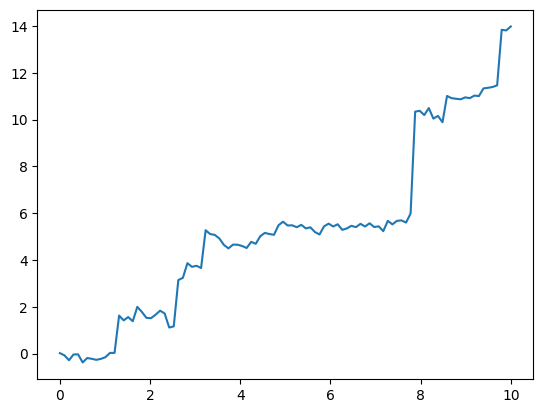

In [1]:
#Load the observations
# Load the saved data, including the initial jump sizes and times here
#The initialization is through random generation of a set of subordinator series
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
data = np.load("TS_driven_NVM.npz")
sim_rate = data["sim_rate"]
observation_noise_level = data["observation_noise_level"]
T = data["T"]
time_axis = data["time_axis"]
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
sigmaw = data["sigmaw"]
kv = data["kv"]
sub_jump_sizes = data["sub_jump_sizes"]
jump_times = data["jump_times"]
original_path = data["original_path"]
nvm_jump_sizes = data["nvm_jump_sizes"]



sigmaw2 = sigmaw ** 2
sigmav2 = kv * sigmaw ** 2

nvm_process_path = integrate_to_path(nvm_jump_sizes,jump_times,time_axis)


observation_noise_level = 0.1
sigmav2 = observation_noise_level**2
observations = langevin_observations(nvm_process_path,(observation_noise_level**2)*np.identity(1),H=np.ones((1,1)),mu=np.zeros((1,1)))
plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()


In [ ]:
#Extended MCMC Algorithm with Hyper-parameter Sampling
#Inference Parameters
burn_in = 200000
num_iter = 500000  
block_width = 5
overlapping_width = 2
#Make a guess for sigmaw2
sigmaw2 = 1.0

#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition. Note that the Gamma base to DP here follows the shape-scale convention
initial_dir_alpha = 10
initial_base_gamma_a = 1
initial_base_gamma_b=2 #scale, not rate

#Shape-scale convention here.
dir_alpha_a = 1
dir_alpha_b = 1

base_gamma_a_mean = initial_base_gamma_a
base_gamma_a_std = 1000.0
base_gamma_b_mean = initial_base_gamma_b
base_gamma_b_std = 1000.0
base_gamma_a_step_size = 0.0
base_gamma_b_step_size = 0.0

#Define the muw prior
prior_muw_mean = 0.0
prior_muw_variance = 10.0
#Generate Initilisation of the jump sizes
wrong_beta = 1*beta
wrong_alpha = alpha
wrong_C = 1*C

initial_jump_sizes,initial_jump_times = tempered_stable_process_jumps((wrong_beta,wrong_alpha,wrong_C),T,sim_rate)
grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
sample_measures,sample_rates,sample_paths,sample_x_means,sample_x_covariances,dir_alphas,base_gamma_as,base_gamma_bs = nvm_lm_theta_inference_all_DP_alpha_inferred_Gamma_base_Gaussian_update_conditional_sigmaw2(num_iter,block_width,overlapping_width,observations,time_axis,initial_jump_sizes,initial_jump_times,sigmav2,rate_alpha_prior,rate_beta_prior,dir_K,dir_alpha_a,dir_alpha_b,base_gamma_a_mean,base_gamma_a_std,base_gamma_b_mean,base_gamma_b_std,sigmaw2,base_gamma_a_step_size,base_gamma_b_step_size,dir_alpha=initial_dir_alpha,base_gamma_a=initial_base_gamma_a,base_gamma_b=initial_base_gamma_b,muw_prior_mean=prior_muw_mean,muw_prior_variance=prior_muw_variance)
#Discard the burn-in
sample_measures = sample_measures[burn_in:]
sample_rates = sample_rates[burn_in:]
sample_paths = sample_paths[burn_in:]
sample_x_means = sample_x_means[burn_in:]
sample_x_covariances = sample_x_covariances[burn_in:]


np.savez(
    "noisy_nvm_direct_observations_sigmaw2_conditional.npz",
    sample_measures=sample_measures,
    sample_rates=sample_rates,
    sample_paths=sample_paths,
    sample_x_means=sample_x_means,
    sample_x_covariances=sample_x_covariances,
    dir_alphas = dir_alphas
    
)


Langevin System Inference Progress::   0%|          | 75/500000 [00:06<11:01:00, 12.61it/s]

Making Prior Visualization: 100%|██████████| 1000/1000 [00:03<00:00, 333.29it/s]


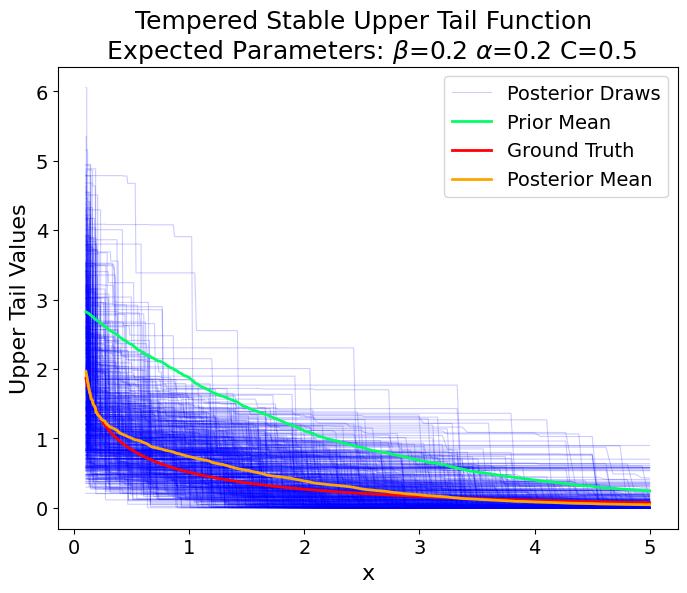

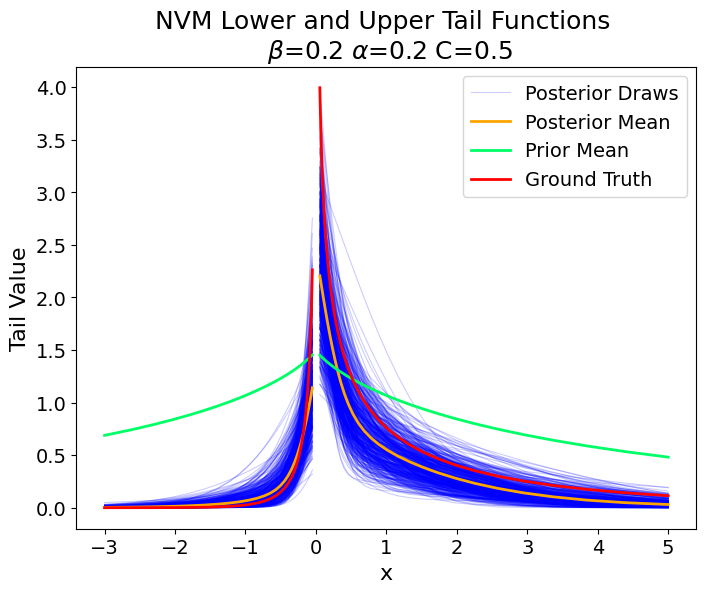

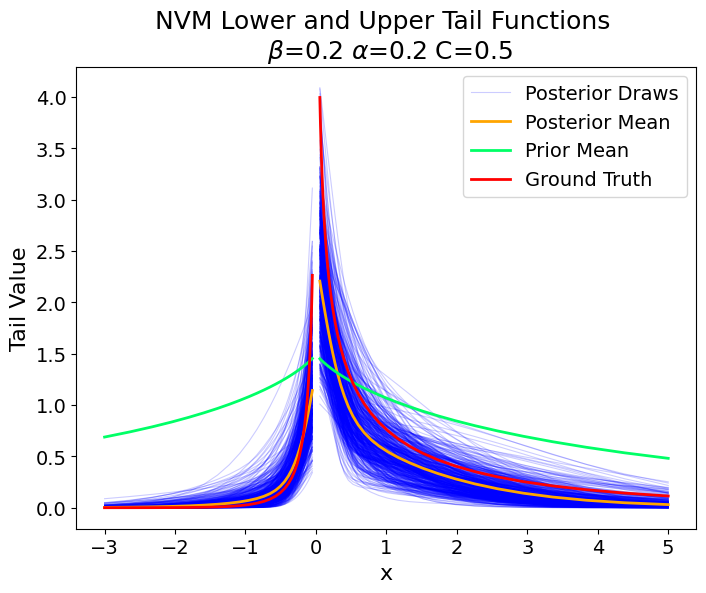

0.7465303959826737
(300001,)
(300001,)


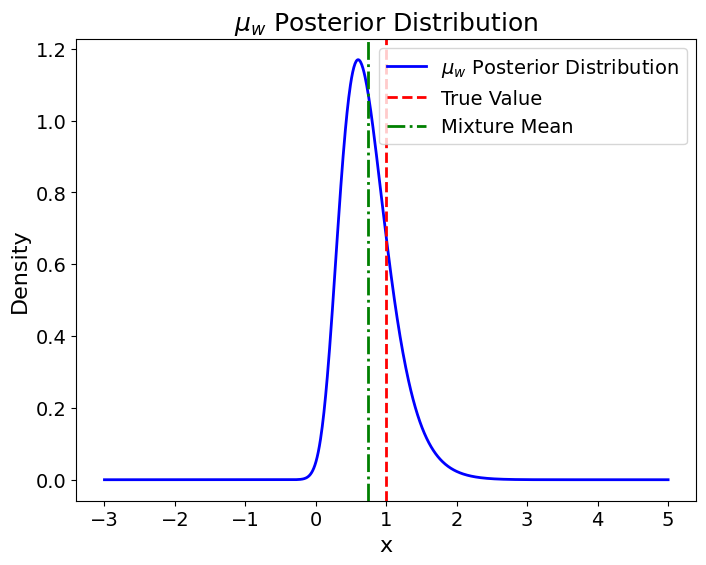

In [1]:
## Showing instead the realizations than the confidence intervals





factor = 1
# Comparison with the Priors
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *



num_samples_in_plot = 500
plt.rcParams.update({
    "figure.figsize": (14, 6),  # overall figure size
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
#Load the observation dataset to just get the sigmaw2 value
data = np.load("TS_driven_NVM.npz")
sigmaw = data["sigmaw"]
sigmaw2 = sigmaw ** 2
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
T = data["T"]
sim_rate = data["sim_rate"]


#Quantile selection for the visualization
lower_percentage = 0.15
upper_percentage = 99.85

additional_burn_in = 0


#Load the experimental results stored for the samples
data = np.load("noisy_nvm_direct_observations_sigmaw2_conditional.npz")
sample_measures = data["sample_measures"][additional_burn_in:]
sample_rates = data["sample_rates"][additional_burn_in:]
sample_x_means = data["sample_x_means"][additional_burn_in:]
sample_x_covariances = data["sample_x_covariances"][additional_burn_in:]


#Define the prior
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition
initial_dir_alpha = 10.0
initial_base_gamma_a = 1
initial_base_gamma_b= 2

dir_alpha_a = 1.0
dir_alpha_b = 3
#Normal(0,1) has been used for all the muw priors
muw_mean = 0
muw_variance = 10
#Subordinator Prior Measures for Visualization
prior_sample_measures,prior_sample_rates = draw_IGSDP_Prior_Measures(rate_alpha_prior,rate_beta_prior,initial_base_gamma_a,1/initial_base_gamma_b,dir_alpha_a,1/dir_alpha_b,dir_K,num_samples=1000)




#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
real_posterior_NVM_conditional_lower_tails = []
real_posterior_NVM_conditional_upper_tails = []

overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 1e-5 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.logspace(np.log10(epsilon),np.log10(5),1000) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.logspace(np.log10(epsilon),np.log10(5),100)
nvm_negative_axis =np.logspace(np.log10(epsilon),np.log10(3),100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#The mean estimates
    real_posterior_lower_tail_conditional,real_posterior_upper_tail_conditional,real_posterior_muw_sample = NVM_measure_tail_functions_sampled_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#Inference for the entire posterior distribution but not just the mean
    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    real_posterior_NVM_conditional_lower_tails.append(real_posterior_lower_tail_conditional)
    real_posterior_NVM_conditional_upper_tails.append(real_posterior_upper_tail_conditional)



prior_sample_upper_tail_measures = []
prior_overall_rates_list = []
prior_overall_positions_list = []
prior_NVM_conditional_lower_tails = []
prior_NVM_conditional_upper_tails = []
for i in tqdm(range(len(prior_sample_measures)),desc="Making Prior Visualization"):
    prior_sample_rate = prior_sample_rates[i]
    prior_sample_measure = prior_sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    prior_sample_measure[0, :] = prior_sample_measure[0, :] * prior_sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    prior_sample_measures[i] = prior_sample_measure
    #Then extract the information from the L\'evy density
    prior_rates = prior_sample_measure[0, :]
    prior_positions = prior_sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    prior_sample_upper_tail_measure = DP_upper_tail_projection(prior_positions,prior_rates,x_axis)
    prior_sample_upper_tail_measures.append(prior_sample_upper_tail_measure)
    # Collect arrays in lists
    prior_overall_rates_list.append(prior_rates)
    prior_overall_positions_list.append(prior_positions)
    
    prior_lower_tail_conditional,prior_upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(prior_rates, prior_positions, nvm_axis, muw_mean, muw_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    prior_NVM_conditional_lower_tails.append(prior_lower_tail_conditional)
    prior_NVM_conditional_upper_tails.append(prior_upper_tail_conditional)

#Subordinator Procesing
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/(len(sample_measures))

prior_rates = np.concatenate(prior_overall_rates_list)
prior_positions = np.concatenate(prior_overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
prior_mean_weights = prior_rates/(len(prior_sample_measures))

posterior_mean_upper_tail_values = DP_upper_tail_projection(positions,mean_weights,x_axis)
prior_mean_upper_tail_values = DP_upper_tail_projection(prior_positions,prior_mean_weights,x_axis)
ground_truth_upper_tail_values = upper_tail_ts_measure(alpha, beta*factor, C/(factor**alpha),x_axis)
# Stack the samples into a 2D array for easier quantile computation
ts_sample_array = np.vstack(sample_upper_tail_measures)

# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
ts_lower_quantile = np.percentile(ts_sample_array, lower_percentage, axis=0)
ts_upper_quantile = np.percentile(ts_sample_array, upper_percentage, axis=0)
prior_ts_sample_array = np.vstack(prior_sample_upper_tail_measures)
# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
prior_ts_lower_quantile = np.percentile(prior_ts_sample_array, lower_percentage, axis=0)
prior_ts_upper_quantile = np.percentile(prior_ts_sample_array, upper_percentage, axis=0)




#NVM Processing
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
real_posterior_NVM_upper_tail_array = np.vstack(real_posterior_NVM_conditional_upper_tails)
real_posterior_NVM_lower_tail_array = np.vstack(real_posterior_NVM_conditional_lower_tails)
prior_NVM_upper_tail_array = np.vstack(prior_NVM_conditional_upper_tails)
prior_NVM_lower_tail_array = np.vstack(prior_NVM_conditional_lower_tails)

    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

real_posterior_nvm_upper_tail_lower_quantile = np.percentile(real_posterior_NVM_upper_tail_array, lower_percentage, axis=0)
real_posterior_nvm_upper_tail_upper_quantile = np.percentile(real_posterior_NVM_upper_tail_array, upper_percentage, axis=0)
real_posterior_nvm_lower_tail_lower_quantile = np.percentile(real_posterior_NVM_lower_tail_array, lower_percentage, axis=0)
real_posterior_nvm_lower_tail_upper_quantile = np.percentile(real_posterior_NVM_lower_tail_array, upper_percentage, axis=0)


prior_nvm_upper_tail_lower_quantile = np.percentile(prior_NVM_upper_tail_array, lower_percentage, axis=0)
prior_nvm_upper_tail_upper_quantile = np.percentile(prior_NVM_upper_tail_array, upper_percentage, axis=0)
prior_nvm_lower_tail_lower_quantile = np.percentile(prior_NVM_lower_tail_array, lower_percentage, axis=0)
prior_nvm_lower_tail_upper_quantile = np.percentile(prior_NVM_lower_tail_array, upper_percentage, axis=0)


NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)
real_posterior_NVM_upper_tail_inferred = np.mean(real_posterior_NVM_upper_tail_array,axis=0)
real_posterior_NVM_lower_tail_inferred = np.mean(real_posterior_NVM_lower_tail_array,axis=0)
prior_NVM_upper_tail_inferred = np.mean(prior_NVM_upper_tail_array,axis=0)
prior_NVM_lower_tail_inferred = np.mean(prior_NVM_lower_tail_array,axis=0)


#NVM ground truth tails generation
gt_sub_jump_sizes,gt_jump_times = tempered_stable_process_jumps((beta*factor,alpha,C/(factor**alpha)),T*5000,sim_rate)#Generate a bunch of jump sizes and times for computing the ground truth
NVM_lower_tail_ground_truth,NVM_upper_tail_ground_truth = NVM_ground_truth_tail_functions(nvm_axis,gt_sub_jump_sizes[0,:],muw*factor,sigmaw*np.sqrt(factor),alpha,beta*factor,C/(factor**alpha),epsilon*1e-2/factor)#The truncated threshold for the approximation needs also be adjusted for jump size scaling.
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]



original_x_axis = x_axis
original_ground_truth_upper_tail_values = ground_truth_upper_tail_values
original_posterior_mean_upper_tail_values = posterior_mean_upper_tail_values
original_ts_lower_quantile = ts_lower_quantile
original_ts_upper_quantile = ts_upper_quantile


#Generating the thinned sample measures for visualization

thinned_prior_ts_array = thin_uniform(prior_ts_sample_array,num_samples_in_plot)
thinned_posterior_ts_array = thin_uniform(ts_sample_array,num_samples_in_plot)
thinned_prior_nvm_upper_tail_array = thin_uniform(prior_NVM_upper_tail_array,num_samples_in_plot)
thinned_posterior_nvm_upper_tail_array = thin_uniform(NVM_upper_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_upper_tail_array = thin_uniform(real_posterior_NVM_upper_tail_array,num_samples_in_plot)
thinned_prior_nvm_lower_tail_array = thin_uniform(prior_NVM_lower_tail_array,num_samples_in_plot)
thinned_posterior_nvm_lower_tail_array = thin_uniform(NVM_lower_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_lower_tail_array = thin_uniform(real_posterior_NVM_lower_tail_array,num_samples_in_plot)





#Plotting Sessions
#Plotting the subordinator upper tail functions
#Compute the upper tail measure for the DP posterior mean measure and also the ground truth
#Compute the quantiles given the x_axis

truncation_threshold = 0.1
mask = x_axis >= truncation_threshold
x_axis = original_x_axis[mask]
ground_truth_upper_tail_values = original_ground_truth_upper_tail_values[mask]
posterior_mean_upper_tail_values = original_posterior_mean_upper_tail_values[mask]
prior_mean_upper_tail_values = prior_mean_upper_tail_values[mask]
ts_lower_quantile = original_ts_lower_quantile[mask]
ts_upper_quantile = original_ts_upper_quantile[mask]
prior_ts_lower_quantile = prior_ts_lower_quantile[mask]
prior_ts_upper_quantile = prior_ts_upper_quantile[mask]

thinned_prior_ts_array = thinned_prior_ts_array[:,mask]
thinned_posterior_ts_array = thinned_posterior_ts_array[:,mask]


original_negative_axis = negative_axis
original_nvm_lower_tail_lower_quantile = nvm_lower_tail_lower_quantile
original_nvm_lower_tail_upper_quantile = nvm_lower_tail_upper_quantile
original_NVM_lower_tail_inferred = NVM_lower_tail_inferred
original_NVM_lower_tail_ground_truth = NVM_lower_tail_ground_truth

original_positive_axis = positive_axis
original_nvm_upper_tail_lower_quantile = nvm_upper_tail_lower_quantile
original_nvm_upper_tail_upper_quantile = nvm_upper_tail_upper_quantile
original_NVM_upper_tail_inferred = NVM_upper_tail_inferred
original_NVM_upper_tail_ground_truth = NVM_upper_tail_ground_truth

original_real_posterior_nvm_lower_tail_lower_quantile = real_posterior_nvm_lower_tail_lower_quantile
original_real_posterior_nvm_lower_tail_upper_quantile = real_posterior_nvm_lower_tail_upper_quantile
original_real_posterior_NVM_lower_tail_inferred = real_posterior_NVM_lower_tail_inferred

original_real_posterior_nvm_upper_tail_lower_quantile = real_posterior_nvm_upper_tail_lower_quantile
original_real_posterior_nvm_upper_tail_upper_quantile = real_posterior_nvm_upper_tail_upper_quantile
original_real_posterior_NVM_upper_tail_inferred = real_posterior_NVM_upper_tail_inferred


#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
truncation_threshold = 0.05
negative_axis = nvm_axis[nvm_axis < -0]
positive_axis = nvm_axis[nvm_axis > 0]
negative_axis_mask = negative_axis<-truncation_threshold
positive_axis_mask = positive_axis>truncation_threshold

negative_axis = original_negative_axis[negative_axis_mask]
nvm_lower_tail_lower_quantile = original_nvm_lower_tail_lower_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_lower_quantile = original_real_posterior_nvm_lower_tail_lower_quantile[negative_axis_mask]
prior_nvm_lower_tail_lower_quantile = prior_nvm_lower_tail_lower_quantile[negative_axis_mask]
nvm_lower_tail_upper_quantile = original_nvm_lower_tail_upper_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_upper_quantile = original_real_posterior_nvm_lower_tail_upper_quantile[negative_axis_mask]
prior_nvm_lower_tail_upper_quantile = prior_nvm_lower_tail_upper_quantile[negative_axis_mask]
NVM_lower_tail_inferred =  original_NVM_lower_tail_inferred[negative_axis_mask]
real_posterior_NVM_lower_tail_inferred = original_real_posterior_NVM_lower_tail_inferred[negative_axis_mask]
prior_NVM_lower_tail_inferred = prior_NVM_lower_tail_inferred[negative_axis_mask]
NVM_lower_tail_ground_truth = original_NVM_lower_tail_ground_truth[negative_axis_mask]


positive_axis = original_positive_axis[positive_axis_mask]
nvm_upper_tail_lower_quantile = original_nvm_upper_tail_lower_quantile[positive_axis_mask]
nvm_upper_tail_upper_quantile = original_nvm_upper_tail_upper_quantile[positive_axis_mask]
NVM_upper_tail_inferred = original_NVM_upper_tail_inferred[positive_axis_mask]
real_posterior_nvm_upper_tail_lower_quantile = original_real_posterior_nvm_upper_tail_lower_quantile[positive_axis_mask]
real_posterior_nvm_upper_tail_upper_quantile = original_real_posterior_nvm_upper_tail_upper_quantile[positive_axis_mask]
real_posterior_NVM_upper_tail_inferred = original_real_posterior_NVM_upper_tail_inferred[positive_axis_mask]
prior_nvm_upper_tail_lower_quantile = prior_nvm_upper_tail_lower_quantile[positive_axis_mask]
prior_nvm_upper_tail_upper_quantile = prior_nvm_upper_tail_upper_quantile[positive_axis_mask]
prior_NVM_upper_tail_inferred = prior_NVM_upper_tail_inferred[positive_axis_mask]
NVM_upper_tail_ground_truth = original_NVM_upper_tail_ground_truth[positive_axis_mask]


thinned_prior_nvm_upper_tail_array = thinned_prior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_posterior_nvm_upper_tail_array = thinned_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_real_posterior_nvm_upper_tail_array = thinned_real_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_prior_nvm_lower_tail_array = thinned_prior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_posterior_nvm_lower_tail_array = thinned_posterior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_real_posterior_nvm_lower_tail_array = thinned_real_posterior_nvm_lower_tail_array[:,negative_axis_mask]











#Visualization Session
#Subordinator PLot
plt.figure(figsize=(8, 6))
# Plot the posterior samples
for i in range(num_samples_in_plot):
    if i == 0:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws")
    else:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8)
# Plot the prior mean
plt.plot(x_axis, prior_mean_upper_tail_values, label="Prior Mean", color="#00FF66", linewidth=2)


# Plot the ground truth
plt.plot(x_axis, ground_truth_upper_tail_values, label="Ground Truth", color="red", linewidth=2)

# Plot the posterior mean
plt.plot(x_axis, posterior_mean_upper_tail_values, label="Posterior Mean", color="orange", linewidth=2)


# #plot the prior samples
# for i in range(num_samples_in_plot):
#     plt.plot(x_axis, thinned_prior_ts_array[i], color="green", alpha=0.2, linewidth=0.8)

# Add labels, legend, and title
plt.xlabel("x")
plt.ylabel("Upper Tail Values")
plt.title(f"Tempered Stable Upper Tail Function \n Expected Parameters: $\\beta$={np.round(beta*factor,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C/(factor**alpha),2)}")
# plt.xscale("log")
# plt.yscale("log")
plt.legend()
plt.show()


#NVM Posterior Mean Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#NVM Real Posterior Inference Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    real_posterior_NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_real_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    real_posterior_NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#Plotting muw again with the adjusted ground truth

sample_muw_means = sample_x_means[:,-1,-1,-1]
sample_muw_covariances = sample_x_covariances[:,-1,-1,-1]
print(np.mean(sample_muw_means))
print(np.shape(sample_muw_means))
print(np.shape(sample_muw_covariances))


# Define the range for plotting
x = np.linspace(-3, 5, 1000)
weights = np.ones(len(sample_muw_covariances)) / len(sample_muw_covariances)
plot_mixture_of_gaussians(sample_muw_means,sample_muw_covariances,weights,x,muw,f"$\\mu_w$ Posterior Distribution",show_mixture_mean=True)





### Comparison

========== Simulation parameters ==========
beta: 0.2
alpha: 0.2
C: 0.5
muw: 1.0
sigmaw: 1.0
sigmaw2: 1.0
T: 10.0
sim_rate: 50.0

========== Posterior sample diagnostics ==========
Number of posterior samples: 300001
sample_measures_raw shape: (300001, 2, 1000)
sample_rates shape: (300001, 1)
sample_x_means shape: (300001, 100, 2, 1)
sample_x_covariances shape: (300001, 100, 2, 2)

========== Prior sample diagnostics ==========
Number of prior samples: 1000


Posterior density analysis: 100%|██████████| 300001/300001 [15:49<00:00, 315.86it/s]



========== Posterior density diagnostics ==========
posterior_density_draws shape: (500, 600)
nvm_density_lower_quantile shape: (600,)
nvm_density_upper_quantile shape: (600,)


Prior density analysis: 100%|██████████| 1000/1000 [00:02<00:00, 383.96it/s]



========== Prior density diagnostics ==========
prior_density_draws shape: (500, 600)
prior_nvm_density_lower_quantile shape: (600,)
prior_nvm_density_upper_quantile shape: (600,)


Ground truth density quadrature:   0%|          | 0/600 [00:00<?, ?it/s]/var/folders/my/1lmytx1n493d41xbk6p_vgkw0000gn/T/ipykernel_35903/3854251133.py:227: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, err = quad(
Ground truth density quadrature: 100%|██████████| 600/600 [00:00<00:00, 1828.89it/s]


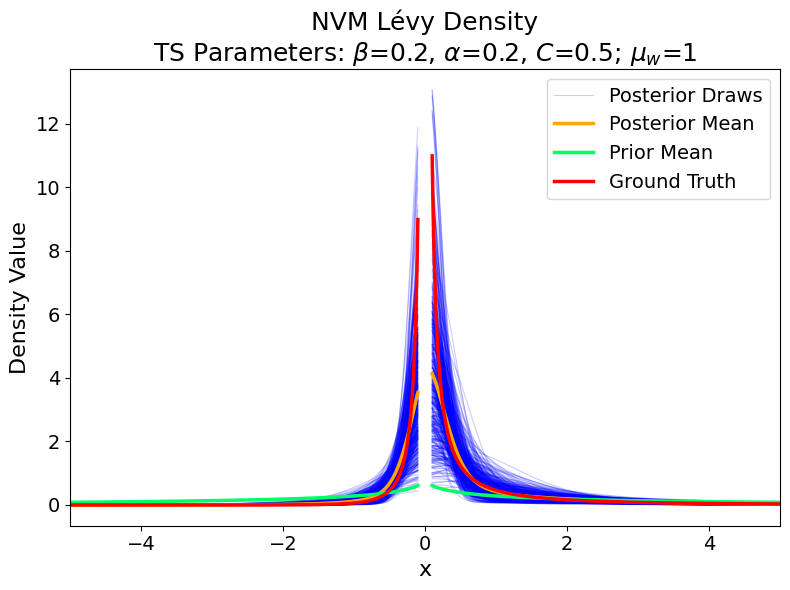


========== mu_w posterior diagnostics ==========
Mean of muw posterior means: 0.7465303959826737
sample_muw_means shape: (300001,)
sample_muw_covariances shape: (300001,)


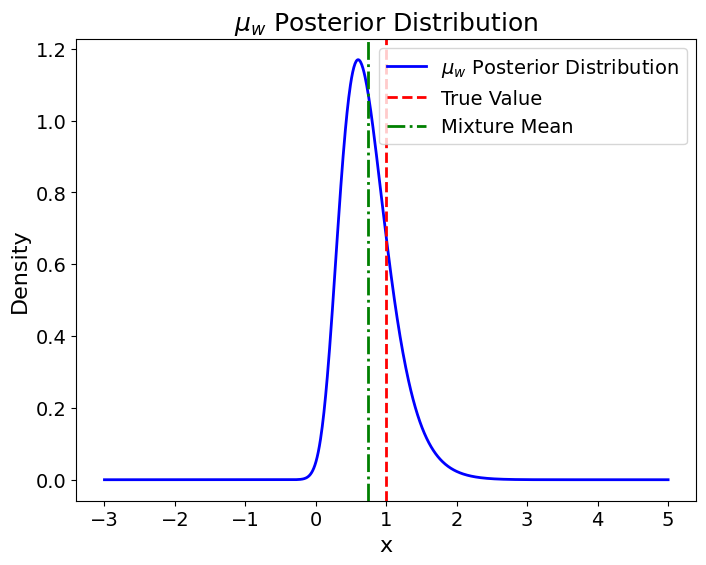


========== Projection input diagnostics ==========
observation_noise_level: 0.1
sigmav2: 0.010000000000000002
Observed increment noise variance should be approximately 2 * sigmav2: 0.020000000000000004
T: 10.0
increments shape: (99,)

Positive noisy increments:
count: 49
min/max: 0.007344362985439723 4.4602060205168215

Negative absolute noisy increments:
count: 50
min/max: 0.005180278409859795 0.7820871382676247

Projection support: (1e-05, 5.0)
Common density/TVD lower threshold: 0.1
divide_counts_by_T: True

========== Comparison range ==========
posterior range: (1e-05, 5.000000000000001)
projection support: (1e-05, 5.0)
comparison range: (0.1, 5.0)


Shared-resolution TVD search, p=2: 100%|██████████| 80/80 [00:00<00:00, 1929.99it/s]


========== Shared-resolution TVD-selected projection resolutions ==========
p=0 Lebesgue:
  shared bins: 54
  positive TVD: 0.8813110779701532
  negative TVD: 0.9448076563543287
  combined TVD: 1.8261187343244818

p=2 Regularized:
  shared bins: 14
  positive TVD: 0.5859357363660722
  negative TVD: 0.5035444514772257
  combined TVD: 1.0894801878432978


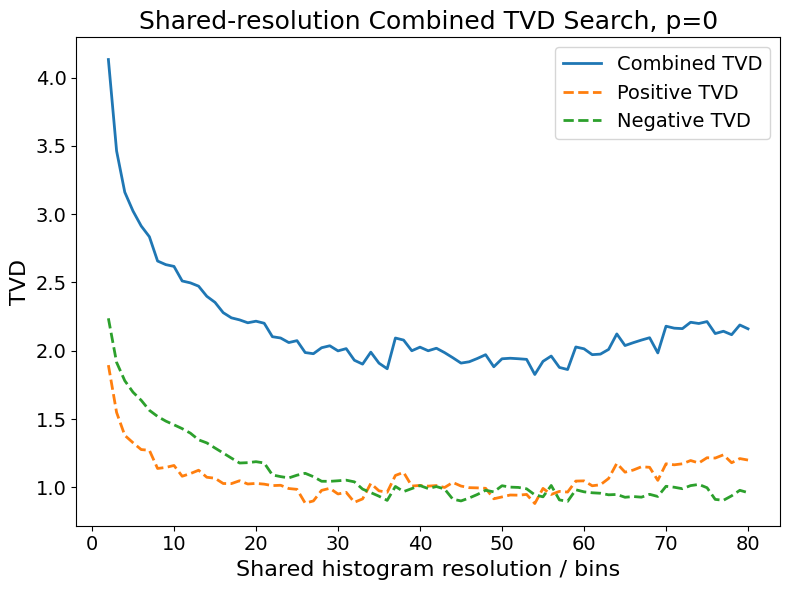

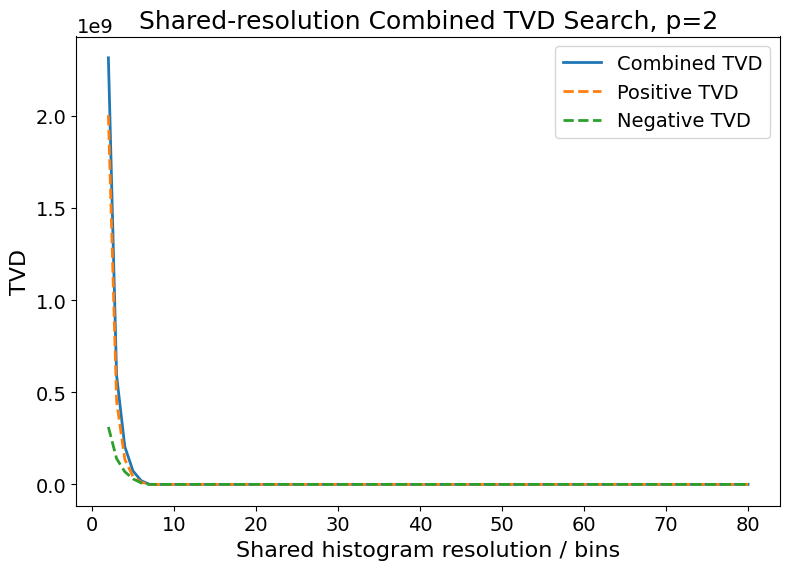

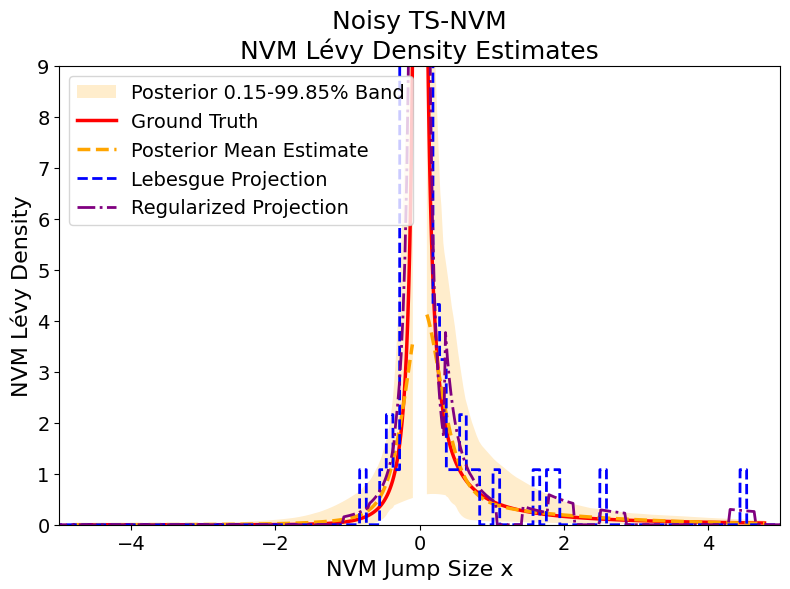

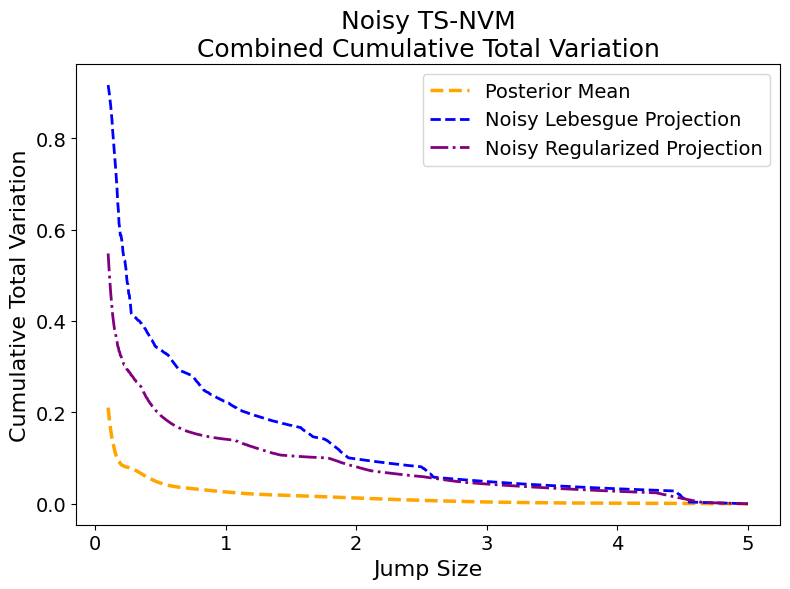

In [1]:
# ============================================================
# NVM TS process with Gaussian observation noise:
# Posterior / Prior / Ground Truth density
# + Projection density estimates
# + Overlay plots
# + Cumulative TVD comparison
#
# Unified full block.
#
# Main conventions:
#   - NVM density axis covers [-5, 5].
#   - Projection estimates are also constructed on |x| in [1e-5, 5].
#   - Posterior mean is computed from ALL posterior samples.
#   - Posterior credible band is computed from selected posterior density draws.
#   - Prior mean is computed from ALL prior samples.
#   - Prior credible band is computed from selected prior density draws.
#   - Density overlay plots truncate all curves and bands at the same lower |x|.
#   - Density overlay plots use xlim [-5, 5] and capped ylim [0, 8].
#   - Projection hyperparameters are selected by combined TVD.
# ============================================================

# ============================================================
# Imports
# ============================================================

factor = 1

import numpy as np
from scipy.linalg import expm
import math
import seaborn as sns
from scipy.special import logsumexp
from scipy.integrate import quad
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm

from posteriors import *
from Common_Tools import *
from Levy_Generators import *
from Levy_State_Space import *
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import *
from ground_truths import *
from mcmc_sampler_sigmaw2_conditional import *


# ============================================================
# Top-level hyperparameters / settings
# ============================================================

# ----------------------------
# Files
# ----------------------------
simulation_file = "TS_driven_NVM.npz"
posterior_file = "noisy_nvm_direct_observations_sigmaw2_conditional.npz"

# ----------------------------
# Posterior sample processing
# ----------------------------
additional_burn_in = 0
num_samples_in_plot = 500

# ----------------------------
# Posterior / prior credible bands
# ----------------------------
lower_percentage = 0.15
upper_percentage = 99.85

# ----------------------------
# NVM density axis
# ----------------------------
density_axis_epsilon = 1e-5
nvm_density_x_max = 5.0
nvm_axis_num_per_side = 300

# ----------------------------
# Ground truth quadrature
# ----------------------------
ground_truth_z_min = density_axis_epsilon * 1e-2 / factor
ground_truth_quad_epsabs = 1e-8
ground_truth_quad_epsrel = 1e-6
ground_truth_quad_limit = 200

# ----------------------------
# Realization-based density plots
# ----------------------------
density_realization_truncation_threshold = 0.1
density_plot_y_cap = 9.0

# ----------------------------
# Noisy projection comparison
# ----------------------------
observation_noise_level = 1e-1

projection_epsilon = 1e-5
projection_x_min = projection_epsilon
projection_x_max = 5.0

# Common lower |x| threshold for:
#   ground truth, posterior mean, posterior band, Lebesgue projection,
#   regularized projection in density overlay plots and TVD comparison.
density_plot_common_threshold = 0.1

# Shared-resolution search grids.
resolution_list_p0 = np.arange(1, 81)
resolution_list_p2 = np.arange(1, 81)

divide_counts_by_T = True

search_n_common = 1000
cumulative_n_common = 1000

show_resolution_search_plots = True

# ----------------------------
# Plot style
# ----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


# ============================================================
# Helper functions: NVM posterior / prior density
# ============================================================

def gaussian_mixture_density_fast(
    rates,
    positions,
    x_axis,
    muw_mu,
    muw_sigma2,
    sigmaw2,
):
    """
    Fast NVM Gaussian mixture density:

        rho_J(x)
        = sum_i rates_i * N(
            x ; muw_mu * z_i,
                muw_sigma2 * z_i^2 + sigmaw2 * z_i
          ).
    """
    rates = np.asarray(rates, dtype=float)
    positions = np.asarray(positions, dtype=float)
    x_axis = np.asarray(x_axis, dtype=float)

    valid = (
        np.isfinite(rates)
        & np.isfinite(positions)
        & (rates > 0)
        & (positions > 0)
    )

    rates = rates[valid]
    positions = positions[valid]

    if len(rates) == 0:
        return np.zeros_like(x_axis, dtype=float)

    means = muw_mu * positions
    variances = muw_sigma2 * positions**2 + sigmaw2 * positions
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    z = (x_axis[None, :] - means[:, None]) / stds[:, None]
    coef = rates[:, None] / (stds[:, None] * np.sqrt(2.0 * np.pi))

    return np.sum(coef * np.exp(-0.5 * z**2), axis=0)


def nvm_ts_density_integrand(z, x, muw, sigmaw, alpha, beta, C):
    """
    Integrand for the NVM Lévy density induced by a TS subordinator:

        N(x; muw*z, sigmaw^2*z) * C z^{-1-alpha} exp(-beta z).
    """
    if z <= 0:
        return 0.0

    var = sigmaw**2 * z
    if var <= 0:
        return 0.0

    std = np.sqrt(var)
    normal_pdf = np.exp(-0.5 * ((x - muw * z) / std) ** 2) / (
        std * np.sqrt(2.0 * np.pi)
    )

    rho_z = C * z ** (-1.0 - alpha) * np.exp(-beta * z)

    return normal_pdf * rho_z


def NVM_ground_truth_density_by_quad_strict(
    x_axis,
    muw,
    sigmaw,
    alpha,
    beta,
    C,
    z_min,
    epsabs=1e-8,
    epsrel=1e-6,
    limit=200,
):
    """
    Strict deterministic quadrature for the NVM Lévy density:

        rho_J(x)
        = int_{z_min}^{infty}
              N(x; muw*z, sigmaw^2*z)
              C z^{-1-alpha} exp(-beta z)
          dz.
    """
    x_axis = np.asarray(x_axis, dtype=float)
    out = np.zeros_like(x_axis, dtype=float)

    for j, x in enumerate(tqdm(x_axis, desc="Ground truth density quadrature")):
        val, err = quad(
            nvm_ts_density_integrand,
            z_min,
            np.inf,
            args=(x, muw, sigmaw, alpha, beta, C),
            epsabs=epsabs,
            epsrel=epsrel,
            limit=limit,
        )
        out[j] = val

    return out


# ============================================================
# Helper functions: projection estimates and TVD
# ============================================================

def regularized_projection_estimate_fixed_support(
    data,
    counts,
    resolution,
    regularized_power=0,
    x_min=1e-5,
    x_max=5.0,
):
    """
    Fixed-support projection estimator.

    data:
        positive absolute increments.

    counts:
        same shape as data. Should already include 1/T if estimating
        Lévy density per unit time.

    p=0:
        estimates rho(x).

    p=2:
        estimates x^2 rho(x), then restores by multiplying x^{-2}.
    """
    data = np.asarray(data, dtype=float).reshape(-1)
    counts = np.asarray(counts, dtype=float).reshape(-1)

    valid = (
        np.isfinite(data)
        & np.isfinite(counts)
        & (data > 0)
        & (counts > 0)
        & (data >= x_min)
        & (data <= x_max)
    )

    data = data[valid]
    counts = counts[valid]

    resolution = int(resolution)

    hist_axis = np.linspace(x_min, x_max, resolution + 1)
    bin_width = hist_axis[1] - hist_axis[0]
    bin_centers = 0.5 * (hist_axis[:-1] + hist_axis[1:])

    hist_counts = np.zeros(len(hist_axis) - 1, dtype=float)

    if len(data) > 0:
        data_sorted_indices = np.argsort(data)
        data = data[data_sorted_indices]
        counts = counts[data_sorted_indices]

        data_pointer = 0
        axis_pointer = 0

        while data_pointer < len(data) and axis_pointer < len(hist_axis) - 1:
            if data[data_pointer] <= hist_axis[axis_pointer + 1]:
                hist_counts[axis_pointer] += (
                    counts[data_pointer]
                    * (data[data_pointer] ** regularized_power)
                    / bin_width
                )
                data_pointer += 1
            else:
                axis_pointer += 1

    results = np.zeros(resolution * len(bin_centers))
    x_axis = np.linspace(x_min, x_max, len(results))

    for i in range(len(bin_centers)):
        start = i * resolution
        end = min((i + 1) * resolution, len(results))
        results[start:end] = hist_counts[i]

    if regularized_power != 0:
        results = results * np.maximum(x_axis, 1e-300) ** (-regularized_power)

    return x_axis, results


def interp_positive_axis_linear_y(x_src, y_src, x_tgt):
    """
    Positive-axis interpolation on |x| using linear x and linear y.
    """
    x_src = np.asarray(x_src, dtype=float).reshape(-1)
    y_src = np.asarray(y_src, dtype=float).reshape(-1)
    x_tgt = np.asarray(x_tgt, dtype=float).reshape(-1)

    valid = np.isfinite(x_src) & np.isfinite(y_src) & (x_src >= 0)

    x_src = x_src[valid]
    y_src = y_src[valid]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    x_unique, idx = np.unique(x_src, return_index=True)
    x_src = x_unique
    y_src = y_src[idx]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    return np.interp(x_tgt, x_src, y_src, left=np.nan, right=np.nan)


def tvd_one_side(est_axis, est_density, gt_axis, gt_density, x_min, x_max, n_common=1000):
    """
    One-sided total-variation style error:

        0.5 * int |rho_hat - rho| dx.
    """
    grid = np.linspace(x_min, x_max, n_common)

    est_on_grid = interp_positive_axis_linear_y(est_axis, est_density, grid)
    gt_on_grid = interp_positive_axis_linear_y(gt_axis, gt_density, grid)

    mask = np.isfinite(est_on_grid) & np.isfinite(gt_on_grid)

    if np.sum(mask) < 5:
        return np.inf

    x = grid[mask]
    local_error = 0.5 * np.abs(est_on_grid[mask] - gt_on_grid[mask])

    return np.trapezoid(local_error, x)


def build_shared_resolution_records(
    positive_increments,
    positive_counts,
    negative_increments,
    negative_counts,
    resolution_list,
    regularized_power,
    x_min,
    x_max,
    gt_positive_axis_abs,
    gt_positive_density,
    gt_negative_axis_abs,
    gt_negative_density,
    tvd_x_min,
    n_common=1000,
):
    """
    Search over one shared resolution for positive and negative sides.
    """
    records = []
    best = None

    for resolution in tqdm(
        resolution_list,
        desc=f"Shared-resolution TVD search, p={regularized_power}",
    ):
        resolution = int(resolution)

        pos_axis, pos_density = regularized_projection_estimate_fixed_support(
            data=positive_increments,
            counts=positive_counts,
            resolution=resolution,
            regularized_power=regularized_power,
            x_min=x_min,
            x_max=x_max,
        )

        neg_axis, neg_density = regularized_projection_estimate_fixed_support(
            data=negative_increments,
            counts=negative_counts,
            resolution=resolution,
            regularized_power=regularized_power,
            x_min=x_min,
            x_max=x_max,
        )

        pos_tvd = tvd_one_side(
            est_axis=pos_axis,
            est_density=pos_density,
            gt_axis=gt_positive_axis_abs,
            gt_density=gt_positive_density,
            x_min=tvd_x_min,
            x_max=x_max,
            n_common=n_common,
        )

        neg_tvd = tvd_one_side(
            est_axis=neg_axis,
            est_density=neg_density,
            gt_axis=gt_negative_axis_abs,
            gt_density=gt_negative_density,
            x_min=tvd_x_min,
            x_max=x_max,
            n_common=n_common,
        )

        combined_tvd = pos_tvd + neg_tvd

        record = {
            "resolution": resolution,
            "regularized_power": int(regularized_power),
            "positive_tvd": float(pos_tvd),
            "negative_tvd": float(neg_tvd),
            "combined_tvd": float(combined_tvd),
            "positive_axis": np.asarray(pos_axis, dtype=float),
            "positive_density": np.asarray(pos_density, dtype=float),
            "negative_axis": np.asarray(neg_axis, dtype=float),
            "negative_density": np.asarray(neg_density, dtype=float),
            "tvd_x_min": float(tvd_x_min),
            "x_max": float(x_max),
        }

        records.append(record)

        if best is None or combined_tvd < best["combined_tvd"]:
            best = record

    return best, records


def plot_shared_resolution_search(records, title):
    resolutions = np.array([r["resolution"] for r in records], dtype=float)
    combined = np.array([r["combined_tvd"] for r in records], dtype=float)
    positive = np.array([r["positive_tvd"] for r in records], dtype=float)
    negative = np.array([r["negative_tvd"] for r in records], dtype=float)

    plt.figure(figsize=(8, 6))
    plt.plot(resolutions, combined, linewidth=2, label="Combined TVD")
    plt.plot(resolutions, positive, linewidth=2, linestyle="--", label="Positive TVD")
    plt.plot(resolutions, negative, linewidth=2, linestyle="--", label="Negative TVD")
    plt.xlabel("Shared histogram resolution / bins")
    plt.ylabel("TVD")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def cumulative_tv_small_to_large(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[1:] = np.cumsum(increments)

    return out


def cumulative_tv_large_to_small(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[:-1] = np.cumsum(increments[::-1])[::-1]

    return out


def evaluate_side_for_cumulative_tv(
    posterior_axis_signed,
    posterior_density,
    gt_density_on_posterior_axis,
    projection_axis_leb,
    projection_density_leb,
    projection_axis_reg,
    projection_density_reg,
    x_min,
    x_max,
    n_common=1000,
):
    x_post = np.abs(np.asarray(posterior_axis_signed, dtype=float).reshape(-1))
    y_post = np.asarray(posterior_density, dtype=float).reshape(-1)
    y_gt = np.asarray(gt_density_on_posterior_axis, dtype=float).reshape(-1)

    x_leb = np.asarray(projection_axis_leb, dtype=float).reshape(-1)
    y_leb = np.asarray(projection_density_leb, dtype=float).reshape(-1)

    x_reg = np.asarray(projection_axis_reg, dtype=float).reshape(-1)
    y_reg = np.asarray(projection_density_reg, dtype=float).reshape(-1)

    grid = np.linspace(x_min, x_max, n_common)

    gt_on_grid = interp_positive_axis_linear_y(x_post, y_gt, grid)
    post_on_grid = interp_positive_axis_linear_y(x_post, y_post, grid)
    leb_on_grid = interp_positive_axis_linear_y(x_leb, y_leb, grid)
    reg_on_grid = interp_positive_axis_linear_y(x_reg, y_reg, grid)

    mask = (
        np.isfinite(gt_on_grid)
        & np.isfinite(post_on_grid)
        & np.isfinite(leb_on_grid)
        & np.isfinite(reg_on_grid)
    )

    return {
        "x": grid[mask],
        "gt": gt_on_grid[mask],
        "post": post_on_grid[mask],
        "leb": leb_on_grid[mask],
        "reg": reg_on_grid[mask],
    }


def combine_pos_neg_cumulative_tv(pos_eval, neg_eval, direction="small_to_large"):
    x_all = np.concatenate([pos_eval["x"], neg_eval["x"]])

    gt_all = np.concatenate([pos_eval["gt"], neg_eval["gt"]])
    post_all = np.concatenate([pos_eval["post"], neg_eval["post"]])
    leb_all = np.concatenate([pos_eval["leb"], neg_eval["leb"]])
    reg_all = np.concatenate([pos_eval["reg"], neg_eval["reg"]])

    order = np.argsort(x_all)

    x_sorted = x_all[order]
    gt_sorted = gt_all[order]
    post_sorted = post_all[order]
    leb_sorted = leb_all[order]
    reg_sorted = reg_all[order]

    if direction == "small_to_large":
        return {
            "x": x_sorted,
            "post": cumulative_tv_small_to_large(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_small_to_large(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_small_to_large(x_sorted, reg_sorted, gt_sorted),
        }

    if direction == "large_to_small":
        return {
            "x": x_sorted,
            "post": cumulative_tv_large_to_small(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_large_to_small(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_large_to_small(x_sorted, reg_sorted, gt_sorted),
        }

    raise ValueError("direction must be 'small_to_large' or 'large_to_small'.")


# ============================================================
# Load simulation data
# ============================================================

sim_data = np.load(simulation_file)

sigmaw = float(sim_data["sigmaw"])
sigmaw2 = sigmaw ** 2
beta = float(sim_data["beta"])
alpha = float(sim_data["alpha"])
C = float(sim_data["C"])
muw = float(sim_data["muw"])
T = float(sim_data["T"])
sim_rate = float(sim_data["sim_rate"])

time_axis = sim_data["time_axis"]
jump_times = sim_data["jump_times"]
nvm_jump_sizes = sim_data["nvm_jump_sizes"]

print("========== Simulation parameters ==========")
print("beta:", beta)
print("alpha:", alpha)
print("C:", C)
print("muw:", muw)
print("sigmaw:", sigmaw)
print("sigmaw2:", sigmaw2)
print("T:", T)
print("sim_rate:", sim_rate)


# ============================================================
# Construct common NVM density axis [-5, 5]
# ============================================================

nvm_positive_axis = np.logspace(
    np.log10(density_axis_epsilon),
    np.log10(nvm_density_x_max),
    nvm_axis_num_per_side,
)

nvm_negative_axis = np.logspace(
    np.log10(density_axis_epsilon),
    np.log10(nvm_density_x_max),
    nvm_axis_num_per_side,
)

nvm_axis = np.concatenate(
    [
        -nvm_negative_axis[::-1],
        nvm_positive_axis,
    ]
)


# ============================================================
# Load posterior samples
# ============================================================

post_data = np.load(posterior_file)

sample_measures_raw = post_data["sample_measures"][additional_burn_in:].copy()
sample_rates = post_data["sample_rates"][additional_burn_in:].copy()
sample_x_means = post_data["sample_x_means"][additional_burn_in:].copy()
sample_x_covariances = post_data["sample_x_covariances"][additional_burn_in:].copy()

S = len(sample_measures_raw)

print("\n========== Posterior sample diagnostics ==========")
print("Number of posterior samples:", S)
print("sample_measures_raw shape:", sample_measures_raw.shape)
print("sample_rates shape:", sample_rates.shape)
print("sample_x_means shape:", sample_x_means.shape)
print("sample_x_covariances shape:", sample_x_covariances.shape)


# ============================================================
# Prior definition and samples
# ============================================================

rate_alpha_prior = 3
rate_beta_prior = 1

dir_K = 1000

initial_dir_alpha = 10.0
initial_base_gamma_a = 1.0
initial_base_gamma_b = 2.0

dir_alpha_a = 1.0
dir_alpha_b = 3.0

muw_mean = 0.0
muw_variance = 10.0

prior_num_samples = 1000

prior_sample_measures_raw, prior_sample_rates = draw_IGSDP_Prior_Measures(
    rate_alpha_prior,
    rate_beta_prior,
    initial_base_gamma_a,
    1 / initial_base_gamma_b,
    dir_alpha_a,
    1 / dir_alpha_b,
    dir_K,
    num_samples=prior_num_samples,
)

prior_sample_measures_raw = prior_sample_measures_raw.copy()
prior_sample_rates = np.asarray(prior_sample_rates).copy()

P = len(prior_sample_measures_raw)

print("\n========== Prior sample diagnostics ==========")
print("Number of prior samples:", P)


# ============================================================
# Select posterior / prior density draws for plots and bands
# ============================================================

rng = np.random.default_rng(123)

num_posterior_density_draws = min(num_samples_in_plot, S)
num_prior_density_draws = min(num_samples_in_plot, P)

posterior_density_indices = rng.choice(
    S,
    size=num_posterior_density_draws,
    replace=False,
)

prior_density_indices = rng.choice(
    P,
    size=num_prior_density_draws,
    replace=False,
)

posterior_density_index_set = set(posterior_density_indices.tolist())
prior_density_index_set = set(prior_density_indices.tolist())


# ============================================================
# Posterior density processing
# Mean uses ALL posterior draws.
# Band uses selected posterior density draws.
# ============================================================

posterior_density_sum = np.zeros_like(nvm_axis, dtype=float)
posterior_density_draws = []

for i in tqdm(range(S), desc="Posterior density analysis"):
    sample_measure = sample_measures_raw[i].copy()
    sample_rate = sample_rates[i]

    # Convert DP probability measure into Lévy measure.
    sample_measure[0, :] = sample_measure[0, :] * sample_rate

    rates_i = sample_measure[0, :]
    positions_i = sample_measure[1, :]

    x_mean_sample_series = sample_x_means[i]
    x_covariance_sample_series = sample_x_covariances[i]

    muw_posterior_mean = x_mean_sample_series[-1, -1, 0]
    muw_posterior_variance = x_covariance_sample_series[-1, -1, -1]

    density_i = gaussian_mixture_density_fast(
        rates_i,
        positions_i,
        nvm_axis,
        muw_posterior_mean,
        muw_posterior_variance,
        sigmaw2,
    )

    posterior_density_sum += density_i

    if i in posterior_density_index_set:
        posterior_density_draws.append(density_i)

NVM_density_inferred = posterior_density_sum / S
posterior_density_draws = np.vstack(posterior_density_draws)

nvm_density_lower_quantile = np.percentile(
    posterior_density_draws,
    lower_percentage,
    axis=0,
)

nvm_density_upper_quantile = np.percentile(
    posterior_density_draws,
    upper_percentage,
    axis=0,
)

print("\n========== Posterior density diagnostics ==========")
print("posterior_density_draws shape:", posterior_density_draws.shape)
print("nvm_density_lower_quantile shape:", nvm_density_lower_quantile.shape)
print("nvm_density_upper_quantile shape:", nvm_density_upper_quantile.shape)


# ============================================================
# Prior density processing
# Mean uses ALL prior draws.
# Band uses selected prior density draws.
# ============================================================

prior_density_sum = np.zeros_like(nvm_axis, dtype=float)
prior_density_draws = []

for i in tqdm(range(P), desc="Prior density analysis"):
    prior_measure = prior_sample_measures_raw[i].copy()
    prior_rate = prior_sample_rates[i]

    prior_measure[0, :] = prior_measure[0, :] * prior_rate

    prior_rates_i = prior_measure[0, :]
    prior_positions_i = prior_measure[1, :]

    prior_density_i = gaussian_mixture_density_fast(
        prior_rates_i,
        prior_positions_i,
        nvm_axis,
        muw_mean,
        muw_variance,
        sigmaw2,
    )

    prior_density_sum += prior_density_i

    if i in prior_density_index_set:
        prior_density_draws.append(prior_density_i)

prior_NVM_density_inferred = prior_density_sum / P
prior_density_draws = np.vstack(prior_density_draws)

prior_nvm_density_lower_quantile = np.percentile(
    prior_density_draws,
    lower_percentage,
    axis=0,
)

prior_nvm_density_upper_quantile = np.percentile(
    prior_density_draws,
    upper_percentage,
    axis=0,
)

print("\n========== Prior density diagnostics ==========")
print("prior_density_draws shape:", prior_density_draws.shape)
print("prior_nvm_density_lower_quantile shape:", prior_nvm_density_lower_quantile.shape)
print("prior_nvm_density_upper_quantile shape:", prior_nvm_density_upper_quantile.shape)


# ============================================================
# Strict ground truth density on common axis [-5, 5]
# ============================================================

NVM_density_ground_truth = NVM_ground_truth_density_by_quad_strict(
    nvm_axis,
    muw=muw * factor,
    sigmaw=sigmaw * np.sqrt(factor),
    alpha=alpha,
    beta=beta * factor,
    C=C / (factor**alpha),
    z_min=ground_truth_z_min,
    epsabs=ground_truth_quad_epsabs,
    epsrel=ground_truth_quad_epsrel,
    limit=ground_truth_quad_limit,
)


# ============================================================
# Save original arrays for downstream use
# ============================================================

original_nvm_axis = nvm_axis

original_NVM_density_inferred = NVM_density_inferred
original_prior_NVM_density_inferred = prior_NVM_density_inferred
original_NVM_density_ground_truth = NVM_density_ground_truth

original_nvm_density_lower_quantile = nvm_density_lower_quantile
original_nvm_density_upper_quantile = nvm_density_upper_quantile

original_prior_nvm_density_lower_quantile = prior_nvm_density_lower_quantile
original_prior_nvm_density_upper_quantile = prior_nvm_density_upper_quantile

# Selected draws, not all draws.
NVM_density_array = posterior_density_draws
prior_NVM_density_array = prior_density_draws


# ============================================================
# Realization-based density plots
# ============================================================

density_title = (
    f"NVM Lévy Density\n"
    f"TS Parameters: "
    f"$\\beta$={beta * factor:.2g}, "
    f"$\\alpha$={alpha:.2g}, "
    f"$C$={C / (factor**alpha):.2g}; "
    f"$\\mu_w$={muw * factor:.2g}"
)

eps = density_realization_truncation_threshold

density_negative_mask = original_nvm_axis <= -eps
density_positive_mask = original_nvm_axis >= eps

density_negative_axis = original_nvm_axis[density_negative_mask]
density_positive_axis = original_nvm_axis[density_positive_mask]

posterior_density_negative_array = NVM_density_array[:, density_negative_mask]
posterior_density_positive_array = NVM_density_array[:, density_positive_mask]

prior_density_negative_array = prior_NVM_density_array[:, density_negative_mask]
prior_density_positive_array = prior_NVM_density_array[:, density_positive_mask]

posterior_density_mean_negative = original_NVM_density_inferred[density_negative_mask]
posterior_density_mean_positive = original_NVM_density_inferred[density_positive_mask]

prior_density_mean_negative = original_prior_NVM_density_inferred[density_negative_mask]
prior_density_mean_positive = original_prior_NVM_density_inferred[density_positive_mask]

posterior_density_lower_negative = original_nvm_density_lower_quantile[density_negative_mask]
posterior_density_upper_negative = original_nvm_density_upper_quantile[density_negative_mask]

posterior_density_lower_positive = original_nvm_density_lower_quantile[density_positive_mask]
posterior_density_upper_positive = original_nvm_density_upper_quantile[density_positive_mask]

prior_density_lower_negative = original_prior_nvm_density_lower_quantile[density_negative_mask]
prior_density_upper_negative = original_prior_nvm_density_upper_quantile[density_negative_mask]

prior_density_lower_positive = original_prior_nvm_density_lower_quantile[density_positive_mask]
prior_density_upper_positive = original_prior_nvm_density_upper_quantile[density_positive_mask]

ground_truth_density_negative = original_NVM_density_ground_truth[density_negative_mask]
ground_truth_density_positive = original_NVM_density_ground_truth[density_positive_mask]


# Plot 1: Posterior draws + posterior mean + prior mean + ground truth
plt.figure(figsize=(8, 6))

for j in range(posterior_density_negative_array.shape[0]):
    plt.plot(
        density_negative_axis,
        posterior_density_negative_array[j],
        color="blue",
        alpha=0.2,
        linewidth=0.8,
        label="Posterior Draws" if j == 0 else None,
    )

for j in range(posterior_density_positive_array.shape[0]):
    plt.plot(
        density_positive_axis,
        posterior_density_positive_array[j],
        color="blue",
        alpha=0.2,
        linewidth=0.8,
    )

plt.plot(
    density_negative_axis,
    posterior_density_mean_negative,
    color="orange",
    linewidth=2.5,
    label="Posterior Mean",
)
plt.plot(
    density_positive_axis,
    posterior_density_mean_positive,
    color="orange",
    linewidth=2.5,
)

plt.plot(
    density_negative_axis,
    prior_density_mean_negative,
    color="#00FF66",
    linewidth=2.5,
    label="Prior Mean",
)
plt.plot(
    density_positive_axis,
    prior_density_mean_positive,
    color="#00FF66",
    linewidth=2.5,
)

plt.plot(
    density_negative_axis,
    ground_truth_density_negative,
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)
plt.plot(
    density_positive_axis,
    ground_truth_density_positive,
    color="red",
    linewidth=2.5,
)

plt.xlim(-nvm_density_x_max, nvm_density_x_max)
plt.title(density_title)
plt.xlabel("x")
plt.ylabel("Density Value")
plt.legend()
plt.tight_layout()
plt.show()





# ============================================================
# mu_w posterior plot
# ============================================================

sample_muw_means = sample_x_means[:, -1, -1, -1]
sample_muw_covariances = sample_x_covariances[:, -1, -1, -1]

print("\n========== mu_w posterior diagnostics ==========")
print("Mean of muw posterior means:", np.mean(sample_muw_means))
print("sample_muw_means shape:", np.shape(sample_muw_means))
print("sample_muw_covariances shape:", np.shape(sample_muw_covariances))

x = np.linspace(-3, 5, 1000)
weights = np.ones(len(sample_muw_covariances)) / len(sample_muw_covariances)

plot_mixture_of_gaussians(
    sample_muw_means,
    sample_muw_covariances,
    weights,
    x,
    muw * factor,
    r"$\mu_w$ Posterior Distribution",
    show_mixture_mean=True,
)


# ============================================================
# Projection estimates from noisy observations
# ============================================================

nvm_process_path = integrate_to_path(
    nvm_jump_sizes,
    jump_times,
    time_axis,
)

sigmav2 = observation_noise_level ** 2

observations = langevin_observations(
    nvm_process_path,
    sigmav2 * np.identity(1),
    H=np.ones((1, 1)),
    mu=np.zeros((1, 1)),
)

observations = np.asarray(observations)

if observations.ndim == 1:
    increments = np.diff(observations).reshape(-1)
else:
    increments = np.diff(observations[0, :]).reshape(-1)

positive_increments_all = increments[increments >= projection_epsilon]
negative_increments_all = -increments[increments <= -projection_epsilon]

if divide_counts_by_T:
    positive_counts = np.ones_like(positive_increments_all, dtype=float) / float(T)
    negative_counts = np.ones_like(negative_increments_all, dtype=float) / float(T)
else:
    positive_counts = np.ones_like(positive_increments_all, dtype=float)
    negative_counts = np.ones_like(negative_increments_all, dtype=float)

print("\n========== Projection input diagnostics ==========")
print("observation_noise_level:", observation_noise_level)
print("sigmav2:", sigmav2)
print("Observed increment noise variance should be approximately 2 * sigmav2:", 2.0 * sigmav2)
print("T:", float(T))
print("increments shape:", increments.shape)

print("\nPositive noisy increments:")
print("count:", len(positive_increments_all))
if len(positive_increments_all) > 0:
    print("min/max:", positive_increments_all.min(), positive_increments_all.max())

print("\nNegative absolute noisy increments:")
print("count:", len(negative_increments_all))
if len(negative_increments_all) > 0:
    print("min/max:", negative_increments_all.min(), negative_increments_all.max())

print("\nProjection support:", (projection_x_min, projection_x_max))
print("Common density/TVD lower threshold:", density_plot_common_threshold)
print("divide_counts_by_T:", divide_counts_by_T)


# ============================================================
# Prepare posterior / ground truth density sides for comparison
# ============================================================

post_neg_mask_full = original_nvm_axis < 0
post_pos_mask_full = original_nvm_axis > 0

posterior_negative_axis_full = original_nvm_axis[post_neg_mask_full]
posterior_positive_axis_full = original_nvm_axis[post_pos_mask_full]

posterior_density_negative_full = original_NVM_density_inferred[post_neg_mask_full]
posterior_density_positive_full = original_NVM_density_inferred[post_pos_mask_full]

ground_truth_density_negative_full = original_NVM_density_ground_truth[post_neg_mask_full]
ground_truth_density_positive_full = original_NVM_density_ground_truth[post_pos_mask_full]

posterior_density_band_lower_negative_full = original_nvm_density_lower_quantile[post_neg_mask_full]
posterior_density_band_upper_negative_full = original_nvm_density_upper_quantile[post_neg_mask_full]

posterior_density_band_lower_positive_full = original_nvm_density_lower_quantile[post_pos_mask_full]
posterior_density_band_upper_positive_full = original_nvm_density_upper_quantile[post_pos_mask_full]

posterior_abs_axis = np.abs(np.asarray(original_nvm_axis, dtype=float))
posterior_abs_axis = posterior_abs_axis[
    np.isfinite(posterior_abs_axis) & (posterior_abs_axis > 0)
]

posterior_min_abs_x = float(np.min(posterior_abs_axis))
posterior_max_abs_x = float(np.max(posterior_abs_axis))

comparison_x_min = max(
    density_plot_common_threshold,
    posterior_min_abs_x,
    projection_x_min,
)
comparison_x_max = min(
    projection_x_max,
    posterior_max_abs_x,
)

if comparison_x_max <= comparison_x_min:
    raise ValueError(
        f"No overlap between posterior inference range and projection support: "
        f"posterior=[{posterior_min_abs_x}, {posterior_max_abs_x}], "
        f"projection=[{projection_x_min}, {projection_x_max}], "
        f"threshold={density_plot_common_threshold}."
    )

print("\n========== Comparison range ==========")
print("posterior range:", (posterior_min_abs_x, posterior_max_abs_x))
print("projection support:", (projection_x_min, projection_x_max))
print("comparison range:", (comparison_x_min, comparison_x_max))


# ============================================================
# Ground-truth positive |x| axes for TVD search
# ============================================================

gt_positive_axis_abs = np.abs(posterior_positive_axis_full)
gt_negative_axis_abs = np.abs(posterior_negative_axis_full)

pos_order = np.argsort(gt_positive_axis_abs)
neg_order = np.argsort(gt_negative_axis_abs)

gt_positive_axis_abs_sorted = gt_positive_axis_abs[pos_order]
gt_positive_density_sorted = ground_truth_density_positive_full[pos_order]

gt_negative_axis_abs_sorted = gt_negative_axis_abs[neg_order]
gt_negative_density_sorted = ground_truth_density_negative_full[neg_order]


# ============================================================
# Shared-resolution TVD search
# ============================================================

best_p0, records_p0 = build_shared_resolution_records(
    positive_increments=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p0,
    regularized_power=0,
    x_min=projection_x_min,
    x_max=projection_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_x_min=comparison_x_min,
    n_common=search_n_common,
)

best_p2, records_p2 = build_shared_resolution_records(
    positive_increments=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p2,
    regularized_power=2,
    x_min=projection_x_min,
    x_max=projection_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_x_min=comparison_x_min,
    n_common=search_n_common,
)

print("\n========== Shared-resolution TVD-selected projection resolutions ==========")
print("p=0 Lebesgue:")
print("  shared bins:", best_p0["resolution"])
print("  positive TVD:", best_p0["positive_tvd"])
print("  negative TVD:", best_p0["negative_tvd"])
print("  combined TVD:", best_p0["combined_tvd"])

print("\np=2 Regularized:")
print("  shared bins:", best_p2["resolution"])
print("  positive TVD:", best_p2["positive_tvd"])
print("  negative TVD:", best_p2["negative_tvd"])
print("  combined TVD:", best_p2["combined_tvd"])

if show_resolution_search_plots:
    plot_shared_resolution_search(
        records_p0,
        "Shared-resolution Combined TVD Search, p=0",
    )

    plot_shared_resolution_search(
        records_p2,
        "Shared-resolution Combined TVD Search, p=2",
    )


# ============================================================
# Extract selected projection estimates
# ============================================================

positive_best_p0 = {
    "resolution": best_p0["resolution"],
    "axis": best_p0["positive_axis"],
    "density": best_p0["positive_density"],
    "tvd": best_p0["positive_tvd"],
}
negative_best_p0 = {
    "resolution": best_p0["resolution"],
    "axis": best_p0["negative_axis"],
    "density": best_p0["negative_density"],
    "tvd": best_p0["negative_tvd"],
}

positive_best_p2 = {
    "resolution": best_p2["resolution"],
    "axis": best_p2["positive_axis"],
    "density": best_p2["positive_density"],
    "tvd": best_p2["positive_tvd"],
}
negative_best_p2 = {
    "resolution": best_p2["resolution"],
    "axis": best_p2["negative_axis"],
    "density": best_p2["negative_density"],
    "tvd": best_p2["negative_tvd"],
}


# ============================================================
# Plot masks
# All density overlay elements use the SAME common lower threshold.
# ============================================================

ground_truth_neg_plot_mask = (
    (posterior_negative_axis_full <= -comparison_x_min)
    & (posterior_negative_axis_full >= -comparison_x_max)
)

ground_truth_pos_plot_mask = (
    (posterior_positive_axis_full >= comparison_x_min)
    & (posterior_positive_axis_full <= comparison_x_max)
)

posterior_mean_neg_plot_mask = ground_truth_neg_plot_mask.copy()
posterior_mean_pos_plot_mask = ground_truth_pos_plot_mask.copy()

posterior_band_neg_plot_mask = ground_truth_neg_plot_mask.copy()
posterior_band_pos_plot_mask = ground_truth_pos_plot_mask.copy()

neg_p0_mask = (
    (negative_best_p0["axis"] >= comparison_x_min)
    & (negative_best_p0["axis"] <= comparison_x_max)
)

pos_p0_mask = (
    (positive_best_p0["axis"] >= comparison_x_min)
    & (positive_best_p0["axis"] <= comparison_x_max)
)

neg_p2_mask = (
    (negative_best_p2["axis"] >= comparison_x_min)
    & (negative_best_p2["axis"] <= comparison_x_max)
)

pos_p2_mask = (
    (positive_best_p2["axis"] >= comparison_x_min)
    & (positive_best_p2["axis"] <= comparison_x_max)
)

# ============================================================
# Overlay plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.fill_between(
    posterior_negative_axis_full[posterior_band_neg_plot_mask],
    posterior_density_band_lower_negative_full[posterior_band_neg_plot_mask],
    posterior_density_band_upper_negative_full[posterior_band_neg_plot_mask],
    color="orange",
    alpha=0.2,
    linewidth=0,
    label=f"Posterior {lower_percentage:g}-{upper_percentage:g}% Band",
)
plt.fill_between(
    posterior_positive_axis_full[posterior_band_pos_plot_mask],
    posterior_density_band_lower_positive_full[posterior_band_pos_plot_mask],
    posterior_density_band_upper_positive_full[posterior_band_pos_plot_mask],
    color="orange",
    alpha=0.2,
    linewidth=0,
)

plt.plot(
    posterior_negative_axis_full[ground_truth_neg_plot_mask],
    ground_truth_density_negative_full[ground_truth_neg_plot_mask],
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)
plt.plot(
    posterior_positive_axis_full[ground_truth_pos_plot_mask],
    ground_truth_density_positive_full[ground_truth_pos_plot_mask],
    color="red",
    linewidth=2.5,
)

plt.plot(
    posterior_negative_axis_full[posterior_mean_neg_plot_mask],
    posterior_density_negative_full[posterior_mean_neg_plot_mask],
    color="orange",
    linewidth=2.5,
    linestyle="--",
    label="Posterior Mean Estimate",
)
plt.plot(
    posterior_positive_axis_full[posterior_mean_pos_plot_mask],
    posterior_density_positive_full[posterior_mean_pos_plot_mask],
    color="orange",
    linewidth=2.5,
    linestyle="--",
)

plt.plot(
    -negative_best_p0["axis"][neg_p0_mask],
    negative_best_p0["density"][neg_p0_mask],
    color="blue",
    linewidth=2,
    linestyle="--",
    label="Lebesgue Projection",
)
plt.plot(
    positive_best_p0["axis"][pos_p0_mask],
    positive_best_p0["density"][pos_p0_mask],
    color="blue",
    linewidth=2,
    linestyle="--",
)

plt.plot(
    -negative_best_p2["axis"][neg_p2_mask],
    negative_best_p2["density"][neg_p2_mask],
    color="purple",
    linewidth=2,
    linestyle="-.",
    label="Regularized Projection",
)
plt.plot(
    positive_best_p2["axis"][pos_p2_mask],
    positive_best_p2["density"][pos_p2_mask],
    color="purple",
    linewidth=2,
    linestyle="-.",
)

plt.xlim(-5, 5)
plt.ylim(0, density_plot_y_cap)
plt.xlabel("NVM Jump Size x")
plt.ylabel("NVM Lévy Density")
plt.title("Noisy TS-NVM\nNVM Lévy Density Estimates")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Cumulative TVD evaluation
# ============================================================

pos_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_positive_axis_full,
    posterior_density=posterior_density_positive_full,
    gt_density_on_posterior_axis=ground_truth_density_positive_full,
    projection_axis_leb=positive_best_p0["axis"],
    projection_density_leb=positive_best_p0["density"],
    projection_axis_reg=positive_best_p2["axis"],
    projection_density_reg=positive_best_p2["density"],
    x_min=comparison_x_min,
    x_max=comparison_x_max,
    n_common=cumulative_n_common,
)

neg_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_negative_axis_full,
    posterior_density=posterior_density_negative_full,
    gt_density_on_posterior_axis=ground_truth_density_negative_full,
    projection_axis_leb=negative_best_p0["axis"],
    projection_density_leb=negative_best_p0["density"],
    projection_axis_reg=negative_best_p2["axis"],
    projection_density_reg=negative_best_p2["density"],
    x_min=comparison_x_min,
    x_max=comparison_x_max,
    n_common=cumulative_n_common,
)

combined_tv_large_to_small = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="large_to_small",
)

combined_tv_small_to_large = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="small_to_large",
)


# ============================================================
# Plot cumulative TVD: large to small
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["post"],
    color="orange",
    linestyle="--",
    linewidth=2.5,
    label="Posterior Mean",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["leb"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Noisy Lebesgue Projection",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["reg"],
    color="purple",
    linestyle="-.",
    linewidth=2,
    label="Noisy Regularized Projection",
)

plt.xlabel("Jump Size")
plt.ylabel("Cumulative Total Variation")
plt.title("Noisy TS-NVM\nCombined Cumulative Total Variation")
plt.legend()
plt.tight_layout()
plt.show()



## Bimodal Subordinator Driven NVM Process Experiment

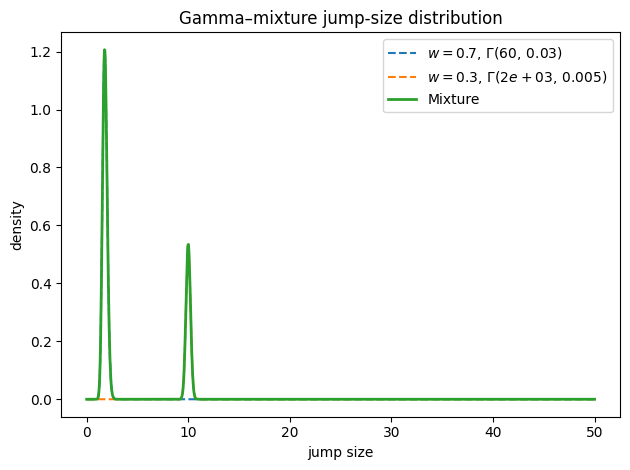

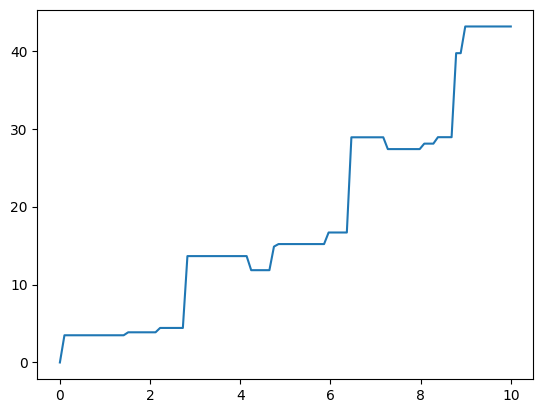

In [1]:
# ==== Deterministic + Stable RNG setup ====
import os
import random
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
from bimodal_experiments_sampler import *


shapes = [60,2000]
scales = [0.03,0.005]
weights = [0.7,0.3]
plot_gamma_mixture(shapes,scales,weights)
T = 10.0
time_axis = np.linspace(0,T,int(T)*10)
rate = 2.0

# ===== Load simulation data =====
data = np.load("bimodal_driven_NVM.npz")

shapes = data["shapes"]
scales = data["scales"]
weights = data["weights"]
T = float(data["T"])
time_axis = data["time_axis"]
rate = float(data["rate"])

sub_jump_sizes = data["sub_jump_sizes"]
jump_times = data["jump_times"]
process_path = data["process_path"]
muw = float(data["muw"]) #1.0
sigmaw = float(data["sigmaw"]) #1.0
sigmaw2 = float(data["sigmaw2"])
nvm_jump_sizes = data["nvm_jump_sizes"]

theta = float(data["theta"])
langevin_path = data["langevin_path"]
true_x = data["true_x"]
true_x_dot = data["true_x_dot"]


sigmaw2 = sigmaw ** 2
nvm_process_path = integrate_to_path(nvm_jump_sizes,jump_times,time_axis)


observation_noise_level = 1e-5
sigmav2 = observation_noise_level**2
observations = langevin_observations(nvm_process_path,(observation_noise_level**2)*np.identity(1),H=np.ones((1,1)),mu=np.zeros((1,1)))
plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()


In [ ]:
#Extended MCMC Algorithm with Hyper-parameter Sampling
#Inference Parameters
burn_in = 20000
num_iter = 170000  
block_width = 1
overlapping_width = 0
#Make a guess for sigmaw2
sigmaw2 = 1.0

#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition. Note that the Gamma base to DP here follows the shape-scale convention
initial_dir_alpha = 0.5
initial_base_gamma_a = 1
initial_base_gamma_b=3 #scale, not rate

#Shape-scale convention here.
dir_alpha_a = 0.5
dir_alpha_b = 0.5

base_gamma_a_mean = initial_base_gamma_a
base_gamma_a_std = 1000.0
base_gamma_b_mean = initial_base_gamma_b
base_gamma_b_std = 1000.0
base_gamma_a_step_size = 0.0
base_gamma_b_step_size = 0.0

#Defining the theta prior and the GRW proposal step size
theta_prior = theta * 1.0
theta_step_size = observation_noise_level * 0.1 #This is the factor applied to the standard deviation. Square it to apply it to the variance.

#Define the muw prior
prior_muw_mean = 0
prior_muw_variance = 10

#Random Initialization from the bimodal set
initial_jump_sizes,initial_jump_times = compound_poisson_gamma_mixture(rate,shapes,scales,weights,T)
grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
sample_measures,sample_rates,sample_paths,sample_x_means,sample_x_covariances,dir_alphas,base_gamma_as,base_gamma_bs = nvm_lm_theta_inference_all_DP_alpha_inferred_Gamma_base_Gaussian_update_conditional_sigmaw2(num_iter,block_width,overlapping_width,observations,time_axis,initial_jump_sizes,initial_jump_times,sigmav2,rate_alpha_prior,rate_beta_prior,dir_K,dir_alpha_a,dir_alpha_b,base_gamma_a_mean,base_gamma_a_std,base_gamma_b_mean,base_gamma_b_std,sigmaw2,base_gamma_a_step_size,base_gamma_b_step_size,dir_alpha=initial_dir_alpha,base_gamma_a=initial_base_gamma_a,base_gamma_b=initial_base_gamma_b,muw_prior_mean=prior_muw_mean,muw_prior_variance=prior_muw_variance)

#Discard the burn-in
sample_measures = sample_measures[burn_in:]
sample_rates = sample_rates[burn_in:]
sample_paths = sample_paths[burn_in:]
sample_x_means = sample_x_means[burn_in:]
sample_x_covariances = sample_x_covariances[burn_in:]


np.savez(
    "nvm_bimodal_subordinator_experiments.npz",
    sample_measures=sample_measures,
    sample_rates=sample_rates,
    sample_paths=sample_paths,
    sample_x_means=sample_x_means,
    sample_x_covariances=sample_x_covariances,
    dir_alphas = dir_alphas
    
)


Langevin System Inference Progress::   0%|          | 15/170000 [00:03<11:59:17,  3.94it/s]

Simulation parameters:
lambda_rate: 2.0
shapes: [  60. 2000.]
scales: [0.03  0.005]
weights: [0.7 0.3]
muw: 0.7
sigmaw: 1.0
sigmaw2: 1.0
Number of posterior samples: 150001
sample_measures_raw shape: (150001, 2, 1000)
sample_rates shape: (150001, 1)
sample_x_means shape: (150001, 100, 2, 1)
sample_x_covariances shape: (150001, 100, 2, 2)
Number of prior samples: 1000


Posterior density analysis: 100%|██████████| 150001/150001 [02:31<00:00, 993.03it/s] 


posterior_density_draws shape: (500, 200)


Prior density analysis: 100%|██████████| 1000/1000 [00:00<00:00, 5984.73it/s]


prior_density_draws shape: (500, 200)


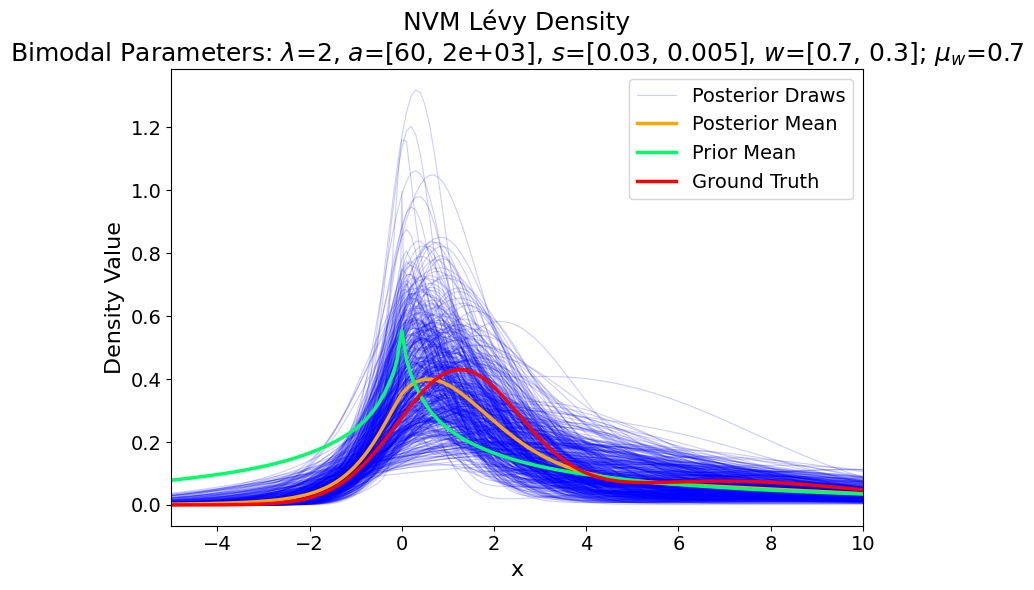

Mean of muw posterior means: 0.5787059459525451
sample_muw_means shape: (150001,)
sample_muw_covariances shape: (150001,)


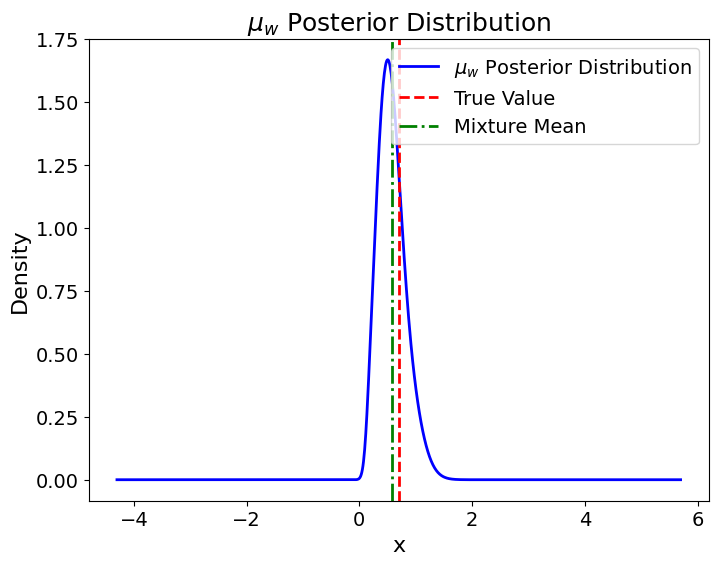

========== Projection input diagnostics ==========
observation_noise_level: 1e-05
T: 10.0
increments shape: (99,)

Positive increments:
count: 33
min/max: 1.1828619829401532e-05 12.218491011944408

Negative absolute increments:
count: 27
min/max: 1.031108540772152e-05 1.8064282708419555

Projection support:
positive: (1e-05, 10.0)
negative: (1e-05, 5.0)
Lebesgue TVD lower bound: 1e-05
Regularized TVD lower bound: 1e-05
divide_counts_by_T: True


Shared-resolution TVD search, p=2: 100%|██████████| 49/49 [00:00<00:00, 4479.43it/s]


========== Shared-resolution TVD-selected projection resolutions ==========
p=0 Lebesgue:
  shared bins: 3
  positive TVD: 0.7950311614167148
  negative TVD: 1.1134712242162184
  combined TVD: 1.908502385632933

p=2 Regularized:
  shared bins: 18
  positive TVD: 0.7036750155733545
  negative TVD: 0.19580432246092386
  combined TVD: 0.8994793380342784


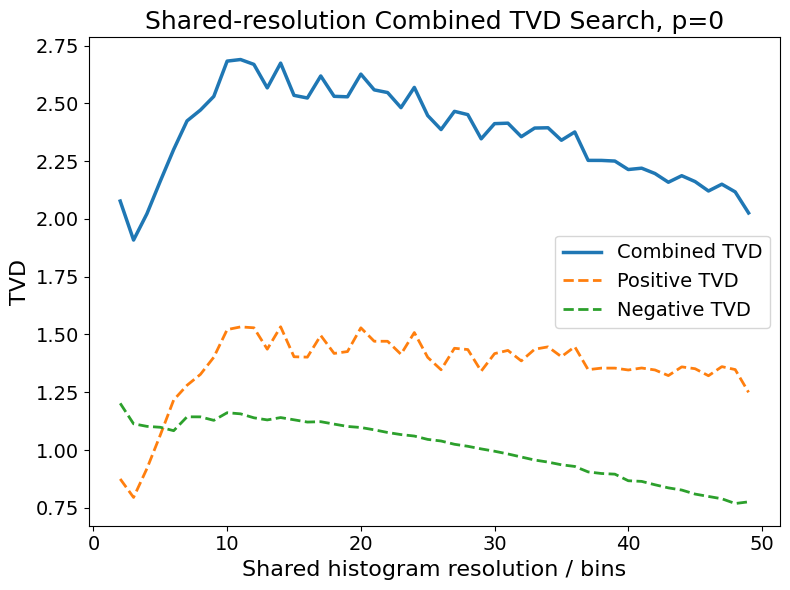

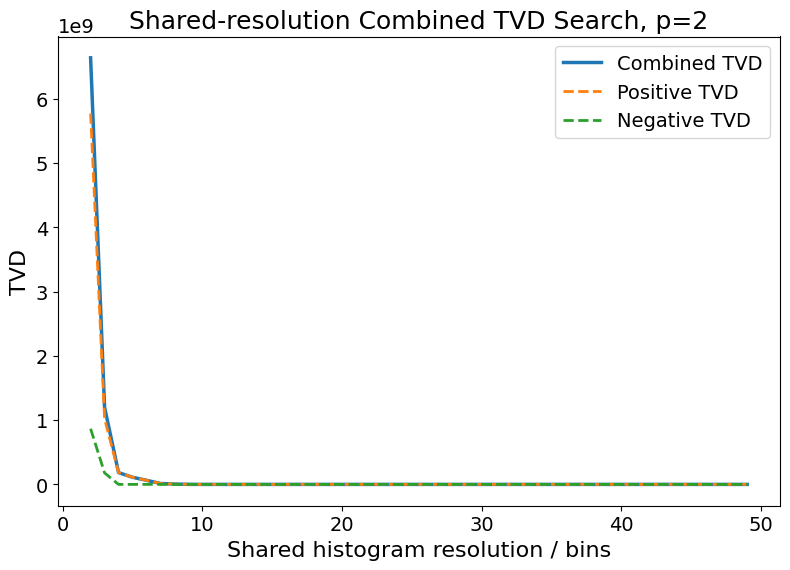

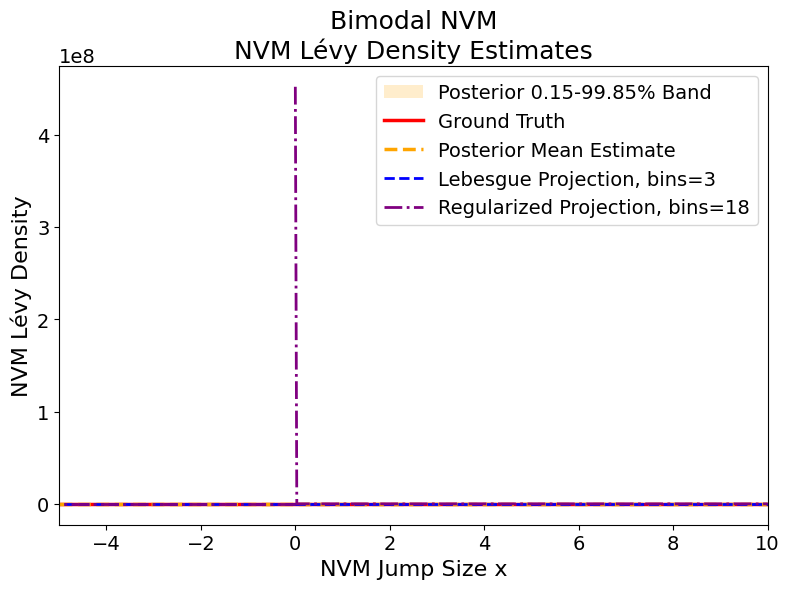

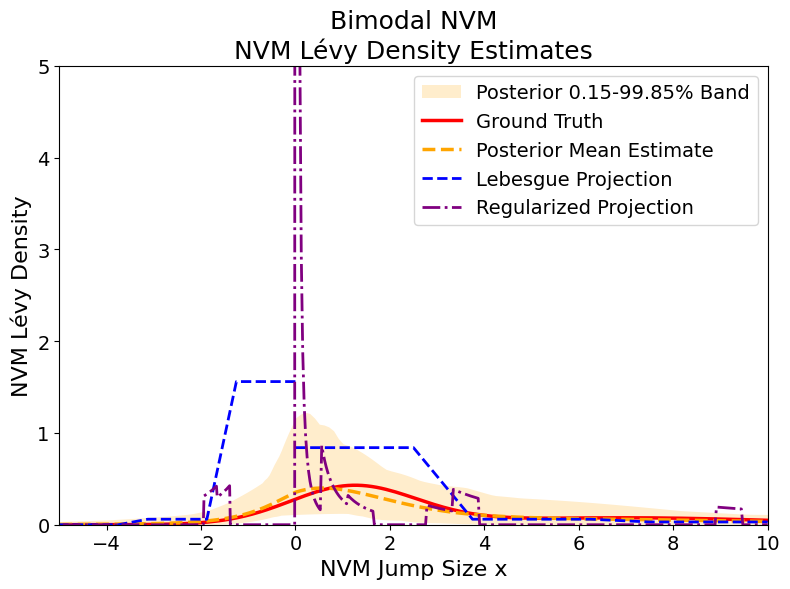

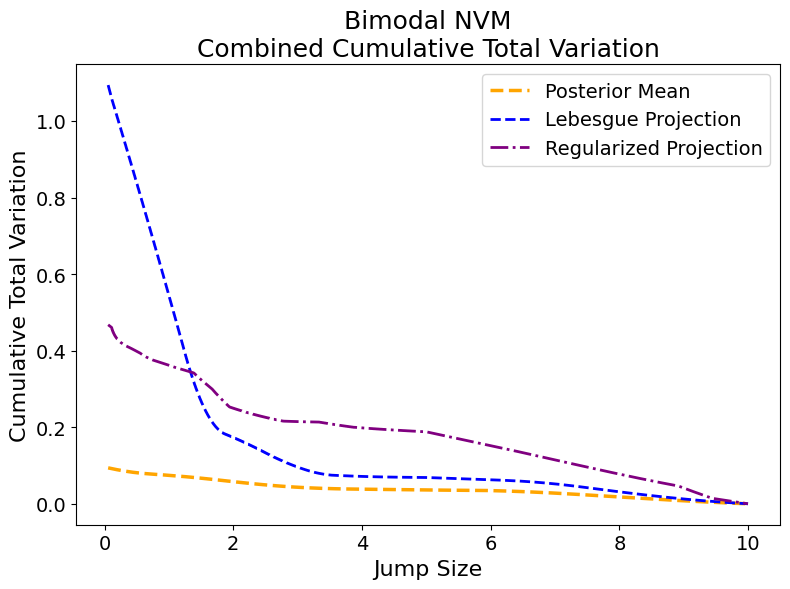

In [1]:
# ============================================================
# Bimodal experiment: optimized NVM Lévy density visualization
# Posterior / Prior / Ground Truth / Projection comparison
#
# No density truncation version:
#   - Bimodal case does not use density truncation.
#   - Posterior mean, prior mean, ground truth, posterior band, and draws
#     are all plotted on the full NVM density axis.
#   - Projection estimators are still constructed from projection_epsilon
#     because histogram support cannot start exactly at zero.
#   - TVD lower bound is projection_epsilon only, not an artificial threshold.
# ============================================================

factor = 1

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gamma

from posteriors import *
from Common_Tools import *
from Levy_Generators import *
from Levy_State_Space import *
from mcmc_sampler import *
from ground_truths import *
from mcmc_sampler_sigmaw2_conditional import *
from bimodal_experiments_sampler import *


# ============================================================
# Plot style
# ============================================================

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


# ============================================================
# Helper functions: density
# ============================================================

def _fmt_array(arr, precision=2):
    arr = np.asarray(arr, dtype=float)
    return "[" + ", ".join([f"{x:.{precision}g}" for x in arr]) + "]"


def gaussian_mixture_density_fast(
    rates,
    positions,
    x_axis,
    muw_mu,
    muw_sigma2,
    sigmaw2,
):
    """
    Fast NVM Gaussian mixture density:

        rho_J(x)
        = sum_i rates_i * N(
            x ; muw_mu * z_i,
                muw_sigma2 * z_i^2 + sigmaw2 * z_i
          ).
    """
    rates = np.asarray(rates, dtype=float)
    positions = np.asarray(positions, dtype=float)
    x_axis = np.asarray(x_axis, dtype=float)

    valid = (
        np.isfinite(rates)
        & np.isfinite(positions)
        & (rates > 0)
        & (positions > 0)
    )

    rates = rates[valid]
    positions = positions[valid]

    if len(rates) == 0:
        return np.zeros_like(x_axis, dtype=float)

    means = muw_mu * positions
    variances = muw_sigma2 * positions**2 + sigmaw2 * positions
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    z = (x_axis[None, :] - means[:, None]) / stds[:, None]
    coef = rates[:, None] / (stds[:, None] * np.sqrt(2.0 * np.pi))

    return np.sum(coef * np.exp(-0.5 * z**2), axis=0)


def bimodal_subordinator_levy_density(z, rate_lambda, shapes, scales, weights):
    """
    Compound Poisson gamma-mixture subordinator Lévy density:

        rho_Z(z) = lambda * sum_k w_k GammaPDF(z; a_k, scale=s_k).
    """
    z = np.asarray(z, dtype=float)
    shapes = np.asarray(shapes, dtype=float)
    scales = np.asarray(scales, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    out = np.zeros_like(z, dtype=float)

    for a, s, w in zip(shapes, scales, weights):
        out += w * gamma.pdf(z, a=a, scale=s)

    return rate_lambda * out


def NVM_bimodal_ground_truth_density_by_quadrature_fast(
    x_axis,
    muw,
    sigmaw,
    rate_lambda,
    shapes,
    scales,
    weights,
    z_min=1e-8,
    z_max=None,
    num_z=3000,
):
    """
    Ground truth NVM Lévy density for a compound Poisson gamma-mixture subordinator:

        rho_J(x)
        = int N(x; muw*z, sigmaw^2*z)
              * lambda * sum_k w_k GammaPDF(z; a_k, scale=s_k) dz.
    """
    x_axis = np.asarray(x_axis, dtype=float)
    shapes = np.asarray(shapes, dtype=float)
    scales = np.asarray(scales, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    if z_max is None:
        q_vals = [
            gamma.ppf(0.999999, a=a, scale=s)
            for a, s in zip(shapes, scales)
        ]
        z_max = float(np.nanmax(q_vals))

        if not np.isfinite(z_max) or z_max <= z_min:
            z_max = 100.0

    z_grid = np.logspace(np.log10(z_min), np.log10(z_max), num_z)

    rho_z = bimodal_subordinator_levy_density(
        z_grid,
        rate_lambda=rate_lambda,
        shapes=shapes,
        scales=scales,
        weights=weights,
    )

    means = muw * z_grid
    variances = sigmaw**2 * z_grid
    variances = np.maximum(variances, 1e-300)
    stds = np.sqrt(variances)

    z = (x_axis[None, :] - means[:, None]) / stds[:, None]
    pdf = np.exp(-0.5 * z**2) / (stds[:, None] * np.sqrt(2.0 * np.pi))

    integrand = pdf * rho_z[:, None]
    density = np.trapezoid(integrand, z_grid, axis=0)

    return density


# ============================================================
# Settings
# ============================================================

simulation_file = "bimodal_driven_NVM.npz"
posterior_file = "nvm_bimodal_subordinator_experiments.npz"

additional_burn_in = 0
num_samples_in_plot = 500

posterior_band_lower_percentage = 0.15
posterior_band_upper_percentage = 99.85
show_posterior_band = True

# NVM density axis.
# No density truncation is used in plotting.
nvm_epsilon = 0.0
nvm_positive_axis = np.linspace(nvm_epsilon, 10.0, 100)
nvm_negative_axis = np.linspace(nvm_epsilon, 5.0, 100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])


# ============================================================
# Load simulation data
# ============================================================

sim_data = np.load(simulation_file)

shapes = np.asarray(sim_data["shapes"], dtype=float)
scales = np.asarray(sim_data["scales"], dtype=float)
weights = np.asarray(sim_data["weights"], dtype=float)
weights = weights / weights.sum()

T = float(sim_data["T"])
time_axis = sim_data["time_axis"]
lambda_rate = float(sim_data["rate"])

sub_jump_sizes = sim_data["sub_jump_sizes"]
jump_times = sim_data["jump_times"]
nvm_jump_sizes = sim_data["nvm_jump_sizes"]

muw = float(sim_data["muw"])
sigmaw = float(sim_data["sigmaw"])
sigmaw2 = float(sim_data["sigmaw2"])

print("Simulation parameters:")
print("lambda_rate:", lambda_rate)
print("shapes:", shapes)
print("scales:", scales)
print("weights:", weights)
print("muw:", muw)
print("sigmaw:", sigmaw)
print("sigmaw2:", sigmaw2)


# ============================================================
# Load posterior samples
# ============================================================

post_data = np.load(posterior_file)

sample_measures_raw = post_data["sample_measures"][additional_burn_in:].copy()
sample_rates = post_data["sample_rates"][additional_burn_in:].copy()
sample_x_means = post_data["sample_x_means"][additional_burn_in:].copy()
sample_x_covariances = post_data["sample_x_covariances"][additional_burn_in:].copy()

S = len(sample_measures_raw)

print("Number of posterior samples:", S)
print("sample_measures_raw shape:", sample_measures_raw.shape)
print("sample_rates shape:", sample_rates.shape)
print("sample_x_means shape:", sample_x_means.shape)
print("sample_x_covariances shape:", sample_x_covariances.shape)


# ============================================================
# Prior definition and prior samples
# ============================================================

rate_alpha_prior = 3
rate_beta_prior = 1
dir_K = 1000

initial_dir_alpha = 1.0
initial_base_gamma_a = 1.0
initial_base_gamma_b = 3.0

dir_alpha_a = 0.5
dir_alpha_b = 0.5

muw_mean = 0.0
muw_variance = 10.0

prior_num_samples = 1000

prior_sample_measures_raw, prior_sample_rates = draw_IGSDP_Prior_Measures(
    rate_alpha_prior,
    rate_beta_prior,
    initial_base_gamma_a,
    1 / initial_base_gamma_b,
    dir_alpha_a,
    1 / dir_alpha_b,
    dir_K,
    num_samples=prior_num_samples,
)

prior_sample_measures_raw = prior_sample_measures_raw.copy()
prior_sample_rates = np.asarray(prior_sample_rates).copy()

P = len(prior_sample_measures_raw)

print("Number of prior samples:", P)


# ============================================================
# Select realization indices for plotting only
# ============================================================

rng = np.random.default_rng(123)

num_posterior_density_draws = min(num_samples_in_plot, S)
num_prior_density_draws = min(num_samples_in_plot, P)

posterior_density_indices = rng.choice(
    S,
    size=num_posterior_density_draws,
    replace=False,
)

prior_density_indices = rng.choice(
    P,
    size=num_prior_density_draws,
    replace=False,
)

posterior_density_index_set = set(posterior_density_indices.tolist())
prior_density_index_set = set(prior_density_indices.tolist())


# ============================================================
# Optimized posterior processing: density mean + selected draws only
# ============================================================

posterior_density_sum = np.zeros_like(nvm_axis, dtype=float)
posterior_density_draws = []

for i in tqdm(range(S), desc="Posterior density analysis"):
    sample_measure = sample_measures_raw[i].copy()
    sample_rate = sample_rates[i]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate

    rates_i = sample_measure[0, :]
    positions_i = sample_measure[1, :]

    x_mean_sample_series = sample_x_means[i]
    x_covariance_sample_series = sample_x_covariances[i]

    muw_posterior_mean = x_mean_sample_series[-1, -1, 0]
    muw_posterior_variance = x_covariance_sample_series[-1, -1, -1]

    density_i = gaussian_mixture_density_fast(
        rates_i,
        positions_i,
        nvm_axis,
        muw_posterior_mean,
        muw_posterior_variance,
        sigmaw2,
    )

    posterior_density_sum += density_i

    if i in posterior_density_index_set:
        posterior_density_draws.append(density_i)

NVM_density_inferred = posterior_density_sum / S
posterior_density_draws = np.vstack(posterior_density_draws)

posterior_density_band_lower = np.percentile(
    posterior_density_draws,
    posterior_band_lower_percentage,
    axis=0,
)
posterior_density_band_upper = np.percentile(
    posterior_density_draws,
    posterior_band_upper_percentage,
    axis=0,
)

print("posterior_density_draws shape:", posterior_density_draws.shape)


# ============================================================
# Optimized prior processing: density mean + selected draws only
# ============================================================

prior_density_sum = np.zeros_like(nvm_axis, dtype=float)
prior_density_draws = []

for i in tqdm(range(P), desc="Prior density analysis"):
    prior_measure = prior_sample_measures_raw[i].copy()
    prior_rate = prior_sample_rates[i]

    prior_measure[0, :] = prior_measure[0, :] * prior_rate

    prior_rates_i = prior_measure[0, :]
    prior_positions_i = prior_measure[1, :]

    prior_density_i = gaussian_mixture_density_fast(
        prior_rates_i,
        prior_positions_i,
        nvm_axis,
        muw_mean,
        muw_variance,
        sigmaw2,
    )

    prior_density_sum += prior_density_i

    if i in prior_density_index_set:
        prior_density_draws.append(prior_density_i)

prior_NVM_density_inferred = prior_density_sum / P
prior_density_draws = np.vstack(prior_density_draws)

prior_density_band_lower = np.percentile(
    prior_density_draws,
    posterior_band_lower_percentage,
    axis=0,
)
prior_density_band_upper = np.percentile(
    prior_density_draws,
    posterior_band_upper_percentage,
    axis=0,
)

print("prior_density_draws shape:", prior_density_draws.shape)


# ============================================================
# Ground truth: Bimodal NVM Lévy density
# ============================================================

NVM_density_ground_truth = NVM_bimodal_ground_truth_density_by_quadrature_fast(
    nvm_axis,
    muw=muw * factor,
    sigmaw=sigmaw * np.sqrt(factor),
    rate_lambda=lambda_rate,
    shapes=shapes,
    scales=scales,
    weights=weights,
    z_min=1e-8,
    z_max=None,
    num_z=3000,
)


# ============================================================
# Save original arrays
# ============================================================

original_nvm_axis = nvm_axis

original_NVM_density_inferred = NVM_density_inferred
original_prior_NVM_density_inferred = prior_NVM_density_inferred
original_NVM_density_ground_truth = NVM_density_ground_truth

original_nvm_density_lower_quantile = posterior_density_band_lower
original_nvm_density_upper_quantile = posterior_density_band_upper

original_prior_nvm_density_lower_quantile = prior_density_band_lower
original_prior_nvm_density_upper_quantile = prior_density_band_upper

NVM_density_array = posterior_density_draws
prior_NVM_density_array = prior_density_draws


# ============================================================
# NVM density realization-based plotting
# No density truncation: plot full axis directly.
# ============================================================

density_title = (
    f"NVM Lévy Density\n"
    f"Bimodal Parameters: "
    f"$\\lambda$={lambda_rate:.2g}, "
    f"$a$={_fmt_array(shapes, 2)}, "
    f"$s$={_fmt_array(scales, 2)}, "
    f"$w$={_fmt_array(weights, 2)}; "
    f"$\\mu_w$={muw * factor:.2g}"
)

density_full_axis = original_nvm_axis

posterior_density_full_array = NVM_density_array
prior_density_full_array = prior_NVM_density_array

posterior_density_mean_full = original_NVM_density_inferred
prior_density_mean_full = original_prior_NVM_density_inferred
ground_truth_density_full = original_NVM_density_ground_truth

posterior_density_lower_full = original_nvm_density_lower_quantile
posterior_density_upper_full = original_nvm_density_upper_quantile

prior_density_lower_full = original_prior_nvm_density_lower_quantile
prior_density_upper_full = original_prior_nvm_density_upper_quantile


# ============================================================
# Plot 1:
# Posterior draws + posterior mean + prior mean + ground truth
# ============================================================

plt.figure(figsize=(8, 6))

for j in range(posterior_density_full_array.shape[0]):
    plt.plot(
        density_full_axis,
        posterior_density_full_array[j],
        color="blue",
        alpha=0.2,
        linewidth=0.8,
        label="Posterior Draws" if j == 0 else None,
    )

plt.plot(
    density_full_axis,
    posterior_density_mean_full,
    color="orange",
    linewidth=2.5,
    label="Posterior Mean",
)

plt.plot(
    density_full_axis,
    prior_density_mean_full,
    color="#00FF66",
    linewidth=2.5,
    label="Prior Mean",
)

plt.plot(
    density_full_axis,
    ground_truth_density_full,
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)

plt.xlim(-5, 10)
plt.title(density_title)
plt.xlabel("x")
plt.ylabel("Density Value")
plt.legend()
plt.tight_layout()
plt.show()



# ============================================================
# mu_w posterior distribution
# ============================================================

sample_muw_means = sample_x_means[:, -1, -1, -1]
sample_muw_covariances = sample_x_covariances[:, -1, -1, -1]

print("Mean of muw posterior means:", np.mean(sample_muw_means))
print("sample_muw_means shape:", sample_muw_means.shape)
print("sample_muw_covariances shape:", sample_muw_covariances.shape)

x_muw = np.linspace(muw - 5.0, muw + 5.0, 1000)
weights_muw = np.ones(len(sample_muw_covariances)) / len(sample_muw_covariances)

plot_mixture_of_gaussians(
    sample_muw_means,
    sample_muw_covariances,
    weights_muw,
    x_muw,
    muw,
    r"$\mu_w$ Posterior Distribution",
    show_mixture_mean=True,
)


# ============================================================
# Bimodal case:
# Projection density overlay + cumulative TVD
#
# No artificial density truncation:
#   - Projection overlay plots full posterior / ground truth / band axis.
#   - Projection estimates start from projection_epsilon only.
#   - TVD lower bound is projection_epsilon.
# ============================================================

# ============================================================
# Projection settings
# ============================================================

observation_noise_level = 1e-5
projection_epsilon = 1e-5

projection_x_min = projection_epsilon
projection_positive_x_max = 10.0
projection_negative_x_max = 5.0

# No artificial truncation.
lebesgue_eval_truncation = projection_epsilon
regularized_tvd_truncation = projection_epsilon
plot_threshold = 0.0

resolution_list_p0 = np.arange(1, 50)
resolution_list_p2 = np.arange(1, 50)

divide_counts_by_T = True

search_n_common = 1000
cumulative_n_common = 1000

ylim_cap = 5

show_resolution_search_plots = True


# ============================================================
# Helper functions: projection / TVD
# ============================================================

def regularized_projection_estimate_fixed_support(
    data,
    counts,
    resolution,
    regularized_power=0,
    x_min=1e-5,
    x_max=10.0,
):
    resolution = int(resolution)

    data = np.asarray(data, dtype=float).reshape(-1)
    counts = np.asarray(counts, dtype=float).reshape(-1)

    valid = (
        np.isfinite(data)
        & np.isfinite(counts)
        & (data > 0)
        & (counts > 0)
        & (data >= x_min)
        & (data <= x_max)
    )

    data = data[valid]
    counts = counts[valid]

    hist_axis = np.linspace(x_min, x_max, resolution + 1)
    bin_width = hist_axis[1] - hist_axis[0]
    bin_centers = 0.5 * (hist_axis[:-1] + hist_axis[1:])

    hist_counts = np.zeros(len(hist_axis) - 1, dtype=float)

    if len(data) > 0:
        data_sorted_indices = np.argsort(data)
        data = data[data_sorted_indices]
        counts = counts[data_sorted_indices]

        data_pointer = 0
        axis_pointer = 0

        while data_pointer < len(data) and axis_pointer < len(hist_axis) - 1:
            if data[data_pointer] <= hist_axis[axis_pointer + 1]:
                hist_counts[axis_pointer] += (
                    counts[data_pointer]
                    * (data[data_pointer] ** regularized_power)
                    / bin_width
                )
                data_pointer += 1
            else:
                axis_pointer += 1

    results = np.zeros(resolution * len(bin_centers))
    x_axis = np.linspace(x_min, x_max, len(results))

    for i in range(len(bin_centers)):
        start = i * resolution
        end = min((i + 1) * resolution, len(results))
        results[start:end] = hist_counts[i]

    if regularized_power != 0:
        results = results * np.maximum(x_axis, 1e-300) ** (-regularized_power)

    return x_axis, results


def interp_positive_axis_linear_y(x_src, y_src, x_tgt):
    x_src = np.asarray(x_src, dtype=float).reshape(-1)
    y_src = np.asarray(y_src, dtype=float).reshape(-1)
    x_tgt = np.asarray(x_tgt, dtype=float).reshape(-1)

    valid = (
        np.isfinite(x_src)
        & np.isfinite(y_src)
        & (x_src >= 0)
    )

    x_src = x_src[valid]
    y_src = y_src[valid]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    order = np.argsort(x_src)
    x_src = x_src[order]
    y_src = y_src[order]

    x_unique, idx = np.unique(x_src, return_index=True)
    x_src = x_unique
    y_src = y_src[idx]

    if len(x_src) < 2:
        return np.full_like(x_tgt, np.nan, dtype=float)

    return np.interp(
        x_tgt,
        x_src,
        y_src,
        left=np.nan,
        right=np.nan,
    )


def tvd_one_side(
    est_axis,
    est_density,
    gt_axis,
    gt_density,
    x_min,
    x_max,
    n_common=1000,
):
    grid = np.linspace(x_min, x_max, n_common)

    est_on_grid = interp_positive_axis_linear_y(est_axis, est_density, grid)
    gt_on_grid = interp_positive_axis_linear_y(gt_axis, gt_density, grid)

    mask = np.isfinite(est_on_grid) & np.isfinite(gt_on_grid)

    if np.sum(mask) < 5:
        return np.inf

    x = grid[mask]
    local_error = 0.5 * np.abs(est_on_grid[mask] - gt_on_grid[mask])

    return np.trapezoid(local_error, x)


def build_projection_record_one_side(
    increments_abs,
    counts,
    resolution,
    regularized_power,
    x_min,
    x_max,
    gt_axis_abs,
    gt_density,
    tvd_truncation,
    n_common=1000,
):
    est_axis, est_density = regularized_projection_estimate_fixed_support(
        data=increments_abs,
        counts=counts,
        resolution=int(resolution),
        regularized_power=regularized_power,
        x_min=x_min,
        x_max=x_max,
    )

    tvd_x_min = max(x_min, tvd_truncation)

    tvd = tvd_one_side(
        est_axis=est_axis,
        est_density=est_density,
        gt_axis=gt_axis_abs,
        gt_density=gt_density,
        x_min=tvd_x_min,
        x_max=x_max,
        n_common=n_common,
    )

    return {
        "resolution": int(resolution),
        "regularized_power": int(regularized_power),
        "tvd": float(tvd),
        "axis": np.asarray(est_axis, dtype=float),
        "density": np.asarray(est_density, dtype=float),
        "x_min": float(x_min),
        "x_max": float(x_max),
        "tvd_truncation": float(tvd_truncation),
    }


def shared_resolution_tvd_search(
    positive_increments_abs,
    positive_counts,
    negative_increments_abs,
    negative_counts,
    resolution_list,
    regularized_power,
    positive_x_min,
    positive_x_max,
    negative_x_min,
    negative_x_max,
    gt_positive_axis_abs,
    gt_positive_density,
    gt_negative_axis_abs,
    gt_negative_density,
    tvd_truncation,
    n_common=1000,
):
    records = []
    best = None

    for resolution in tqdm(
        resolution_list,
        desc=f"Shared-resolution TVD search, p={regularized_power}",
    ):
        pos_record = build_projection_record_one_side(
            increments_abs=positive_increments_abs,
            counts=positive_counts,
            resolution=int(resolution),
            regularized_power=regularized_power,
            x_min=positive_x_min,
            x_max=positive_x_max,
            gt_axis_abs=gt_positive_axis_abs,
            gt_density=gt_positive_density,
            tvd_truncation=tvd_truncation,
            n_common=n_common,
        )

        neg_record = build_projection_record_one_side(
            increments_abs=negative_increments_abs,
            counts=negative_counts,
            resolution=int(resolution),
            regularized_power=regularized_power,
            x_min=negative_x_min,
            x_max=negative_x_max,
            gt_axis_abs=gt_negative_axis_abs,
            gt_density=gt_negative_density,
            tvd_truncation=tvd_truncation,
            n_common=n_common,
        )

        combined_tvd = pos_record["tvd"] + neg_record["tvd"]

        record = {
            "resolution": int(resolution),
            "regularized_power": int(regularized_power),
            "positive_tvd": float(pos_record["tvd"]),
            "negative_tvd": float(neg_record["tvd"]),
            "combined_tvd": float(combined_tvd),
            "positive": pos_record,
            "negative": neg_record,
        }

        records.append(record)

        if best is None or combined_tvd < best["combined_tvd"]:
            best = record

    return best, records


def plot_shared_resolution_search(records, title):
    resolutions = np.array([r["resolution"] for r in records], dtype=float)
    positive_tvd = np.array([r["positive_tvd"] for r in records], dtype=float)
    negative_tvd = np.array([r["negative_tvd"] for r in records], dtype=float)
    combined_tvd = np.array([r["combined_tvd"] for r in records], dtype=float)

    plt.figure(figsize=(8, 6))
    plt.plot(resolutions, combined_tvd, linewidth=2.5, label="Combined TVD")
    plt.plot(resolutions, positive_tvd, linewidth=2, linestyle="--", label="Positive TVD")
    plt.plot(resolutions, negative_tvd, linewidth=2, linestyle="--", label="Negative TVD")
    plt.xlabel("Shared histogram resolution / bins")
    plt.ylabel("TVD")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def cumulative_tv_small_to_large(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[1:] = np.cumsum(increments)

    return out


def cumulative_tv_large_to_small(x, y_est, y_true):
    x = np.asarray(x, dtype=float)
    y_est = np.asarray(y_est, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    local = 0.5 * np.abs(y_est - y_true)

    out = np.zeros_like(x, dtype=float)
    if len(x) >= 2:
        increments = 0.5 * (local[1:] + local[:-1]) * np.diff(x)
        out[:-1] = np.cumsum(increments[::-1])[::-1]

    return out


def evaluate_side_for_cumulative_tv(
    posterior_axis_signed,
    posterior_density,
    gt_density_on_posterior_axis,
    projection_axis_leb,
    projection_density_leb,
    projection_axis_reg,
    projection_density_reg,
    x_min,
    x_max,
    n_common=1000,
):
    x_post = np.abs(np.asarray(posterior_axis_signed, dtype=float).reshape(-1))
    y_post = np.asarray(posterior_density, dtype=float).reshape(-1)
    y_gt = np.asarray(gt_density_on_posterior_axis, dtype=float).reshape(-1)

    x_leb = np.asarray(projection_axis_leb, dtype=float).reshape(-1)
    y_leb = np.asarray(projection_density_leb, dtype=float).reshape(-1)

    x_reg = np.asarray(projection_axis_reg, dtype=float).reshape(-1)
    y_reg = np.asarray(projection_density_reg, dtype=float).reshape(-1)

    grid = np.linspace(x_min, x_max, n_common)

    gt_on_grid = interp_positive_axis_linear_y(x_post, y_gt, grid)
    post_on_grid = interp_positive_axis_linear_y(x_post, y_post, grid)
    leb_on_grid = interp_positive_axis_linear_y(x_leb, y_leb, grid)
    reg_on_grid = interp_positive_axis_linear_y(x_reg, y_reg, grid)

    mask = (
        np.isfinite(gt_on_grid)
        & np.isfinite(post_on_grid)
        & np.isfinite(leb_on_grid)
        & np.isfinite(reg_on_grid)
    )

    return {
        "x": grid[mask],
        "gt": gt_on_grid[mask],
        "post": post_on_grid[mask],
        "leb": leb_on_grid[mask],
        "reg": reg_on_grid[mask],
    }


def combine_pos_neg_cumulative_tv(pos_eval, neg_eval, direction="small_to_large"):
    x_all = np.concatenate([pos_eval["x"], neg_eval["x"]])

    gt_all = np.concatenate([pos_eval["gt"], neg_eval["gt"]])
    post_all = np.concatenate([pos_eval["post"], neg_eval["post"]])
    leb_all = np.concatenate([pos_eval["leb"], neg_eval["leb"]])
    reg_all = np.concatenate([pos_eval["reg"], neg_eval["reg"]])

    order = np.argsort(x_all)

    x_sorted = x_all[order]
    gt_sorted = gt_all[order]
    post_sorted = post_all[order]
    leb_sorted = leb_all[order]
    reg_sorted = reg_all[order]

    if direction == "small_to_large":
        return {
            "x": x_sorted,
            "post": cumulative_tv_small_to_large(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_small_to_large(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_small_to_large(x_sorted, reg_sorted, gt_sorted),
        }

    if direction == "large_to_small":
        return {
            "x": x_sorted,
            "post": cumulative_tv_large_to_small(x_sorted, post_sorted, gt_sorted),
            "leb": cumulative_tv_large_to_small(x_sorted, leb_sorted, gt_sorted),
            "reg": cumulative_tv_large_to_small(x_sorted, reg_sorted, gt_sorted),
        }

    raise ValueError("direction must be 'small_to_large' or 'large_to_small'.")


# ============================================================
# Recreate observations and increments
# ============================================================

nvm_process_path = integrate_to_path(
    nvm_jump_sizes,
    jump_times,
    time_axis,
)

sigmav2 = observation_noise_level ** 2

observations = langevin_observations(
    nvm_process_path,
    sigmav2 * np.identity(1),
    H=np.ones((1, 1)),
    mu=np.zeros((1, 1)),
)

observations = np.asarray(observations)

if observations.ndim == 1:
    increments = np.diff(observations).reshape(-1)
else:
    increments = np.diff(observations[0, :]).reshape(-1)

positive_increments_all = increments[increments >= projection_epsilon]
negative_increments_all = -increments[increments <= -projection_epsilon]

if divide_counts_by_T:
    positive_counts = np.ones_like(positive_increments_all, dtype=float) / float(T)
    negative_counts = np.ones_like(negative_increments_all, dtype=float) / float(T)
else:
    positive_counts = np.ones_like(positive_increments_all, dtype=float)
    negative_counts = np.ones_like(negative_increments_all, dtype=float)

print("========== Projection input diagnostics ==========")
print("observation_noise_level:", observation_noise_level)
print("T:", T)
print("increments shape:", increments.shape)

print("\nPositive increments:")
print("count:", len(positive_increments_all))
if len(positive_increments_all) > 0:
    print("min/max:", positive_increments_all.min(), positive_increments_all.max())

print("\nNegative absolute increments:")
print("count:", len(negative_increments_all))
if len(negative_increments_all) > 0:
    print("min/max:", negative_increments_all.min(), negative_increments_all.max())

print("\nProjection support:")
print("positive:", (projection_x_min, projection_positive_x_max))
print("negative:", (projection_x_min, projection_negative_x_max))
print("Lebesgue TVD lower bound:", lebesgue_eval_truncation)
print("Regularized TVD lower bound:", regularized_tvd_truncation)
print("divide_counts_by_T:", divide_counts_by_T)


# ============================================================
# Prepare posterior / ground truth density sides
# ============================================================

post_neg_mask_full = original_nvm_axis < 0
post_pos_mask_full = original_nvm_axis > 0

posterior_negative_axis_full = original_nvm_axis[post_neg_mask_full]
posterior_positive_axis_full = original_nvm_axis[post_pos_mask_full]

posterior_density_negative_full = original_NVM_density_inferred[post_neg_mask_full]
posterior_density_positive_full = original_NVM_density_inferred[post_pos_mask_full]

ground_truth_density_negative_full = original_NVM_density_ground_truth[post_neg_mask_full]
ground_truth_density_positive_full = original_NVM_density_ground_truth[post_pos_mask_full]

posterior_density_band_lower_negative_full = original_nvm_density_lower_quantile[post_neg_mask_full]
posterior_density_band_upper_negative_full = original_nvm_density_upper_quantile[post_neg_mask_full]

posterior_density_band_lower_positive_full = original_nvm_density_lower_quantile[post_pos_mask_full]
posterior_density_band_upper_positive_full = original_nvm_density_upper_quantile[post_pos_mask_full]


gt_positive_axis_abs = np.abs(posterior_positive_axis_full)
gt_negative_axis_abs = np.abs(posterior_negative_axis_full)

pos_order = np.argsort(gt_positive_axis_abs)
neg_order = np.argsort(gt_negative_axis_abs)

gt_positive_axis_abs_sorted = gt_positive_axis_abs[pos_order]
gt_positive_density_sorted = ground_truth_density_positive_full[pos_order]

gt_negative_axis_abs_sorted = gt_negative_axis_abs[neg_order]
gt_negative_density_sorted = ground_truth_density_negative_full[neg_order]


# ============================================================
# Shared-resolution TVD hyperparameter search
# ============================================================

best_p0, records_p0 = shared_resolution_tvd_search(
    positive_increments_abs=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments_abs=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p0,
    regularized_power=0,
    positive_x_min=projection_x_min,
    positive_x_max=projection_positive_x_max,
    negative_x_min=projection_x_min,
    negative_x_max=projection_negative_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_truncation=lebesgue_eval_truncation,
    n_common=search_n_common,
)

best_p2, records_p2 = shared_resolution_tvd_search(
    positive_increments_abs=positive_increments_all,
    positive_counts=positive_counts,
    negative_increments_abs=negative_increments_all,
    negative_counts=negative_counts,
    resolution_list=resolution_list_p2,
    regularized_power=2,
    positive_x_min=projection_x_min,
    positive_x_max=projection_positive_x_max,
    negative_x_min=projection_x_min,
    negative_x_max=projection_negative_x_max,
    gt_positive_axis_abs=gt_positive_axis_abs_sorted,
    gt_positive_density=gt_positive_density_sorted,
    gt_negative_axis_abs=gt_negative_axis_abs_sorted,
    gt_negative_density=gt_negative_density_sorted,
    tvd_truncation=regularized_tvd_truncation,
    n_common=search_n_common,
)

positive_best_p0 = best_p0["positive"]
negative_best_p0 = best_p0["negative"]

positive_best_p2 = best_p2["positive"]
negative_best_p2 = best_p2["negative"]

print("\n========== Shared-resolution TVD-selected projection resolutions ==========")
print("p=0 Lebesgue:")
print("  shared bins:", best_p0["resolution"])
print("  positive TVD:", best_p0["positive_tvd"])
print("  negative TVD:", best_p0["negative_tvd"])
print("  combined TVD:", best_p0["combined_tvd"])

print("\np=2 Regularized:")
print("  shared bins:", best_p2["resolution"])
print("  positive TVD:", best_p2["positive_tvd"])
print("  negative TVD:", best_p2["negative_tvd"])
print("  combined TVD:", best_p2["combined_tvd"])

if show_resolution_search_plots:
    plot_shared_resolution_search(
        records_p0,
        "Shared-resolution Combined TVD Search, p=0",
    )

    plot_shared_resolution_search(
        records_p2,
        "Shared-resolution Combined TVD Search, p=2",
    )


# ============================================================
# Replacement overlay density plots for bimodal case
#
# Purpose:
#   - Do NOT truncate posterior mean / ground truth / posterior band near zero.
#   - Plot posterior mean, ground truth, and posterior band on the full NVM axis.
#   - Projection curves still start from projection_epsilon because the
#     histogram projection estimator is built on positive |x| support.
#
# Run this after the full bimodal block has already produced:
#   posterior_negative_axis_full / posterior_positive_axis_full
#   posterior_density_negative_full / posterior_density_positive_full
#   ground_truth_density_negative_full / ground_truth_density_positive_full
#   posterior_density_band_lower_* / posterior_density_band_upper_*
#   positive_best_p0 / negative_best_p0 / positive_best_p2 / negative_best_p2
# ============================================================

# ------------------------------------------------------------
# Reconstruct full posterior / ground truth / band arrays
# from the saved original arrays.
# ------------------------------------------------------------

full_density_axis = np.asarray(original_nvm_axis, dtype=float)

full_density_mask = (
    np.isfinite(full_density_axis)
    & (full_density_axis >= -projection_negative_x_max)
    & (full_density_axis <= projection_positive_x_max)
)

full_density_axis_plot = full_density_axis[full_density_mask]

full_ground_truth_density_plot = np.asarray(
    original_NVM_density_ground_truth,
    dtype=float,
)[full_density_mask]

full_posterior_mean_density_plot = np.asarray(
    original_NVM_density_inferred,
    dtype=float,
)[full_density_mask]

if show_posterior_band:
    full_posterior_band_lower_plot = np.asarray(
        original_nvm_density_lower_quantile,
        dtype=float,
    )[full_density_mask]

    full_posterior_band_upper_plot = np.asarray(
        original_nvm_density_upper_quantile,
        dtype=float,
    )[full_density_mask]


# ------------------------------------------------------------
# Projection masks.
# No artificial plotting truncation.
# Projection estimates start from projection_epsilon.
# ------------------------------------------------------------

projection_plot_min = projection_epsilon

neg_p0_mask_no_trunc = (
    (negative_best_p0["axis"] >= projection_plot_min)
    & (negative_best_p0["axis"] <= projection_negative_x_max)
)

pos_p0_mask_no_trunc = (
    (positive_best_p0["axis"] >= projection_plot_min)
    & (positive_best_p0["axis"] <= projection_positive_x_max)
)

neg_p2_mask_no_trunc = (
    (negative_best_p2["axis"] >= projection_plot_min)
    & (negative_best_p2["axis"] <= projection_negative_x_max)
)

pos_p2_mask_no_trunc = (
    (positive_best_p2["axis"] >= projection_plot_min)
    & (positive_best_p2["axis"] <= projection_positive_x_max)
)


# ============================================================
# Overlay plot: full y-range
# ============================================================

plt.figure(figsize=(8, 6))

if show_posterior_band:
    plt.fill_between(
        full_density_axis_plot,
        full_posterior_band_lower_plot,
        full_posterior_band_upper_plot,
        color="orange",
        alpha=0.2,
        linewidth=0,
        label=(
            f"Posterior {posterior_band_lower_percentage:g}-"
            f"{posterior_band_upper_percentage:g}% Band"
        ),
    )

plt.plot(
    full_density_axis_plot,
    full_ground_truth_density_plot,
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)

plt.plot(
    full_density_axis_plot,
    full_posterior_mean_density_plot,
    color="orange",
    linewidth=2.5,
    linestyle="--",
    label="Posterior Mean Estimate",
)

plt.plot(
    -negative_best_p0["axis"][neg_p0_mask_no_trunc],
    negative_best_p0["density"][neg_p0_mask_no_trunc],
    color="blue",
    linewidth=2,
    linestyle="--",
    label=f"Lebesgue Projection, bins={positive_best_p0['resolution']}",
)
plt.plot(
    positive_best_p0["axis"][pos_p0_mask_no_trunc],
    positive_best_p0["density"][pos_p0_mask_no_trunc],
    color="blue",
    linewidth=2,
    linestyle="--",
)

plt.plot(
    -negative_best_p2["axis"][neg_p2_mask_no_trunc],
    negative_best_p2["density"][neg_p2_mask_no_trunc],
    color="purple",
    linewidth=2,
    linestyle="-.",
    label=f"Regularized Projection, bins={positive_best_p2['resolution']}",
)
plt.plot(
    positive_best_p2["axis"][pos_p2_mask_no_trunc],
    positive_best_p2["density"][pos_p2_mask_no_trunc],
    color="purple",
    linewidth=2,
    linestyle="-.",
)

plt.xlim(-projection_negative_x_max, projection_positive_x_max)
plt.xlabel("NVM Jump Size x")
plt.ylabel("NVM Lévy Density")
plt.title("Bimodal NVM\nNVM Lévy Density Estimates")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Overlay plot: capped ylim
# ============================================================

plt.figure(figsize=(8, 6))

if show_posterior_band:
    plt.fill_between(
        full_density_axis_plot,
        full_posterior_band_lower_plot,
        full_posterior_band_upper_plot,
        color="orange",
        alpha=0.2,
        linewidth=0,
        label=(
            f"Posterior {posterior_band_lower_percentage:g}-"
            f"{posterior_band_upper_percentage:g}% Band"
        ),
    )

plt.plot(
    full_density_axis_plot,
    full_ground_truth_density_plot,
    color="red",
    linewidth=2.5,
    label="Ground Truth",
)

plt.plot(
    full_density_axis_plot,
    full_posterior_mean_density_plot,
    color="orange",
    linewidth=2.5,
    linestyle="--",
    label="Posterior Mean Estimate",
)

plt.plot(
    -negative_best_p0["axis"][neg_p0_mask_no_trunc],
    negative_best_p0["density"][neg_p0_mask_no_trunc],
    color="blue",
    linewidth=2,
    linestyle="--",
    label="Lebesgue Projection",
)
plt.plot(
    positive_best_p0["axis"][pos_p0_mask_no_trunc],
    positive_best_p0["density"][pos_p0_mask_no_trunc],
    color="blue",
    linewidth=2,
    linestyle="--",
)

plt.plot(
    -negative_best_p2["axis"][neg_p2_mask_no_trunc],
    negative_best_p2["density"][neg_p2_mask_no_trunc],
    color="purple",
    linewidth=2,
    linestyle="-.",
    label="Regularized Projection",
)
plt.plot(
    positive_best_p2["axis"][pos_p2_mask_no_trunc],
    positive_best_p2["density"][pos_p2_mask_no_trunc],
    color="purple",
    linewidth=2,
    linestyle="-.",
)

plt.xlim(-projection_negative_x_max, projection_positive_x_max)
plt.ylim(0, ylim_cap)
plt.xlabel("NVM Jump Size x")
plt.ylabel("NVM Lévy Density")
plt.title("Bimodal NVM\nNVM Lévy Density Estimates")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Cumulative TVD evaluation
# No artificial truncation: lower bound is projection_epsilon.
# ============================================================

common_tvd_x_min = projection_epsilon

pos_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_positive_axis_full,
    posterior_density=posterior_density_positive_full,
    gt_density_on_posterior_axis=ground_truth_density_positive_full,
    projection_axis_leb=positive_best_p0["axis"],
    projection_density_leb=positive_best_p0["density"],
    projection_axis_reg=positive_best_p2["axis"],
    projection_density_reg=positive_best_p2["density"],
    x_min=common_tvd_x_min,
    x_max=projection_positive_x_max,
    n_common=cumulative_n_common,
)

neg_eval_tv = evaluate_side_for_cumulative_tv(
    posterior_axis_signed=posterior_negative_axis_full,
    posterior_density=posterior_density_negative_full,
    gt_density_on_posterior_axis=ground_truth_density_negative_full,
    projection_axis_leb=negative_best_p0["axis"],
    projection_density_leb=negative_best_p0["density"],
    projection_axis_reg=negative_best_p2["axis"],
    projection_density_reg=negative_best_p2["density"],
    x_min=common_tvd_x_min,
    x_max=projection_negative_x_max,
    n_common=cumulative_n_common,
)

combined_tv_large_to_small = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="large_to_small",
)

combined_tv_small_to_large = combine_pos_neg_cumulative_tv(
    pos_eval_tv,
    neg_eval_tv,
    direction="small_to_large",
)


# ============================================================
# Plot cumulative TVD: large to small
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["post"],
    color="orange",
    linestyle="--",
    linewidth=2.5,
    label="Posterior Mean",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["leb"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Lebesgue Projection",
)

plt.plot(
    combined_tv_large_to_small["x"],
    combined_tv_large_to_small["reg"],
    color="purple",
    linestyle="-.",
    linewidth=2,
    label="Regularized Projection",
)

plt.xlabel("Jump Size")
plt.ylabel("Cumulative Total Variation")
plt.title("Bimodal NVM\nCombined Cumulative Total Variation")
plt.legend()
plt.tight_layout()
plt.show()